# Installs


In [ ]:
%pip install dfply kagglehub imblearn

  Using cached numpy-2.4.3-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached scipy-1.17.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached charset_normalizer-3.4.6-cp312-cp312-macosx_10_13_universal2.whl.metadata (40 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.4/612.4 kB 252.3 kB/s  0:00:02eta 0:00:01
Using cache

In [8]:
%pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Imports

In [9]:
import kagglehub
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# used for piping
from dfply import *


import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Data Preperation

In [11]:
# Load data
# path = kagglehub.dataset_download("rasulmah/sri-lanka-weather-dataset")
# df = pd.read_csv(os.path.join(path, "SriLanka_Weather_Dataset_V1.csv"))

data_path = '../backend/data/SriLanka_Weather_Dataset.csv'
df = pd.read_csv(data_path)
df['time'] = pd.to_datetime(df['time'])
print(f"Shape: {df.shape}, Cities: {df['city'].nunique()}")
print(f"Date Range: {df['time'].min()} to {df['time'].max()}")

Shape: (147480, 24), Cities: 30
Date Range: 2010-01-01 00:00:00 to 2023-06-17 00:00:00


In [12]:
df = df >> drop('weathercode', 'sunrise', 'sunset', 'country', 'rain_sum', 'snowfall_sum')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 147480 entries, 0 to 147479
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   time                        147480 non-null  datetime64[us]
 1   temperature_2m_max          147480 non-null  float64       
 2   temperature_2m_min          147480 non-null  float64       
 3   temperature_2m_mean         147480 non-null  float64       
 4   apparent_temperature_max    147480 non-null  float64       
 5   apparent_temperature_min    147480 non-null  float64       
 6   apparent_temperature_mean   147480 non-null  float64       
 7   shortwave_radiation_sum     147480 non-null  float64       
 8   precipitation_sum           147480 non-null  float64       
 9   precipitation_hours         147480 non-null  float64       
 10  windspeed_10m_max           147480 non-null  float64       
 11  windgusts_10m_max           147480 non-null  float

In [13]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['city'])
print(f"Training DataFrame shape: {train_df.shape}")
print(f"Testing DataFrame shape: {test_df.shape}")

Training DataFrame shape: (117984, 18)
Testing DataFrame shape: (29496, 18)


# Descriptive Analysis


## Patterns in Daily Precipitation

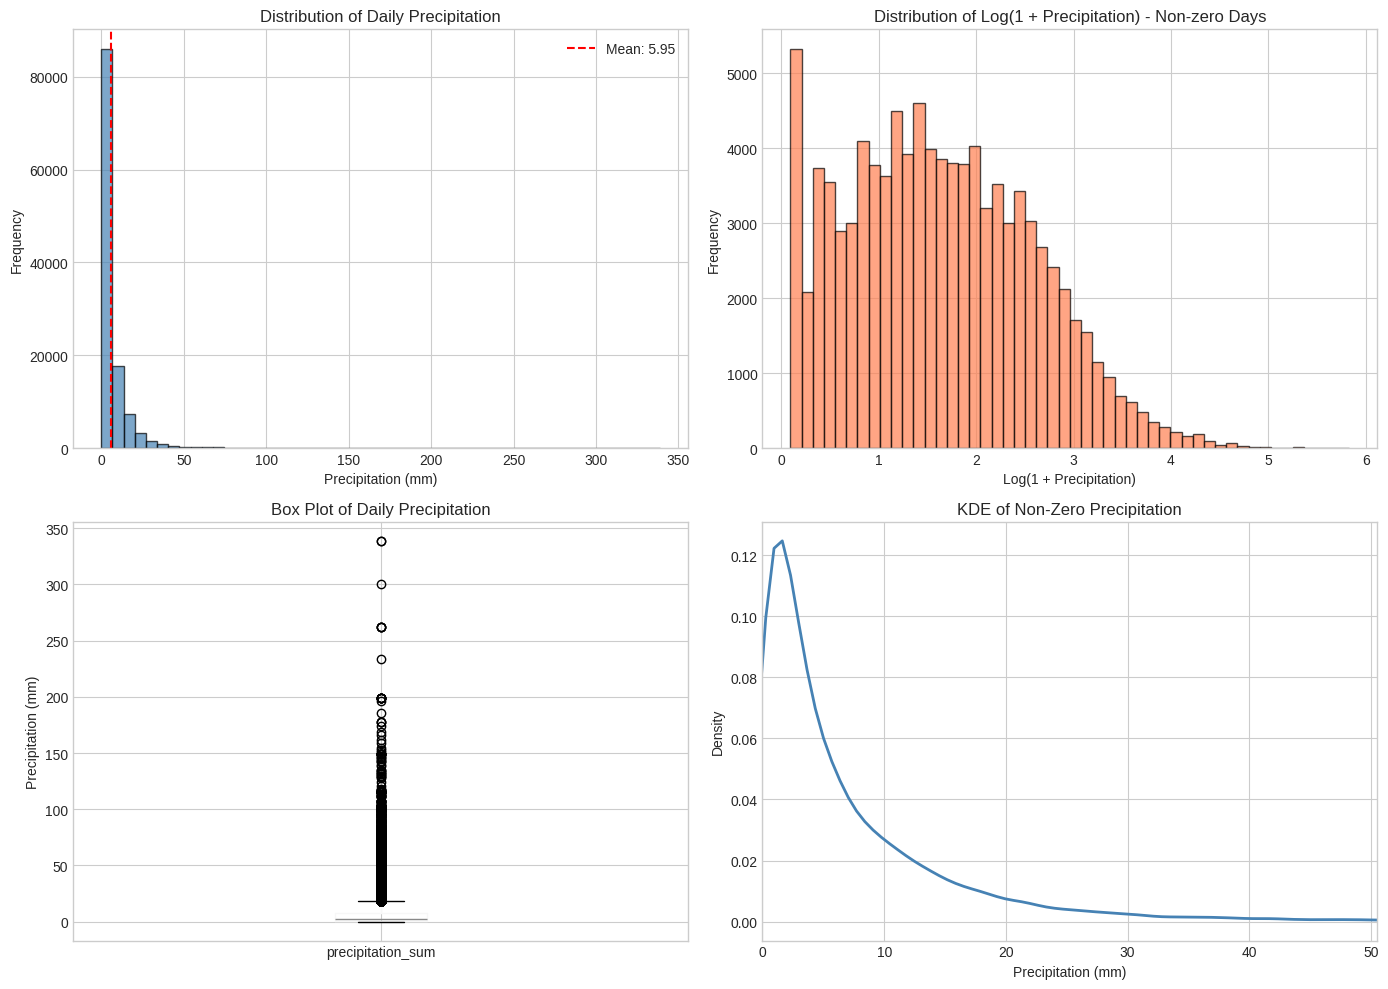

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of all precipitation
ax1 = axes[0, 0]
train_df['precipitation_sum'].hist(bins=50, ax=ax1, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_title('Distribution of Daily Precipitation', fontsize=12)
ax1.set_xlabel('Precipitation (mm)')
ax1.set_ylabel('Frequency')
ax1.axvline(train_df['precipitation_sum'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['precipitation_sum'].mean():.2f}")
ax1.legend()

# Log-transformed histogram (non-zero values)
ax2 = axes[0, 1]
train_df_nonzero = train_df[train_df['precipitation_sum'] > 0]['precipitation_sum']
ax2.hist(np.log1p(train_df_nonzero), bins=50, color='coral', edgecolor='black', alpha=0.7)
ax2.set_title('Distribution of Log(1 + Precipitation) - Non-zero Days', fontsize=12)
ax2.set_xlabel('Log(1 + Precipitation)')
ax2.set_ylabel('Frequency')

# Box plot
ax3 = axes[1, 0]
train_df.boxplot(column='precipitation_sum', ax=ax3)
ax3.set_title('Box Plot of Daily Precipitation', fontsize=12)
ax3.set_ylabel('Precipitation (mm)')

# KDE plot for non-zero precipitation
ax4 = axes[1, 1]
train_df_nonzero.plot.kde(ax=ax4, color='steelblue', linewidth=2)
ax4.set_title('KDE of Non-Zero Precipitation', fontsize=12)
ax4.set_xlabel('Precipitation (mm)')
ax4.set_xlim(0, train_df_nonzero.quantile(0.99))

plt.tight_layout()
plt.show()

In [ ]:
# Add temporal features
train_df['year'] = train_df['time'].dt.year
train_df['month'] = train_df['time'].dt.month
train_df['day_of_year'] = train_df['time'].dt.dayofyear

# Define Sri Lankan monsoon seasons
def get_season(month):
    if month in [5, 6, 7, 8, 9]:  # Southwest Monsoon (Yala)
        return 'SW Monsoon (May-Sep)'
    elif month in [10, 11]:  # Second Inter-monsoon
        return 'Inter-monsoon 2 (Oct-Nov)'
    elif month in [12, 1, 2]:  # Northeast Monsoon (Maha)
        return 'NE Monsoon (Dec-Feb)'
    else:  # First Inter-monsoon
        return 'Inter-monsoon 1 (Mar-Apr)'

train_df['season'] = train_df['month'].apply(get_season)
print("Season distribution:")
print(train_df['season'].value_counts())

Season distribution:
season
SW Monsoon (May-Sep)         48873
NE Monsoon (Dec-Feb)         29544
Inter-monsoon 1 (Mar-Apr)    20471
Inter-monsoon 2 (Oct-Nov)    19096
Name: count, dtype: int64


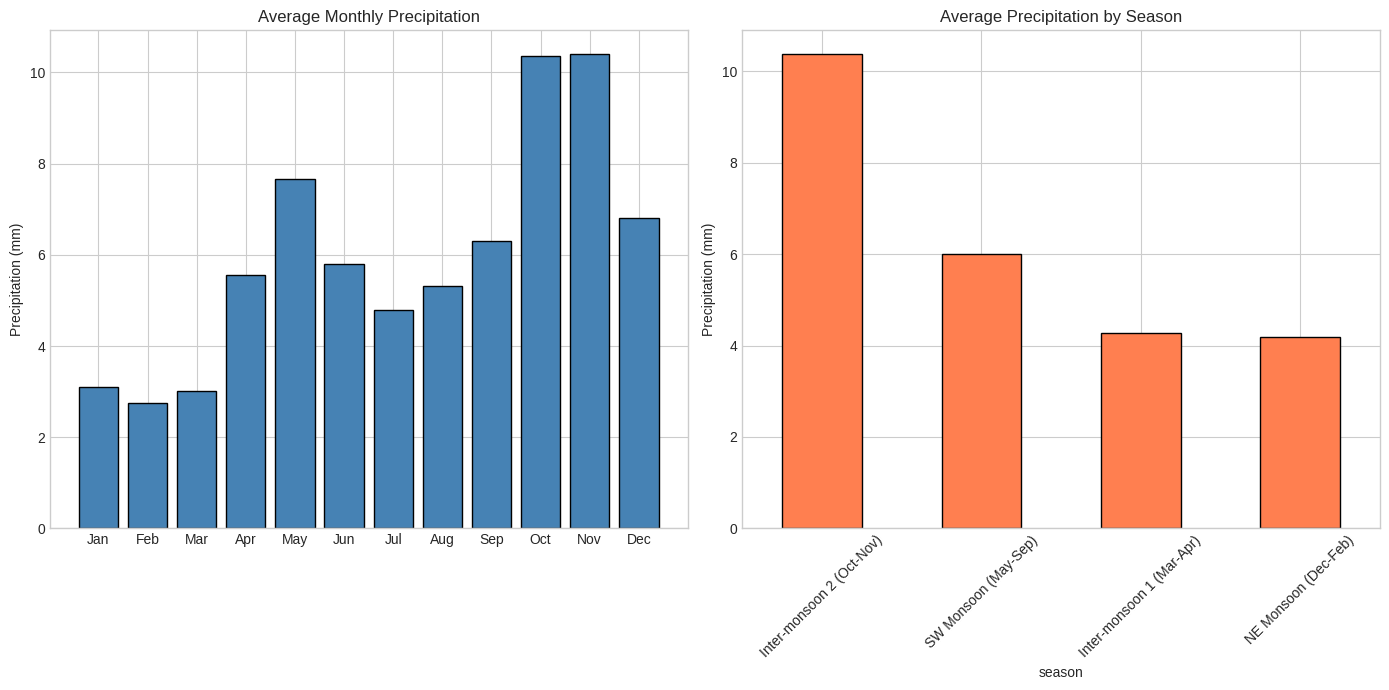

In [ ]:
# Monthly and seasonal patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Monthly average precipitation
monthly_precip = train_df.groupby('month')['precipitation_sum'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0].bar(months, monthly_precip.values, color='steelblue', edgecolor='black')
axes[0].set_title('Average Monthly Precipitation', fontsize=12)
axes[0].set_ylabel('Precipitation (mm)')

# Seasonal precipitation
seasonal_precip = train_df.groupby('season')['precipitation_sum'].mean().sort_values(ascending=False)
seasonal_precip.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Average Precipitation by Season', fontsize=12)
axes[1].set_ylabel('Precipitation (mm)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

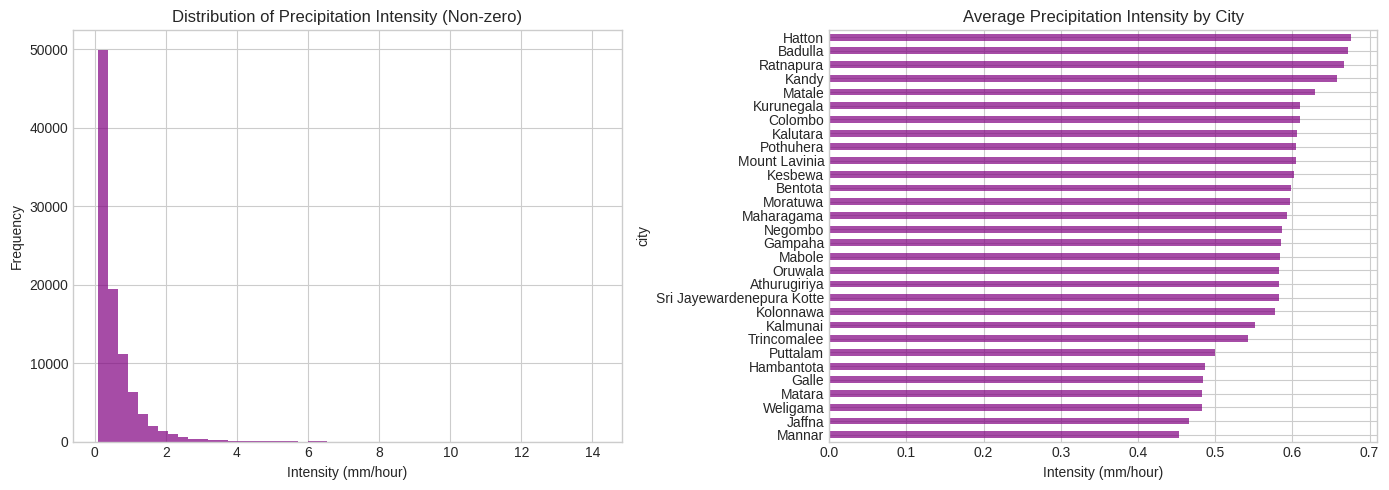

In [ ]:
# Precipitation intensity (mm per hour)
train_df['precip_intensity'] = train_df.apply(
    lambda row: row['precipitation_sum'] / row['precipitation_hours'] if row['precipitation_hours'] > 0 else 0,
    axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of intensity
train_df[train_df['precip_intensity'] > 0]['precip_intensity'].hist(bins=50, ax=axes[0], color='purple', alpha=0.7)
axes[0].set_title('Distribution of Precipitation Intensity (Non-zero)', fontsize=12)
axes[0].set_xlabel('Intensity (mm/hour)')
axes[0].set_ylabel('Frequency')

# Intensity by city
intensity_by_city = train_df[train_df['precip_intensity'] > 0].groupby('city')['precip_intensity'].mean().sort_values()
intensity_by_city.plot(kind='barh', ax=axes[1], color='purple', alpha=0.7)
axes[1].set_title('Average Precipitation Intensity by City', fontsize=12)
axes[1].set_xlabel('Intensity (mm/hour)')

plt.tight_layout()
plt.show()

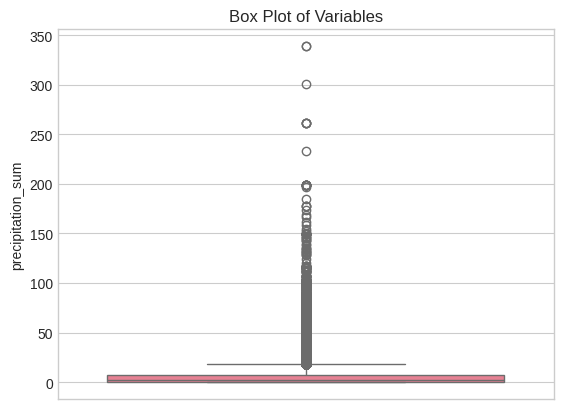

In [ ]:
sns.boxplot(data=train_df['precipitation_sum'])
plt.title('Box Plot of Variables')
plt.show()

## Exploring Apparent Temperature

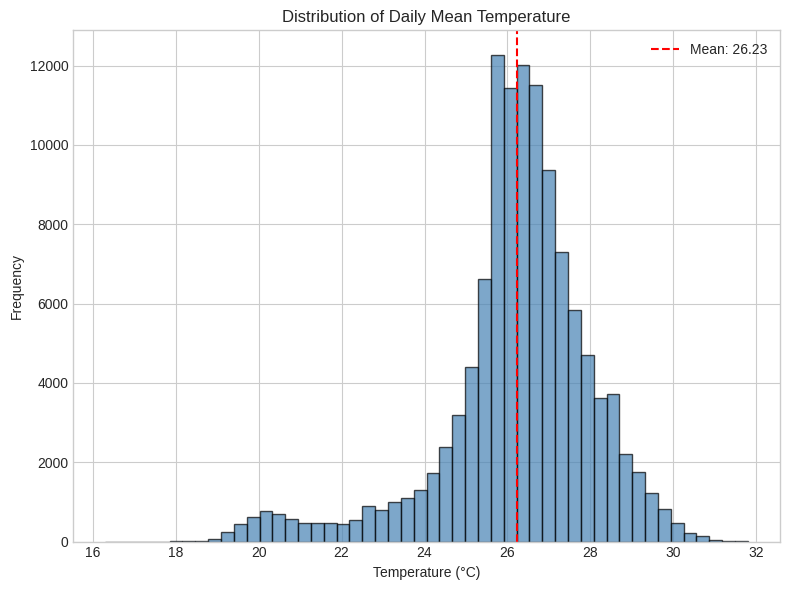

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
train_df['temperature_2m_mean'].hist(bins=50, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Distribution of Daily Mean Temperature', fontsize=12)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Frequency')
ax.axvline(train_df['temperature_2m_mean'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['temperature_2m_mean'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

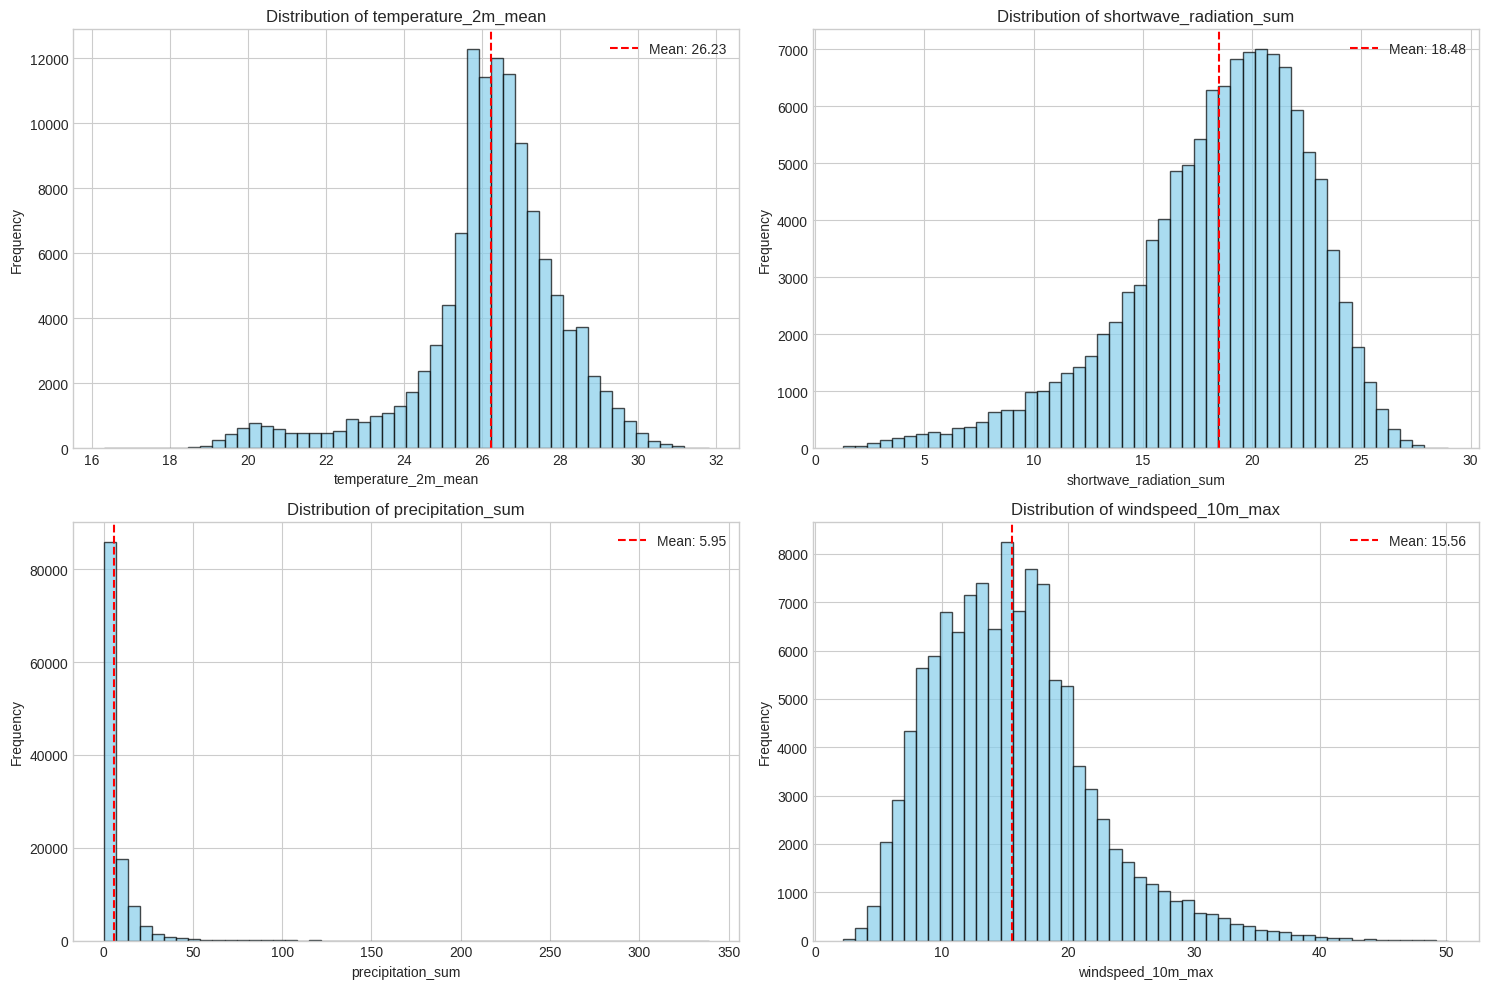

In [ ]:
variables_to_plot = ['temperature_2m_mean', 'shortwave_radiation_sum', 'precipitation_sum', 'windspeed_10m_max']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

for i, var in enumerate(variables_to_plot):
    axes[i].hist(train_df[var], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {var}', fontsize=12)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(train_df[var].mean(), color='red', linestyle='--', label=f"Mean: {train_df[var].mean():.2f}")
    axes[i].legend()

plt.tight_layout()
plt.show()

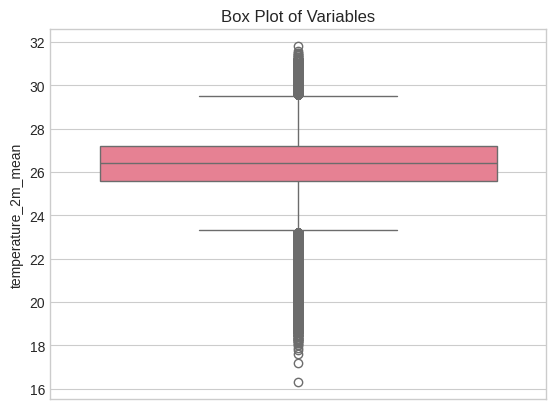

In [ ]:
sns.boxplot(data=train_df['temperature_2m_mean'])
plt.title('Box Plot of Variables')
plt.show()

## Analyzing Windspeed and Evapotranspiration

In [14]:
WEATHER = df.copy()

print(WEATHER.head(5))

        time  temperature_2m_max  temperature_2m_min  temperature_2m_mean  \
0 2010-01-01                30.0                22.7                 26.1   
1 2010-01-02                29.9                23.5                 26.2   
2 2010-01-03                29.5                23.2                 26.0   
3 2010-01-04                28.9                21.9                 25.3   
4 2010-01-05                28.1                21.3                 24.5   

   apparent_temperature_max  apparent_temperature_min  \
0                      34.4                      25.2   
1                      33.8                      26.2   
2                      34.3                      26.3   
3                      31.6                      23.4   
4                      30.1                      23.1   

   apparent_temperature_mean  shortwave_radiation_sum  precipitation_sum  \
0                       29.2                    20.92                0.0   
1                       29.8              

In [15]:
WEATHER['time'] = pd.to_datetime(WEATHER['time'])

WEATHER = WEATHER.sort_values(by=['city', 'time']).reset_index(drop=True)

cleaned_WEATHER = []

for city_name, group in WEATHER.groupby('city'):
  group = group.copy()

  numeric_cols = group.select_dtypes(include=[np.number]).columns


  group[numeric_cols] = group[numeric_cols].interpolate(method='linear')
  group[numeric_cols] = group[numeric_cols].ffill().bfill()

  cleaned_WEATHER.append(group)

WEATHER = pd.concat(cleaned_WEATHER).reset_index(drop=True)

In [16]:
zone_map = {
        # --- WET ZONE ---
        'Colombo': 'Wet Zone', 'Mount Lavinia': 'Wet Zone', 'Kesbewa': 'Wet Zone',
        'Moratuwa': 'Wet Zone', 'Maharagama': 'Wet Zone', 'Ratnapura': 'Wet Zone',
        'Galle': 'Wet Zone', 'Athurugiriya': 'Wet Zone', 'Weligama': 'Wet Zone',
        'Matara': 'Wet Zone', 'Kolonnawa': 'Wet Zone', 'Gampaha': 'Wet Zone',
        'Kalutara': 'Wet Zone', 'Bentota': 'Wet Zone', 'Mabole': 'Wet Zone',
        'Hatton': 'Wet Zone', 'Oruwala': 'Wet Zone', 'Negombo': 'Wet Zone',
        'Sri Jayewardenepura Kotte': 'Wet Zone', 'Kandy': 'Wet Zone',

        # --- DRY ZONE ---
        'Jaffna': 'Dry Zone', 'Mannar': 'Dry Zone', 'Puttalam': 'Dry Zone',
        'Trincomalee': 'Dry Zone', 'Kalmunai': 'Dry Zone', 'Hambantota': 'Dry Zone',

        # --- INTERMEDIATE ZONE ---
        'Kurunegala': 'Intermediate Zone', 'Pothuhera': 'Intermediate Zone',
        'Matale': 'Intermediate Zone', 'Badulla': 'Intermediate Zone'
    }

WEATHER['zone'] = WEATHER['city'].map(zone_map)
WEATHER.head()

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,shortwave_radiation_sum,precipitation_sum,precipitation_hours,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant,et0_fao_evapotranspiration,latitude,longitude,elevation,city,zone
0,2010-01-01,29.9,22.5,26.0,33.0,24.4,28.2,21.02,0.0,0.0,17.9,37.8,20,4.89,6.900002,79.899994,27.0,Athurugiriya,Wet Zone
1,2010-01-02,30.0,23.3,26.1,32.9,25.4,29.0,17.98,0.0,0.0,17.7,36.0,20,4.09,6.900002,79.899994,27.0,Athurugiriya,Wet Zone
2,2010-01-03,29.5,22.9,25.8,33.3,25.6,29.1,18.05,0.2,1.0,16.6,34.9,16,3.83,6.900002,79.899994,27.0,Athurugiriya,Wet Zone
3,2010-01-04,28.7,21.7,25.2,31.5,23.0,27.5,18.46,0.0,0.0,18.2,38.2,4,4.12,6.900002,79.899994,27.0,Athurugiriya,Wet Zone
4,2010-01-05,28.0,21.1,24.4,30.0,22.6,25.8,23.54,0.0,0.0,17.4,36.0,3,5.04,6.900002,79.899994,27.0,Athurugiriya,Wet Zone


In [17]:
# Define the mapping of cities to their respective Wind Zones
wind_zone_map = {
    # Zone I: Northern & Eastern Coasts
    'Jaffna': 'Zone I',
    'Trincomalee': 'Zone I',
    'Kalmunai': 'Zone I', # Eastern Coast

    # Zone II: Intermediate areas
    'Puttalam': 'Zone II',
    'Mannar': 'Zone II',
    'Kurunegala': 'Zone II', # Intermediate climatic zone
    'Pothuhera': 'Zone II',   # Intermediate climatic zone
    'Matale': 'Zone II',     # Intermediate climatic zone

    # Zone III: Southern & Western areas
    'Colombo': 'Zone III',
    'Kandy': 'Zone III',
    'Galle': 'Zone III',
    'Mount Lavinia': 'Zone III',
    'Kesbewa': 'Zone III',
    'Moratuwa': 'Zone III',
    'Maharagama': 'Zone III',
    'Ratnapura': 'Zone III',
    'Athurugiriya': 'Zone III',
    'Weligama': 'Zone III',
    'Matara': 'Zone III',
    'Kolonnawa': 'Zone III',
    'Gampaha': 'Zone III',
    'Kalutara': 'Zone III',
    'Bentota': 'Zone III',
    'Mabole': 'Zone III',
    'Hatton': 'Zone III',
    'Oruwala': 'Zone III',
    'Negombo': 'Zone III',
    'Sri Jayewardenepura Kotte': 'Zone III',
    'Hambantota': 'Zone III', # Southern Coast
    'Badulla': 'Zone III'    # Hilly/Southern Central, aligns with Zone III
}


WEATHER['wind_zone'] = WEATHER['city'].map(wind_zone_map)

WEATHER['wind_zone'] = WEATHER['wind_zone'].fillna('Unknown')

print(WEATHER.head())

        time  temperature_2m_max  temperature_2m_min  temperature_2m_mean  \
0 2010-01-01                29.9                22.5                 26.0   
1 2010-01-02                30.0                23.3                 26.1   
2 2010-01-03                29.5                22.9                 25.8   
3 2010-01-04                28.7                21.7                 25.2   
4 2010-01-05                28.0                21.1                 24.4   

   apparent_temperature_max  apparent_temperature_min  \
0                      33.0                      24.4   
1                      32.9                      25.4   
2                      33.3                      25.6   
3                      31.5                      23.0   
4                      30.0                      22.6   

   apparent_temperature_mean  shortwave_radiation_sum  precipitation_sum  \
0                       28.2                    21.02                0.0   
1                       29.0              

In [40]:
# Save the cleaned, sorted, and mapped data for the backend to use
WEATHER.to_csv('../backend/data/Cleaned_SriLanka_Weather_Dataset.csv', index=False)

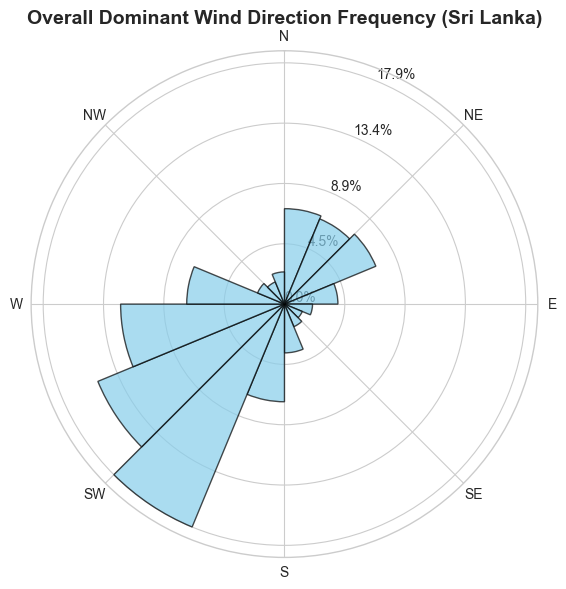

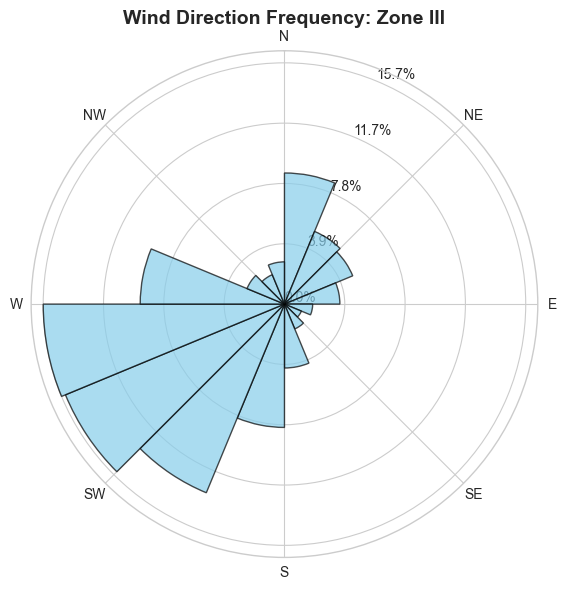

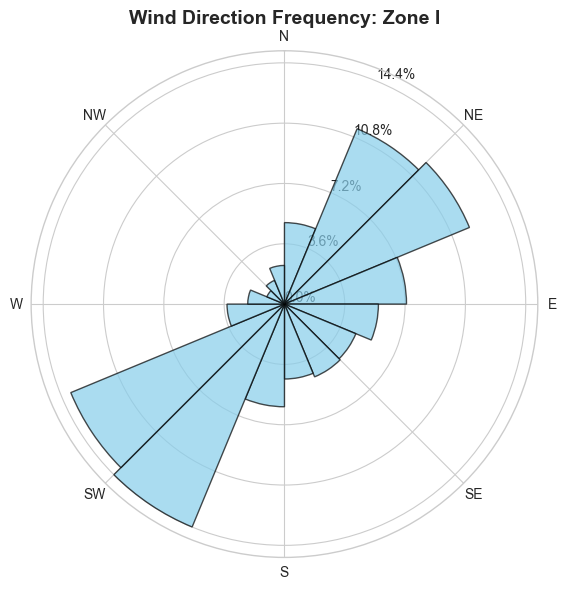

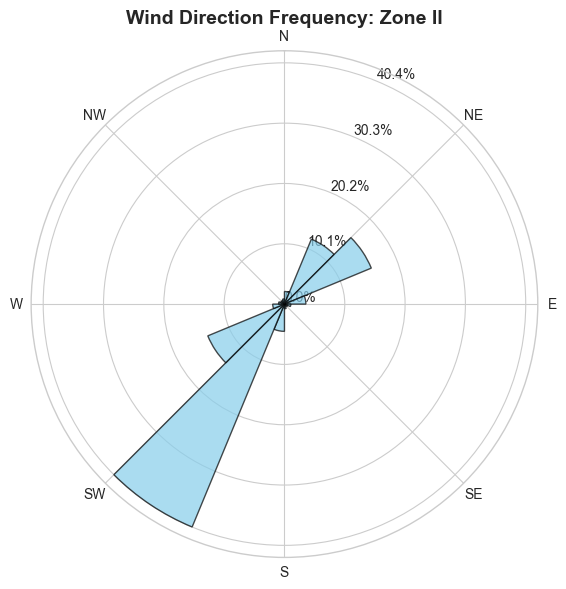

In [18]:
import numpy as np
import matplotlib.pyplot as plt

WEATHER_with_wind_dir = WEATHER.copy()

WEATHER_with_wind_dir['zone'] = WEATHER_with_wind_dir['city'].map(zone_map)
WEATHER_with_wind_dir['wind_zone'] = WEATHER_with_wind_dir['city'].map(wind_zone_map).fillna('Unknown')

def plot_wind_rose(data, title, color='skyblue'):

    num_bins = 16
    bins = np.linspace(0, 360, num_bins + 1)
    bin_centers = np.deg2rad(bins[:-1] + np.diff(bins)/2)


    counts, _ = np.histogram(data['winddirection_10m_dominant'], bins=bins)
    frequency = counts / counts.sum() if counts.sum() > 0 else counts


    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))
    ax.bar(bin_centers, frequency, width=np.deg2rad(360/num_bins),
           bottom=0.0, color=color, edgecolor='black', alpha=0.7)


    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1) # Clockwise
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


    max_freq = max(frequency) if len(frequency) > 0 else 0.1
    ticks = np.linspace(0, max_freq, 5)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f'{y*100:.1f}%' for y in ticks])

    plt.title(title, pad=20, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()




plot_wind_rose(WEATHER_with_wind_dir, 'Overall Dominant Wind Direction Frequency (Sri Lanka)')

colors = {'Zone 1': '#3498db', 'Zone 2': '#e67e22', 'Zone 3': '#2ecc71', 'Unknown': '#95a5a6'}

for w_zone in WEATHER_with_wind_dir['wind_zone'].unique():
    subset = WEATHER_with_wind_dir[WEATHER_with_wind_dir['wind_zone'] == w_zone]
    if not subset.empty:
        plot_wind_rose(subset, f'Wind Direction Frequency: {w_zone}', color=colors.get(w_zone, 'skyblue'))


ANALYZING MONTHLY WIND SPEED TRENDS BY ZONE


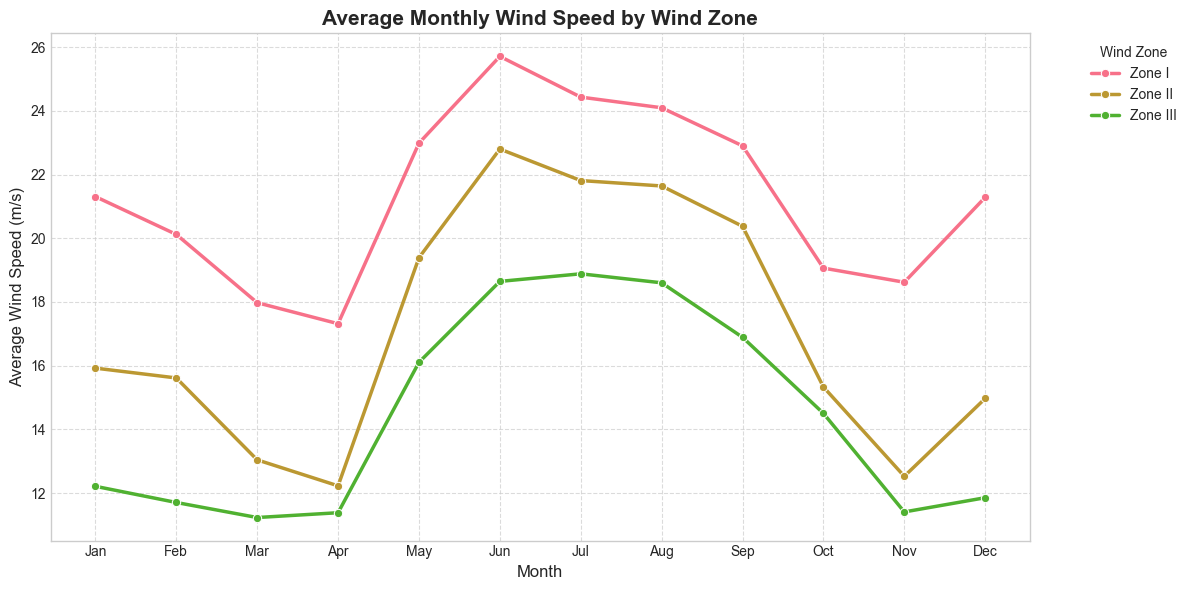


Summary Table (Average Speed per Month):
wind_zone     Zone I    Zone II   Zone III
month                                     
1          21.306452  15.921613  12.211699
2          20.119241  15.613519  11.703959
3          17.975960  13.041935  11.231651
4          17.316587  12.226381  11.382565
5          22.985407  19.388894  16.104388
6          25.708927  22.799853  18.644639
7          24.430769  21.811117  18.883194
8          24.096278  21.640844  18.600643
9          22.900940  20.375333  16.890723
10         19.062862  15.330521  14.502109
11         18.618376  12.526359  11.407249
12         21.285194  14.968983  11.853519


In [19]:
import seaborn as sns

def plot_monthly_wind_speed(df):
    print(f"\n" + "="*60)
    print(f"ANALYZING MONTHLY WIND SPEED TRENDS BY ZONE")
    print("="*60)


    df['time'] = pd.to_datetime(df['time'])
    df['month'] = df['time'].dt.month


    monthly_stats = df.groupby(['wind_zone', 'month'])['windspeed_10m_max'].mean().reset_index()

    plt.figure(figsize=(12, 6))


    sns.lineplot(data=monthly_stats, x='month', y='windspeed_10m_max',
                 hue='wind_zone', marker='o', linewidth=2.5)


    plt.title('Average Monthly Wind Speed by Wind Zone', fontsize=15, fontweight='bold')
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Average Wind Speed (m/s)', fontsize=12)
    plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Wind Zone', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()


    pivot_table = monthly_stats.pivot(index='month', columns='wind_zone', values='windspeed_10m_max')
    print("\nSummary Table (Average Speed per Month):")
    print(pivot_table)


plot_monthly_wind_speed(WEATHER_with_wind_dir)


MAPPING AVERAGE EVAPOTRANSPIRATION BY CITY


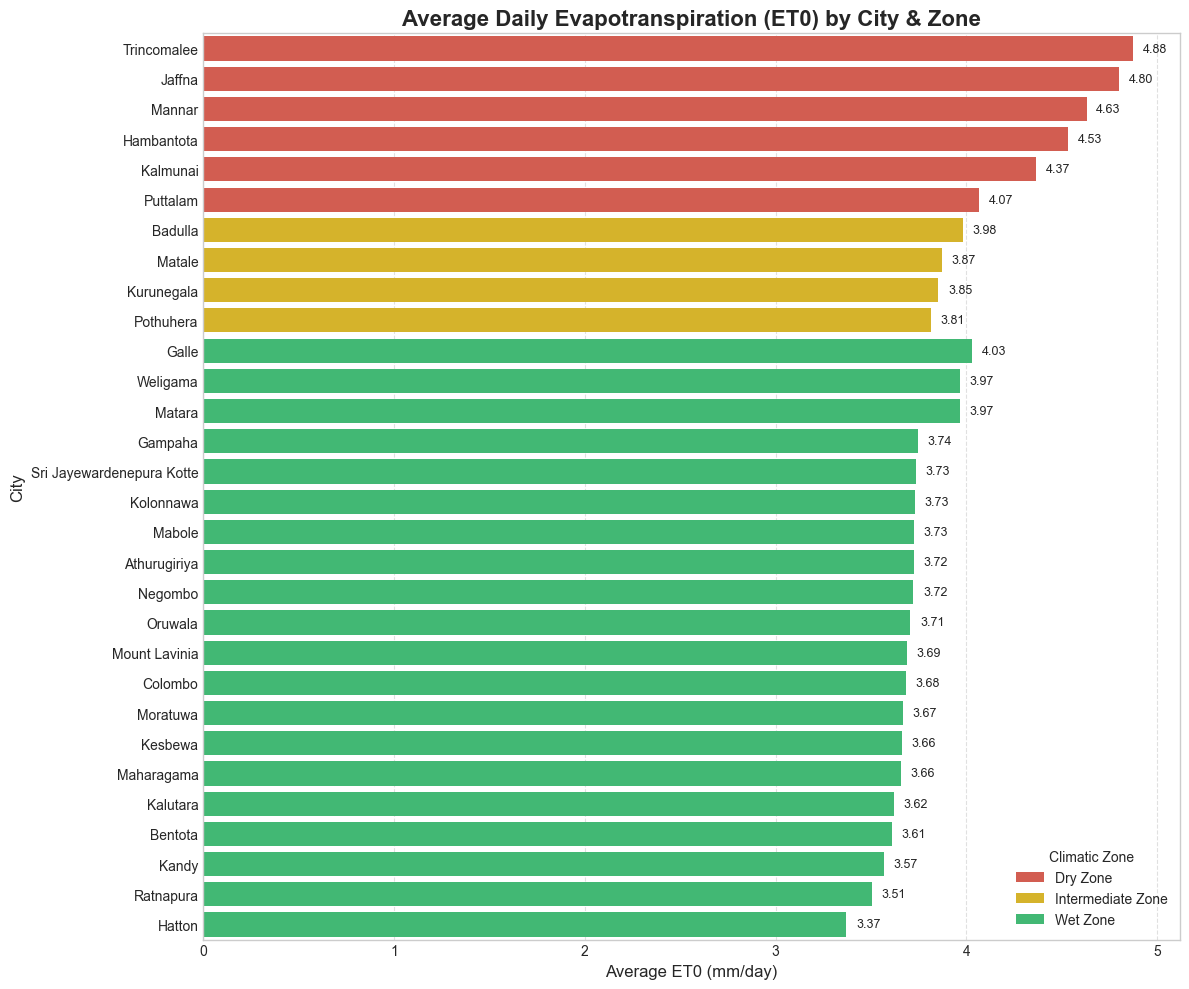

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def map_evaporation_by_city(df):
    print(f"\n" + "="*60)
    print(f"MAPPING AVERAGE EVAPOTRANSPIRATION BY CITY")
    print("="*60)


    city_stats = df.groupby(['zone', 'city'])['et0_fao_evapotranspiration'].mean().reset_index()

    city_stats = city_stats.sort_values(by=['zone', 'et0_fao_evapotranspiration'], ascending=[True, False])

    plt.figure(figsize=(12, 10))


    sns.barplot(
        data=city_stats,
        x='et0_fao_evapotranspiration',
        y='city',
        hue='zone',
        dodge=False,
        palette={'Wet Zone': '#2ecc71', 'Intermediate Zone': '#f1c40f', 'Dry Zone': '#e74c3c'}
    )

    plt.title('Average Daily Evapotranspiration (ET0) by City & Zone', fontsize=16, fontweight='bold')
    plt.xlabel('Average ET0 (mm/day)', fontsize=12)
    plt.ylabel('City', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.legend(title='Climatic Zone', loc='lower right')

    for index, value in enumerate(city_stats['et0_fao_evapotranspiration']):
        plt.text(value + 0.05, index, f'{value:.2f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    return city_stats


if 'zone' not in WEATHER.columns:
    WEATHER['zone'] = WEATHER['city'].map(zone_map)

avg_evap_stats = map_evaporation_by_city(WEATHER)

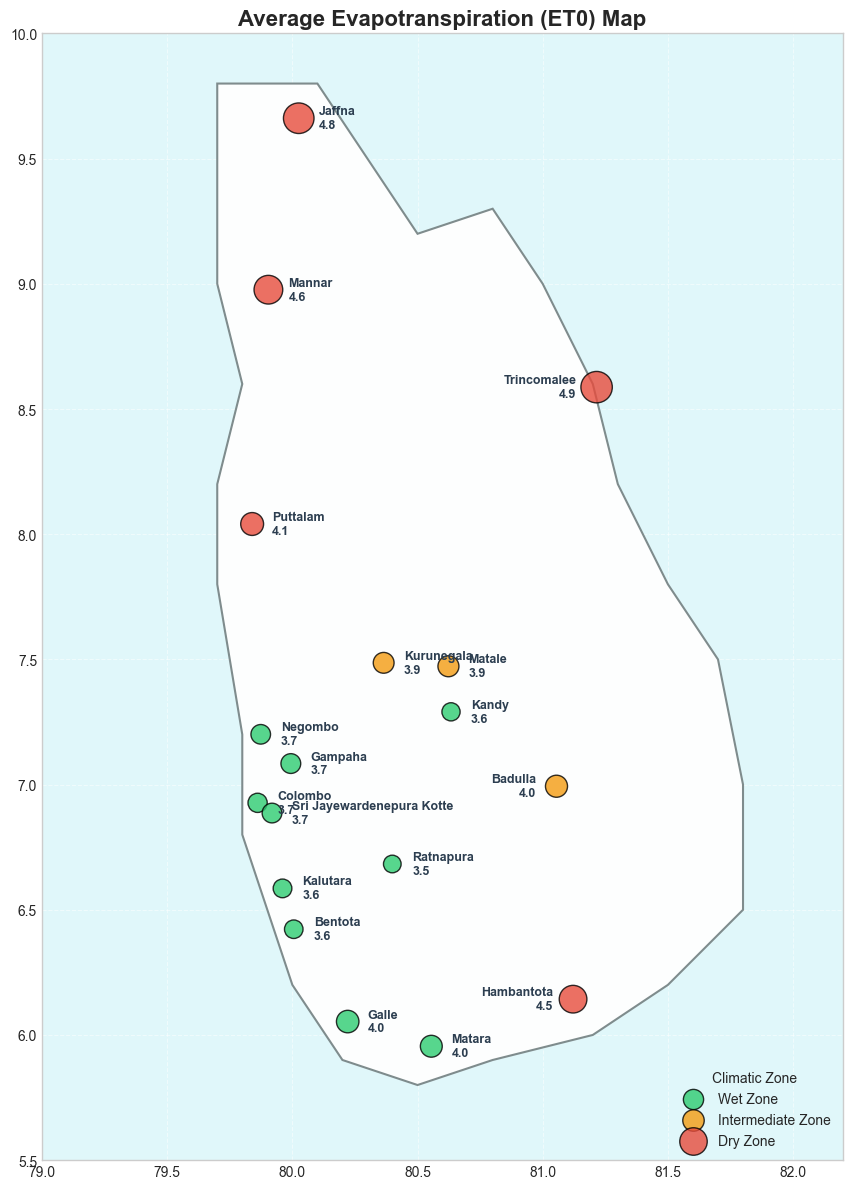

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np


city_coords = {
    'Jaffna': [9.6615, 80.0255], 'Mannar': [8.9766, 79.9043],
    'Vavuniya': [8.7514, 80.4971], 'Trincomalee': [8.5874, 81.2152],
    'Anuradhapura': [8.3114, 80.4037], 'Puttalam': [8.0408, 79.8394],
    'Polonnaruwa': [7.9403, 81.0188], 'Batticaloa': [7.7310, 81.6747],
    'Kurunegala': [7.4863, 80.3647], 'Matale': [7.4726, 80.6234],
    'Kandy': [7.2906, 80.6337], 'Negombo': [7.2008, 79.8737],
    'Gampaha': [7.0840, 79.9939], 'Colombo': [6.9271, 79.8612],
    'Sri Jayewardenepura Kotte': [6.8863, 79.9187], 'Nuwara Eliya': [6.9497, 80.7891],
    'Badulla': [6.9934, 81.0550], 'Ratnapura': [6.6828, 80.3992],
    'Kalutara': [6.5854, 79.9607], 'Bentota': [6.4223, 80.0056],
    'Galle': [6.0535, 80.2210], 'Matara': [5.9549, 80.5550],
    'Hambantota': [6.1429, 81.1212], 'Ampara': [7.2825, 81.6667],
    'Monaragala': [6.8714, 81.3487]
}


sl_outline = [
    (79.7, 9.8), (80.1, 9.8), (80.3, 9.5), (80.5, 9.2), (80.8, 9.3), # North (Jaffna/Mullaitivu)
    (81.0, 9.0), (81.2, 8.6), (81.3, 8.2), (81.5, 7.8), (81.7, 7.5), # East Coast
    (81.8, 7.0), (81.8, 6.5), (81.5, 6.2), (81.2, 6.0), (80.8, 5.9), # South East
    (80.5, 5.8), (80.2, 5.9), (80.0, 6.2), (79.9, 6.5), (79.8, 6.8), # South West
    (79.8, 7.2), (79.7, 7.8), (79.7, 8.2), (79.8, 8.6), (79.7, 9.0), # West Coast
    (79.7, 9.8)
]

def plot_custom_map(df):

    if 'zone' not in df.columns:
        df['zone'] = df['city'].map(zone_map)

    map_data = df.groupby(['city', 'zone'])['et0_fao_evapotranspiration'].mean().reset_index()
    map_data['lat'] = map_data['city'].map(lambda x: city_coords.get(x, [np.nan, np.nan])[0])
    map_data['lon'] = map_data['city'].map(lambda x: city_coords.get(x, [np.nan, np.nan])[1])
    map_data = map_data.dropna(subset=['lat', 'lon'])


    fig, ax = plt.subplots(figsize=(10, 12))
    ax.set_facecolor('#e0f7fa') # Ocean Color


    poly = patches.Polygon(sl_outline, closed=True, facecolor='#fdfefe', edgecolor='#7f8c8d', linewidth=1.5)
    ax.add_patch(poly)


    colors = {'Wet Zone': '#2ecc71', 'Intermediate Zone': '#f39c12', 'Dry Zone': '#e74c3c'}

    for zone, color in colors.items():
        subset = map_data[map_data['zone'] == zone]
        if subset.empty: continue

        ax.scatter(
            subset['lon'], subset['lat'],
            s=subset['et0_fao_evapotranspiration']**3.5 * 2, # Bubble size
            color=color, alpha=0.8, edgecolor='black', linewidth=1,
            label=zone, zorder=5
        )


    for _, row in map_data.iterrows():

        x_offset = 0.08
        ha = 'left'
        if row['lon'] > 81.0:
            x_offset = -0.08
            ha = 'right'

        ax.text(
            row['lon'] + x_offset, row['lat'],
            f"{row['city']}\n{row['et0_fao_evapotranspiration']:.1f}",
            fontsize=9, va='center', ha=ha, fontweight='bold', color='#2c3e50', zorder=10
        )


    ax.set_title('Average Evapotranspiration (ET0) Map', fontsize=16, fontweight='bold')
    ax.set_xlim(79.0, 82.2)
    ax.set_ylim(5.5, 10.0)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', color='white', alpha=0.5)

    legend = ax.legend(title='Climatic Zone', loc='lower right')
    legend.get_frame().set_alpha(0.9)

    plt.tight_layout()
    plt.show()


if 'WEATHER_with_wind_dir' in locals():
    plot_custom_map(WEATHER_with_wind_dir)
else:
    plot_custom_map(WEATHER)

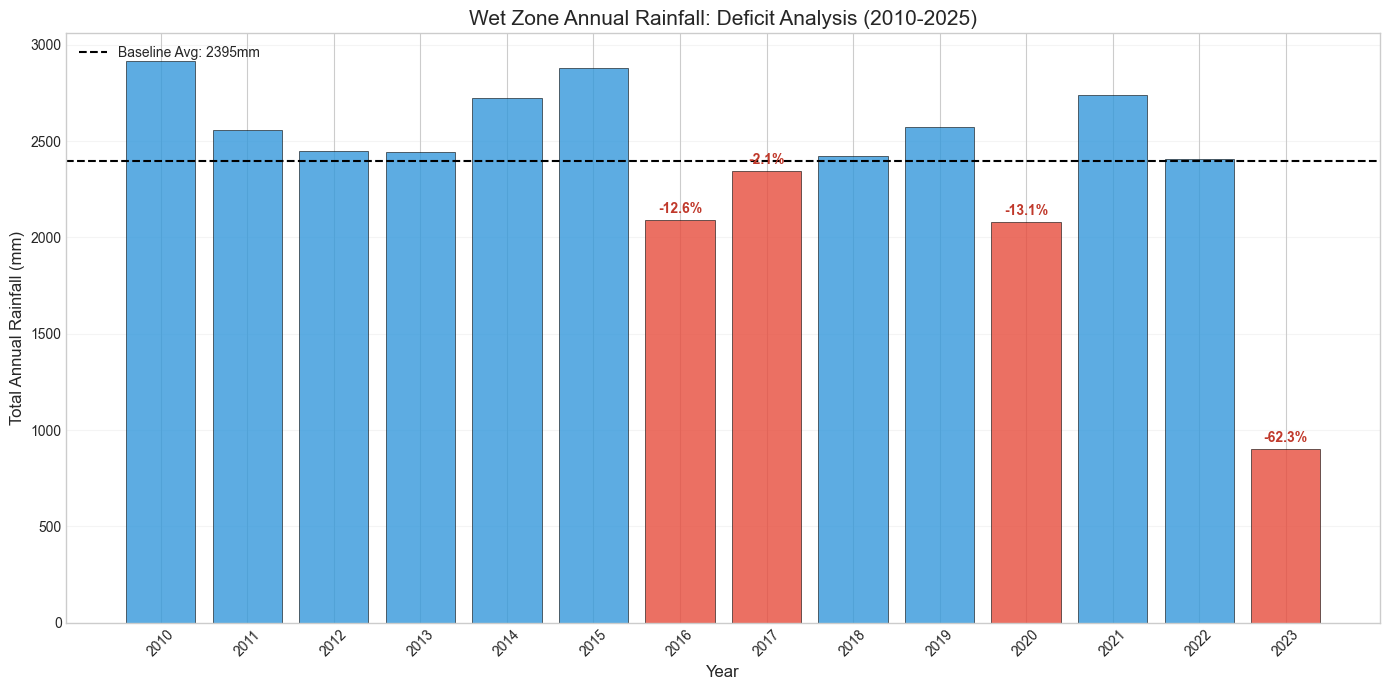

Year   | Rainfall (mm)   | Deficit %         
---------------------------------------------
2016   | 2092.43         | -12.63%
2017   | 2344.65         | -2.10%
2020   | 2080.45         | -13.13%
2023   | 903.15          | -62.29%


In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Fix: Define zonal_daily derived from WEATHER dataframe
# This variable was missing in the original cell causing a NameError
weather_cols = ['et0_fao_evapotranspiration', 'precipitation_sum']
if 'WEATHER' in locals():
    zonal_daily = WEATHER.groupby(['time', 'zone'])[weather_cols].mean(numeric_only=True).unstack()
    zonal_daily.columns = [f"{col[0]}_{col[1]}" for col in zonal_daily.columns]
elif 'df_weather' in locals():
    zonal_daily = df_weather.groupby(['time', 'zone'])[weather_cols].mean(numeric_only=True).unstack()
    zonal_daily.columns = [f"{col[0]}_{col[1]}" for col in zonal_daily.columns]
else:
    print('Error: WEATHER dataframe not found for zonal_daily calculation')


annual_rain = zonal_daily.resample('YE').sum()


baseline_rain = annual_rain['precipitation_sum_Wet Zone'].mean()


plt.figure(figsize=(14, 7))


target_years = [2016, 2017, 2020, 2023]
colors = ['#e74c3c' if year in target_years else '#3498db'
          for year in annual_rain.index.year]

bars = plt.bar(annual_rain.index.year, annual_rain['precipitation_sum_Wet Zone'],
                color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

plt.axhline(baseline_rain, color='black', linestyle='--', label=f'Baseline Avg: {baseline_rain:.0f}mm')


plt.title('Wet Zone Annual Rainfall: Deficit Analysis (2010-2025)', fontsize=15)
plt.ylabel('Total Annual Rainfall (mm)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.xticks(annual_rain.index.year, rotation=45)
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.2)


for bar, year in zip(bars, annual_rain.index.year):
    if year in target_years:
        val = bar.get_height()
        perc = (val / baseline_rain - 1) * 100
        plt.text(bar.get_x() + bar.get_width()/2, val + 20, f'{perc:+.1f}%',
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#c0392b')

plt.tight_layout()
plt.show()


print(f"{'Year':<6} | {'Rainfall (mm)':<15} | {'Deficit %':<18}")
print("-" * 45)
for year in sorted(target_years):
    if year in annual_rain.index.year:
        actual = annual_rain.loc[f'{year}-12-31', 'precipitation_sum_Wet Zone']
        diff_perc = (actual / baseline_rain - 1) * 100
        print(f"{year:<6} | {actual:<15.2f} | {diff_perc:+.2f}%")

# Advance Analysis

## Objective 1: Understanding and Predicting Daily Precipitation

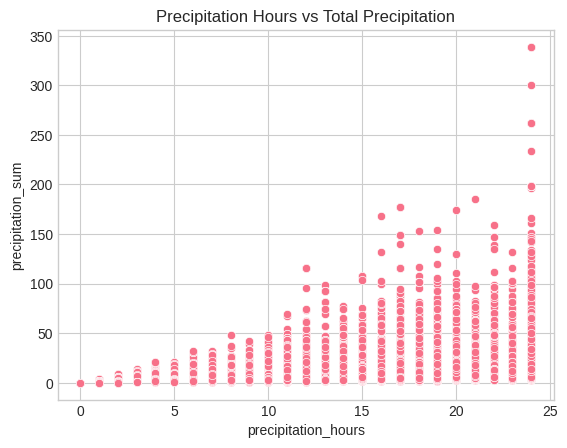

In [ ]:
sns.scatterplot(data=train_df, x='precipitation_hours', y='precipitation_sum')
plt.title('Precipitation Hours vs Total Precipitation')
plt.show()

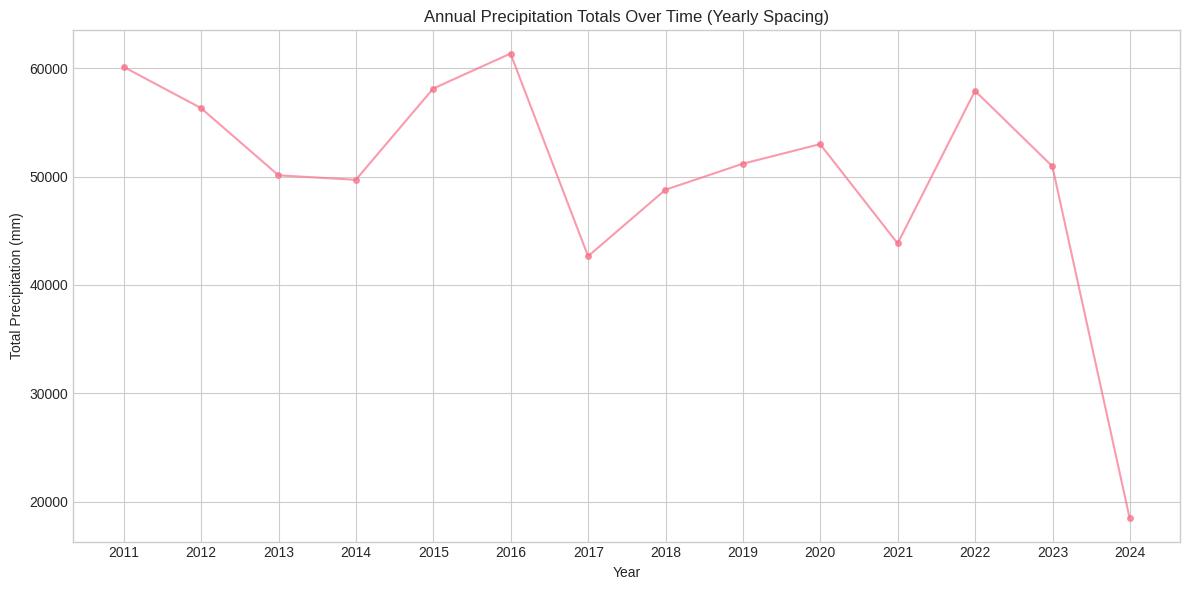

In [ ]:
import matplotlib.dates as mdates
df_time_indexed = train_df.set_index('time')

annual_precip = df_time_indexed.resample('YE')['precipitation_sum'].sum()

plt.figure(figsize=(12, 6))
plt.plot(annual_precip.index, annual_precip.values, marker='o', linestyle='-', markersize=4, alpha=0.7)

plt.title('Annual Precipitation Totals Over Time (Yearly Spacing)')
plt.xlabel('Year')
plt.ylabel('Total Precipitation (mm)')
plt.grid(True)


plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

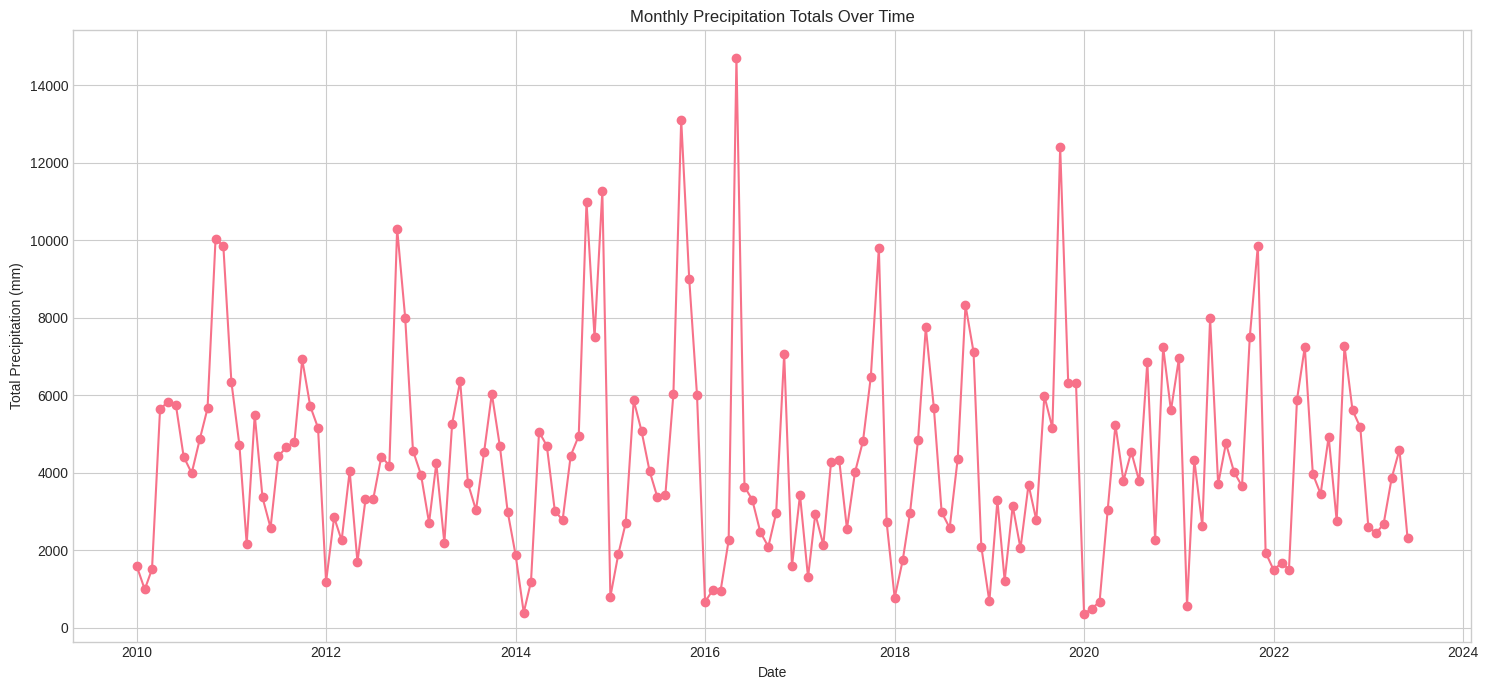

In [ ]:
monthly_totals = df_time_indexed['precipitation_sum'].resample('MS').sum()

plt.figure(figsize=(15, 7))
plt.plot(monthly_totals.index, monthly_totals.values, marker='o', linestyle='-')
plt.title('Monthly Precipitation Totals Over Time')
plt.xlabel('Date')
plt.ylabel('Total Precipitation (mm)')
plt.grid(True)
plt.tight_layout()
plt.show()

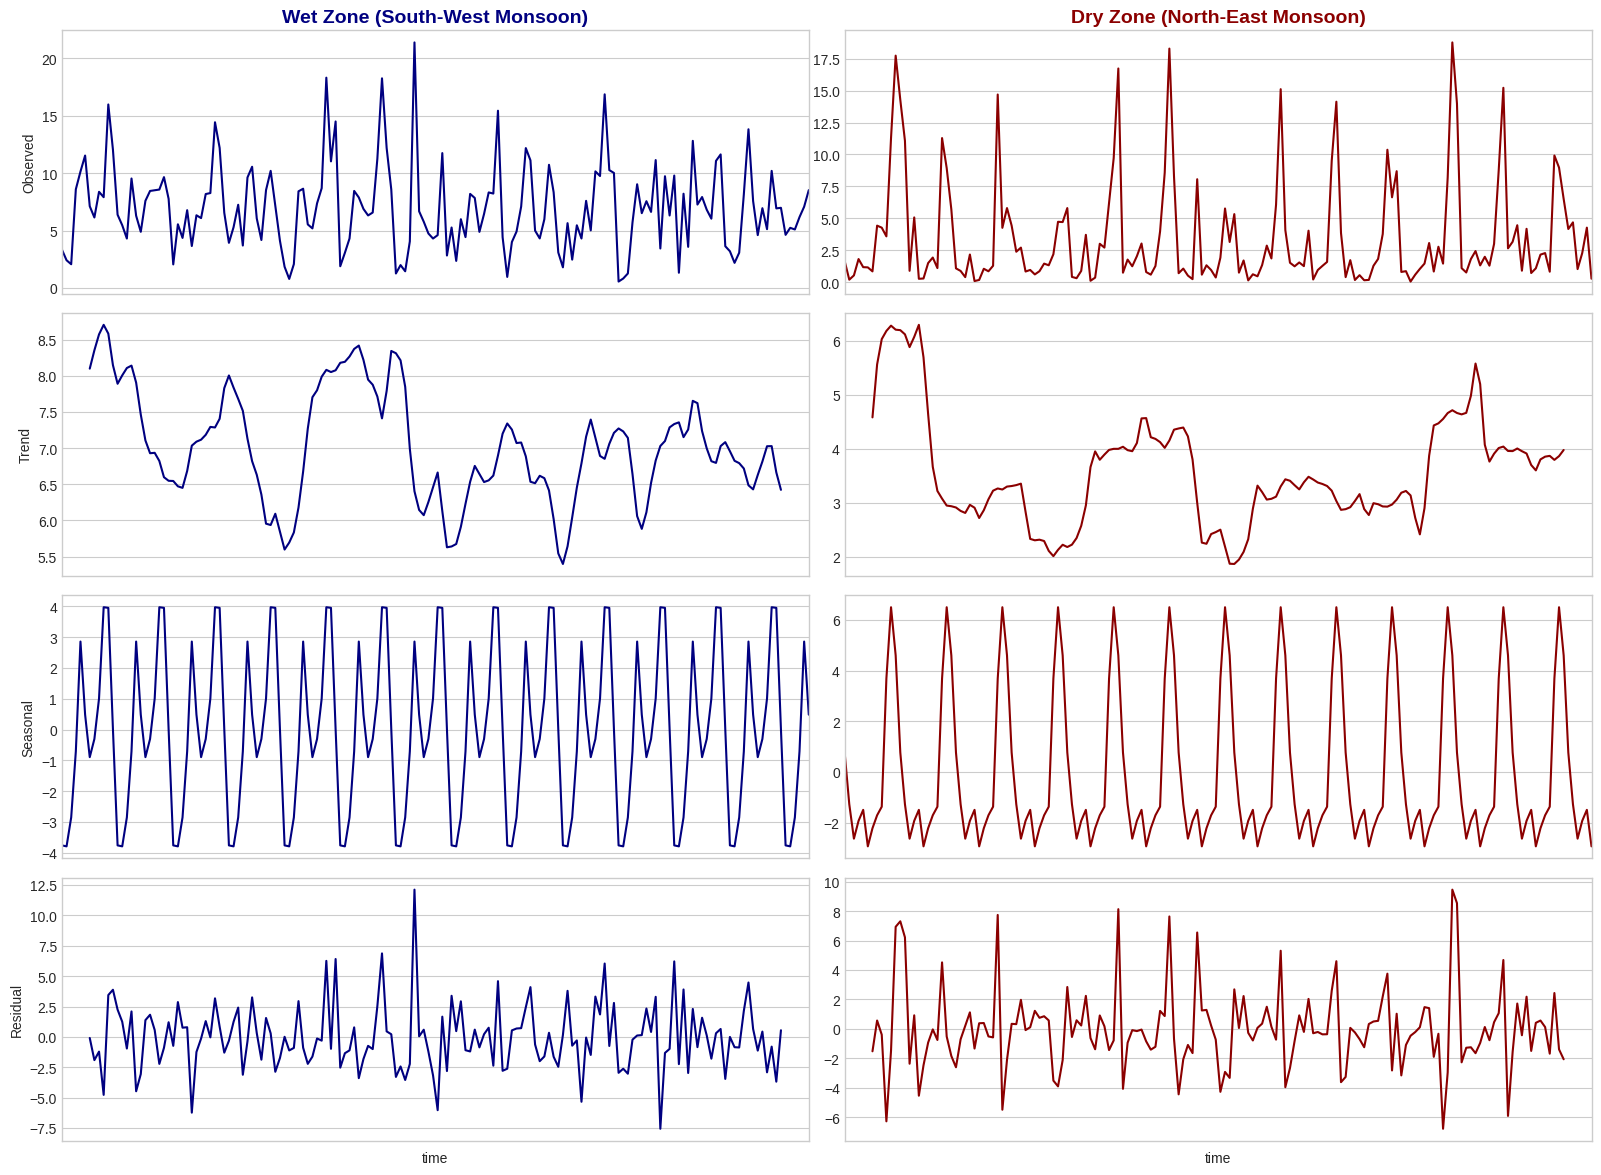

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

wet_cities = ['Colombo', 'Galle', 'Ratnapura', 'Kalutara']
dry_cities = ['Jaffna', 'Trincomalee', 'Anuradhapura', 'Vavuniya']

def get_decomposition(city_list, label):
    # Filter for cities in the list
    zone_data = train_df[train_df['city'].isin(city_list)].copy()

    # Group by Time (Average all cities in the zone together)
    zone_avg = zone_data.groupby('time')['precipitation_sum'].mean()

    # Resample to Monthly
    monthly_avg = zone_avg.resample('ME').mean()

    # Decompose
    return seasonal_decompose(monthly_avg, model='additive', period=12)


res_wet = get_decomposition(wet_cities, 'Wet Zone')
res_dry = get_decomposition(dry_cities, 'Dry Zone')


fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)


axes[0, 0].set_title("Wet Zone (South-West Monsoon)", fontsize=14, fontweight='bold', color='navy')
axes[0, 1].set_title("Dry Zone (North-East Monsoon)", fontsize=14, fontweight='bold', color='darkred')

# --- Plot Wet Zone (Left Column) ---
res_wet.observed.plot(ax=axes[0, 0], color='navy', legend=False)
axes[0, 0].set_ylabel('Observed')

res_wet.trend.plot(ax=axes[1, 0], color='navy', legend=False)
axes[1, 0].set_ylabel('Trend')

res_wet.seasonal.plot(ax=axes[2, 0], color='navy', legend=False)
axes[2, 0].set_ylabel('Seasonal')

res_wet.resid.plot(ax=axes[3, 0], color='navy', legend=False)
axes[3, 0].set_ylabel('Residual')

# --- Plot Dry Zone (Right Column) ---
res_dry.observed.plot(ax=axes[0, 1], color='darkred', legend=False)
res_dry.trend.plot(ax=axes[1, 1], color='darkred', legend=False)
res_dry.seasonal.plot(ax=axes[2, 1], color='darkred', legend=False)
res_dry.resid.plot(ax=axes[3, 1], color='darkred', legend=False)


plt.tight_layout()

for ax in axes[3, :]:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.show()

In [ ]:
df['rain_occurrence'] = (df['precipitation_sum'] > 0).astype(int)
train_df['rain_occurrence'] = (train_df['precipitation_sum'] > 0).astype(int)
test_df['rain_occurrence'] = (test_df['precipitation_sum'] > 0).astype(int)

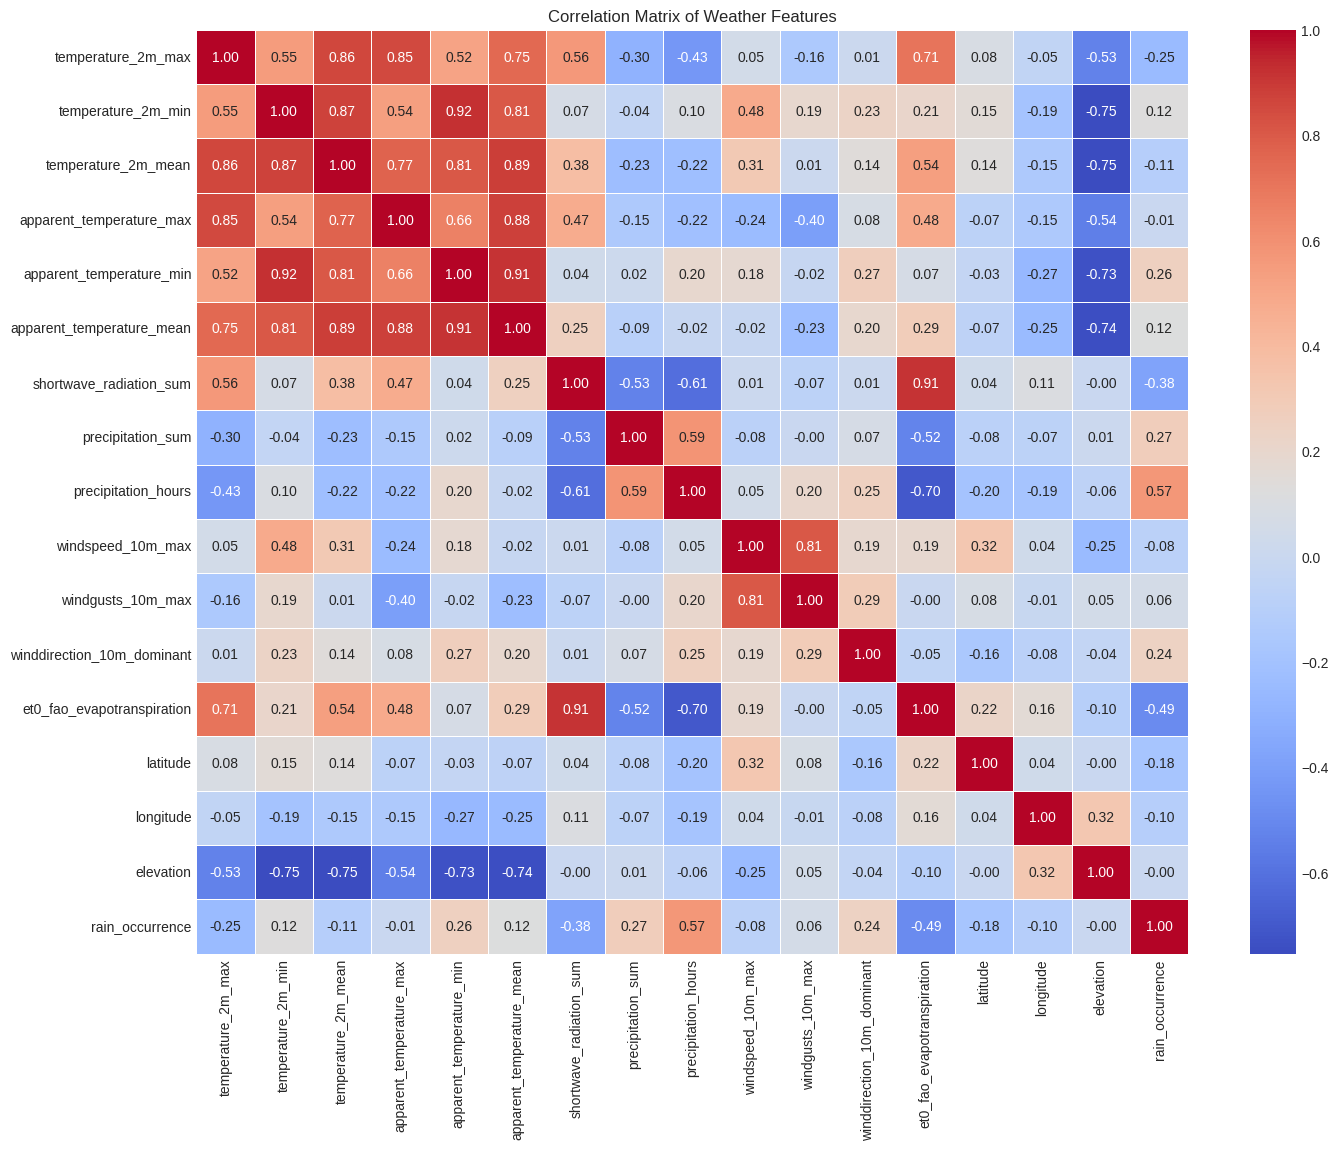


Correlations with Precipitation Sum:


,precipitation_sum
precipitation_sum,1.000000
precipitation_hours,0.588611
rain_occurrence,0.274309
winddirection_10m_dominant,0.070411
apparent_temperature_min,0.018619
elevation,0.009293
windgusts_10m_max,-0.002944
temperature_2m_min,-0.040525
longitude,-0.071649
latitude,-0.075692



Correlations with Rain Occurrence:


,rain_occurrence
rain_occurrence,1.000000
precipitation_hours,0.572818
precipitation_sum,0.274309
apparent_temperature_min,0.259364
winddirection_10m_dominant,0.239799
temperature_2m_min,0.124125
apparent_temperature_mean,0.119643
windgusts_10m_max,0.061157
elevation,-0.001396
apparent_temperature_max,-0.005788


In [ ]:
numerical_cols = train_df.select_dtypes(include=np.number).columns.tolist()

if 'log_precipitation_sum' in numerical_cols:
    numerical_cols.remove('log_precipitation_sum')

correlation_matrix = train_df[numerical_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Weather Features')
plt.show()

print("\nCorrelations with Precipitation Sum:")
display(correlation_matrix['precipitation_sum'].sort_values(ascending=False))

print("\nCorrelations with Rain Occurrence:")
display(correlation_matrix['rain_occurrence'].sort_values(ascending=False))

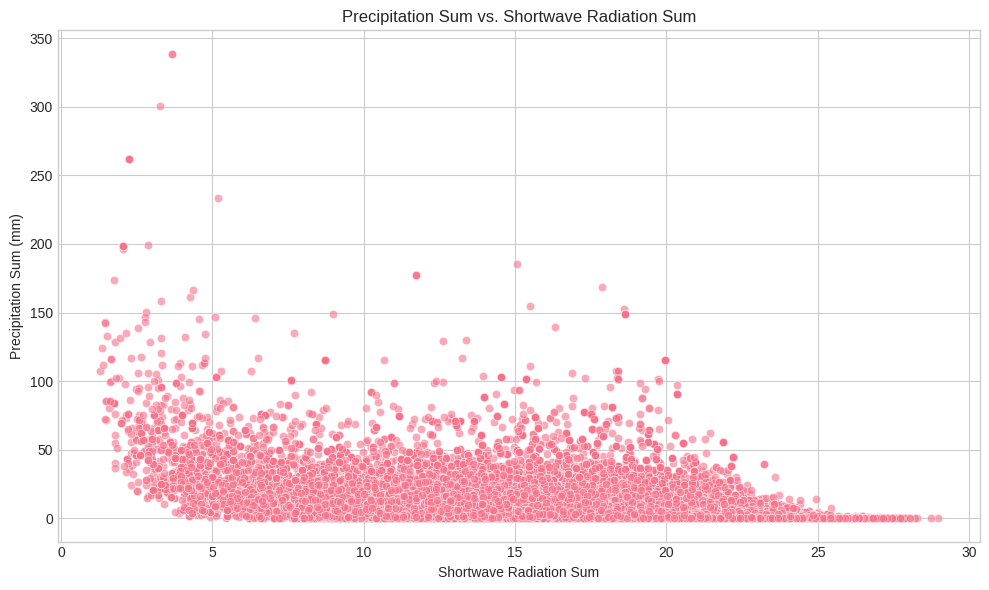

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df['shortwave_radiation_sum'], y=train_df['precipitation_sum'], alpha=0.6)
plt.title('Precipitation Sum vs. Shortwave Radiation Sum')
plt.xlabel('Shortwave Radiation Sum')
plt.ylabel('Precipitation Sum (mm)')
plt.grid(True)
plt.tight_layout()
plt.show()

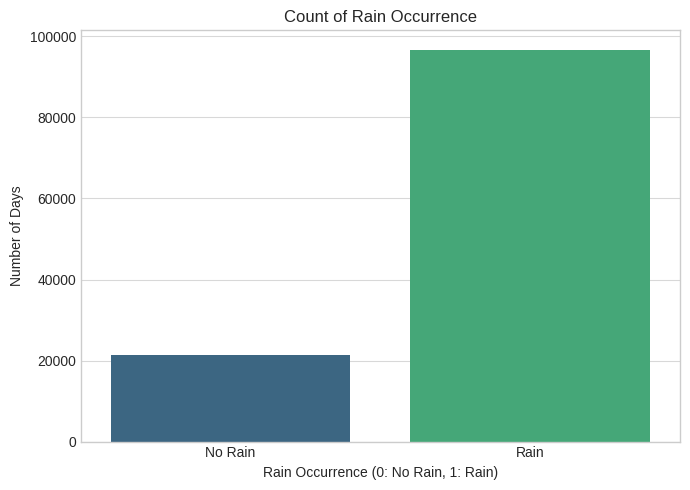

In [ ]:
rain_counts = train_df['rain_occurrence'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
sns.barplot(x=rain_counts.index, y=rain_counts.values, palette='viridis')
plt.title('Count of Rain Occurrence')
plt.xlabel('Rain Occurrence (0: No Rain, 1: Rain)')
plt.ylabel('Number of Days')
plt.xticks([0, 1], ['No Rain', 'Rain'])
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

=== One-Way ANOVA Results ===
F-Statistic: 1755.4184
P-Value: 0.0000e+00

Significant difference found. Running Tukey's HSD...
           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------
1st Inter-monsoon 2nd Inter-monsoon   6.1124    0.0  5.8546  6.3702   True
1st Inter-monsoon        NE Monsoon  -0.0722 0.8562 -0.3052  0.1608  False
1st Inter-monsoon        SW Monsoon   1.7303    0.0   1.517  1.9436   True
2nd Inter-monsoon        NE Monsoon  -6.1846    0.0 -6.4225 -5.9467   True
2nd Inter-monsoon        SW Monsoon  -4.3821    0.0 -4.6008 -4.1635   True
       NE Monsoon        SW Monsoon   1.8025    0.0  1.6137  1.9913   True
--------------------------------------------------------------------------


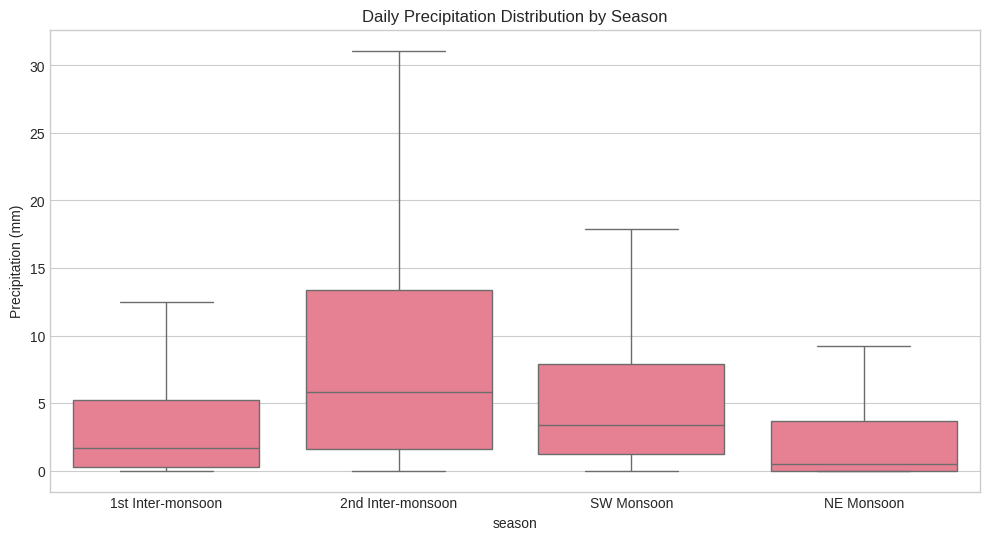

In [ ]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd


def get_season(month):
    if month in [3, 4]:
        return '1st Inter-monsoon'
    elif month in [5, 6, 7, 8, 9]:
        return 'SW Monsoon'
    elif month in [10, 11]:
        return '2nd Inter-monsoon'
    else: # Dec, Jan, Feb
        return 'NE Monsoon'

train_df['season'] = train_df['time'].dt.month.apply(get_season)

groups = [train_df[train_df['season'] == s]['precipitation_sum'] for s in train_df['season'].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print("=== One-Way ANOVA Results ===")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4e}")

if p_value < 0.05:
    print("\nSignificant difference found. Running Tukey's HSD...")
    tukey = pairwise_tukeyhsd(endog=train_df['precipitation_sum'],
                              groups=train_df['season'],
                              alpha=0.05)
    print(tukey)

plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='precipitation_sum', data=train_df, showfliers=False)
plt.title('Daily Precipitation Distribution by Season')
plt.ylabel('Precipitation (mm)')
plt.show()

In [16]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['precipitation_sum'].dropna())

adf_statistic = result[0]
p_value = result[1]
critical_values = result[4]

print("=== Augmented Dickey-Fuller Test Results ===")
print(f"ADF Statistic: {adf_statistic:.4f}")
print(f"P-Value: {p_value:.4e}")
print("Critical Values:")
for key, value in critical_values.items():
    print(f"   {key}: {value:.4f}")

if p_value < 0.05:
    print("\nResult: STATIONARY (Reject H0)")
    print("The rainfall data does not have a trend. The mean and variance are constant over time.")
else:
    print("\nResult: NON-STATIONARY (Fail to Reject H0)")
    print("The data has a trend or seasonality. You might need to 'difference' the data.")

=== Augmented Dickey-Fuller Test Results ===
ADF Statistic: -37.8052
P-Value: 0.0000e+00
Critical Values:
   1%: -3.4304
   5%: -2.8616
   10%: -2.5668

Result: STATIONARY (Reject H0)
The rainfall data does not have a trend. The mean and variance are constant over time.


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

#Create Lags
df = df.sort_values(by=['city', 'time'])
df['rain_lag_1'] = df.groupby('city')['precipitation_sum'].shift(1)
df['rain_lag_2'] = df.groupby('city')['precipitation_sum'].shift(2)
df['rain_lag_3'] = df.groupby('city')['precipitation_sum'].shift(3)

features = [
    'rain_lag_1', 'rain_lag_2', 'rain_lag_3',
    'apparent_temperature_mean',
    'windspeed_10m_max',
    'winddirection_10m_dominant',
    'shortwave_radiation_sum',
    'latitude',
    'longitude',
    'elevation'
]

df_model = df.dropna(subset=features + ['rain_occurrence']).copy()

X = df_model[features]
y = df_model['rain_occurrence']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Final Optimized Feature Importance (with Apparent Temp Mean):")
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
print(importance)

print("\nModel Performance Metrics:")
print(classification_report(y_test, model.predict(X_test_scaled)))

Final Optimized Feature Importance (with Apparent Temp Mean):
                      Feature  Coefficient
0                  rain_lag_1     1.489183
3   apparent_temperature_mean     1.422414
5  winddirection_10m_dominant     0.606034
4           windspeed_10m_max     0.208492
2                  rain_lag_3     0.191533
9                   elevation     0.081932
1                  rain_lag_2     0.043690
8                   longitude    -0.233094
7                    latitude    -0.238912
6     shortwave_radiation_sum    -2.285463

Model Performance Metrics:
              precision    recall  f1-score   support

           0       0.50      0.85      0.63      5338
           1       0.96      0.81      0.88     24140

    accuracy                           0.82     29478
   macro avg       0.73      0.83      0.75     29478
weighted avg       0.88      0.82      0.83     29478



In [18]:
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

importance['Odds_Ratio'] = np.exp(importance['Coefficient'])

importance['Abs_Coefficient'] = importance['Coefficient'].abs()
importance = importance.sort_values(by='Abs_Coefficient', ascending=False)

print(importance.drop(columns=['Abs_Coefficient']))

                      Feature  Coefficient  Odds_Ratio
6     shortwave_radiation_sum    -2.285463    0.101727
0                  rain_lag_1     1.489183    4.433472
3   apparent_temperature_mean     1.422414    4.147121
5  winddirection_10m_dominant     0.606034    1.833146
7                    latitude    -0.238912    0.787484
8                   longitude    -0.233094    0.792079
4           windspeed_10m_max     0.208492    1.231819
2                  rain_lag_3     0.191533    1.211105
9                   elevation     0.081932    1.085382
1                  rain_lag_2     0.043690    1.044659


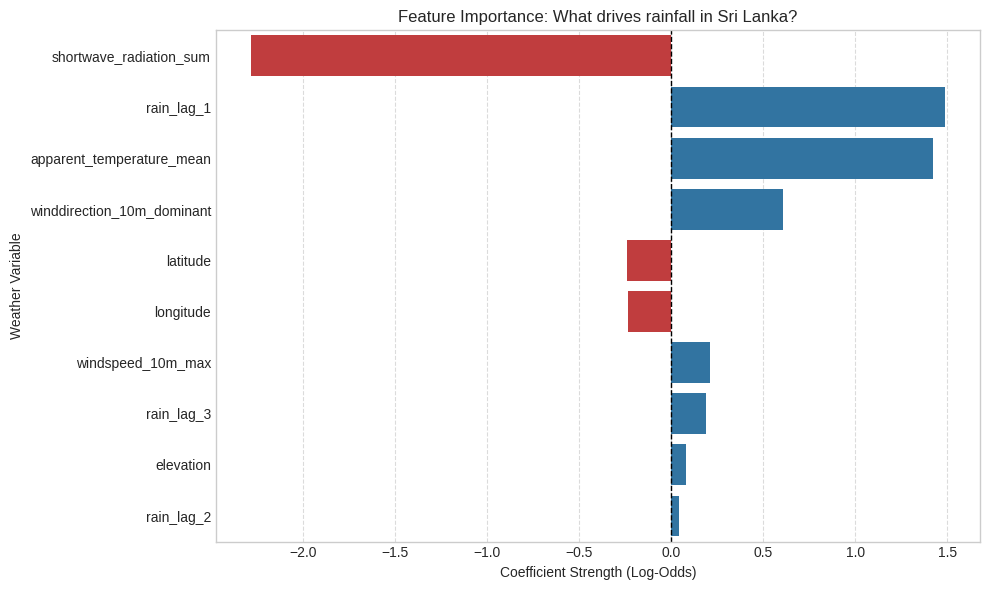

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

colors = ['#1f77b4' if x > 0 else '#d62728' for x in importance['Coefficient']]

sns.barplot(x='Coefficient', y='Feature', data=importance, hue='Feature', palette=colors, legend=False)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Feature Importance: What drives rainfall in Sri Lanka?')
plt.xlabel('Coefficient Strength (Log-Odds)')
plt.ylabel('Weather Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Objective 2: Modeling Apparent Temperature and Thermal Comfort  

In [20]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import scipy.stats as stats

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [21]:
df.duplicated().any()

np.False_

In [22]:
# train and test data split
train_df_apt,test_df_apt = train_test_split(df, test_size=0.2, random_state=42, stratify=df['city'])
print(f"Training DataFrame shape: {train_df_apt.shape}")
print(f"Testing DataFrame shape: {test_df_apt.shape}")

Training DataFrame shape: (117984, 22)
Testing DataFrame shape: (29496, 22)


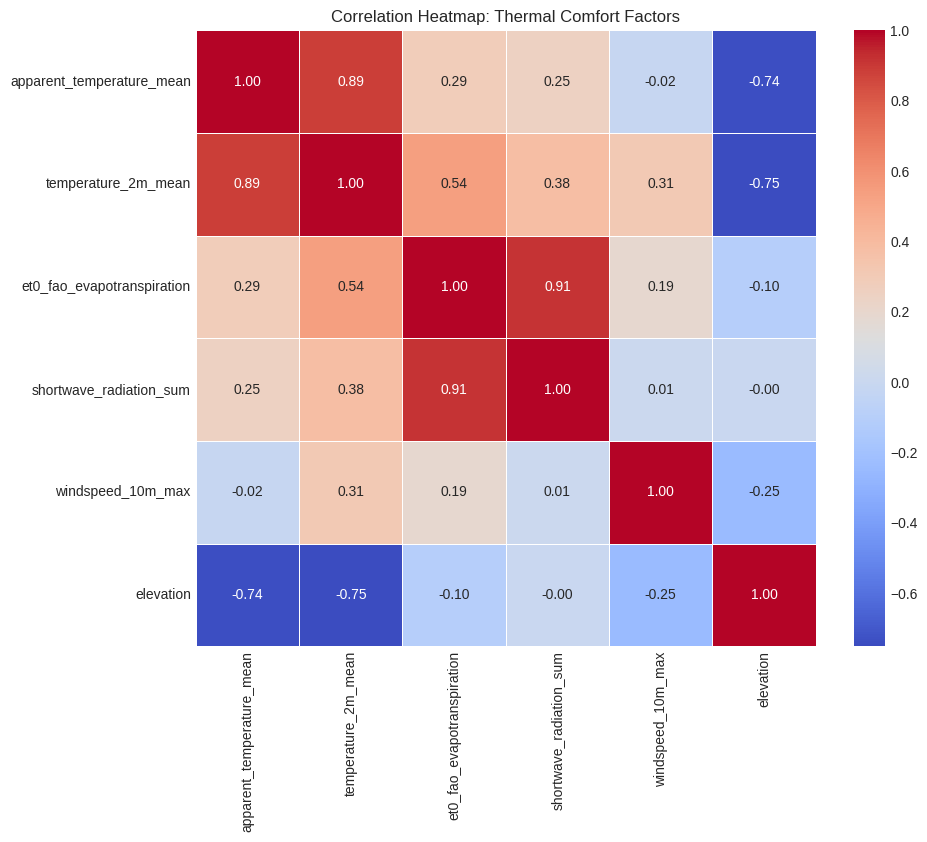

In [23]:
# Correlation heatmap of the apparent temparature and its associated variables.
cols_for_corr = [
    'apparent_temperature_mean', 'temperature_2m_mean',
    'et0_fao_evapotranspiration', 'shortwave_radiation_sum',
    'windspeed_10m_max', 'elevation'
]

corr_matrix = train_df_apt[cols_for_corr].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Thermal Comfort Factors')
plt.show()

In [24]:
# grouping mean temparature and mean temparature of each city
city_stats=train_df_apt.groupby('city')[['temperature_2m_mean','apparent_temperature_mean']].mean().reset_index()
city_stats['temp_diff'] = city_stats['apparent_temperature_mean'] - city_stats['temperature_2m_mean']
city_stats=city_stats.sort_values(by='temp_diff',ascending=False)
city_stats

,city,temperature_2m_mean,apparent_temperature_mean,temp_diff
2,Bentota,26.487872,31.272235,4.784363
10,Kalutara,26.519736,31.275331,4.755595
22,Negombo,26.847877,31.582456,4.734579
3,Colombo,26.719603,31.451208,4.731604
26,Ratnapura,25.147140,29.866565,4.719425
20,Moratuwa,26.646668,31.358800,4.712131
12,Kesbewa,26.605645,31.269870,4.664226
21,Mount Lavinia,26.688075,31.346784,4.658708
15,Mabole,26.714798,31.369438,4.654640
4,Galle,27.114722,31.748258,4.633537


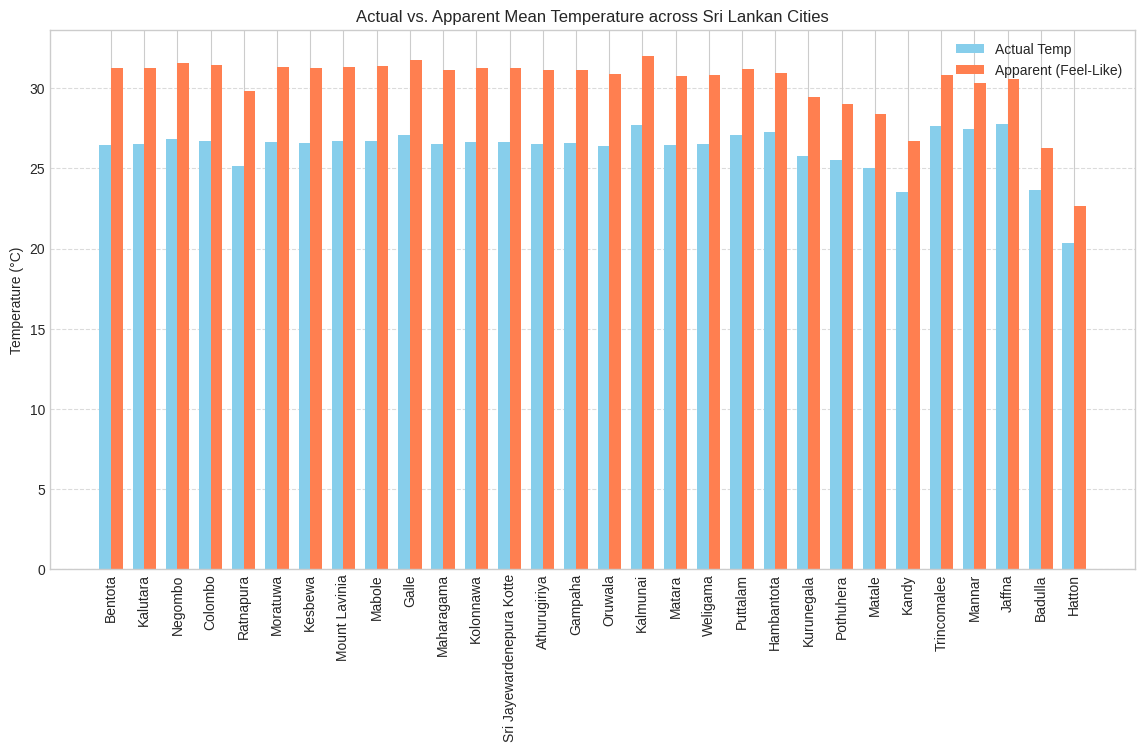

In [25]:
# plotting mean of actual and aparent temp. of each city
plt.figure(figsize=(14, 7))
x = range(len(city_stats))
width = 0.35

plt.bar([i - width/2 for i in x], city_stats['temperature_2m_mean'], width, label='Actual Temp', color='skyblue')
plt.bar([i + width/2 for i in x], city_stats['apparent_temperature_mean'], width, label='Apparent (Feel-Like)', color='coral')

plt.xticks(x, city_stats['city'], rotation=90)
plt.ylabel('Temperature (°C)')
plt.title('Actual vs. Apparent Mean Temperature across Sri Lankan Cities')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

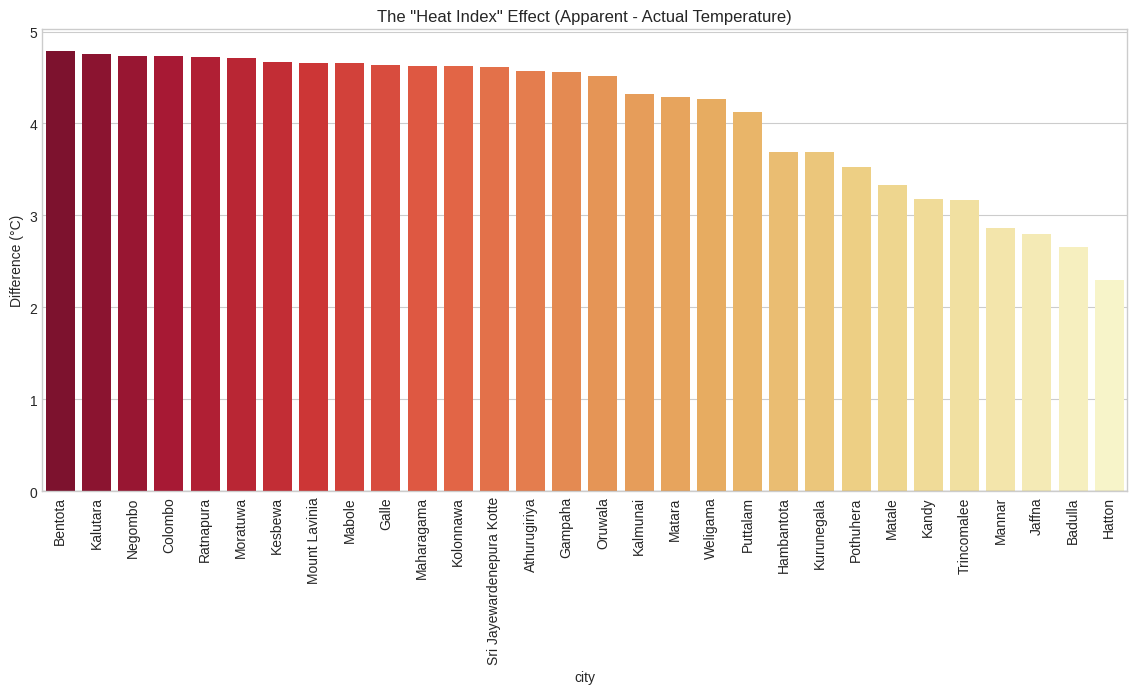

In [26]:
#plotting temp. difference of each city

plt.figure(figsize=(14, 6))
sns.barplot(x='city', y='temp_diff', data=city_stats, palette='YlOrRd_r')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('The "Heat Index" Effect (Apparent - Actual Temperature)')
plt.ylabel('Difference (°C)')
plt.xticks(rotation=90)
plt.show()

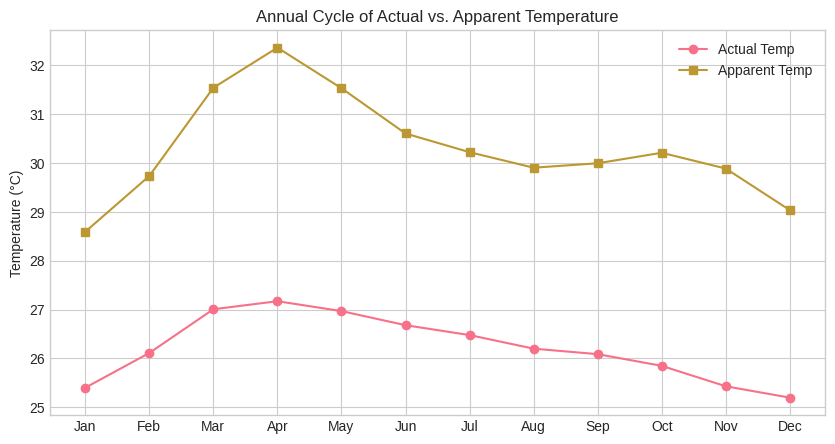

In [27]:
## annual cycle of actual and aparent temp.
train_df_apt['month'] = train_df_apt['time'].dt.month
monthly_cycle = train_df_apt.groupby('month')[['temperature_2m_mean', 'apparent_temperature_mean']].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_cycle.index, monthly_cycle['temperature_2m_mean'], marker='o', label='Actual Temp')
plt.plot(monthly_cycle.index, monthly_cycle['apparent_temperature_mean'], marker='s', label='Apparent Temp')
plt.title('Annual Cycle of Actual vs. Apparent Temperature')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

In [28]:
#elevation of each city
city_elevation_list = train_df[['city', 'elevation']].drop_duplicates().sort_values(by='elevation', ascending=True)
city_elevation_list = city_elevation_list.reset_index(drop=True)
print(city_elevation_list)

                         city  elevation
0                    Kalutara          0
1                    Puttalam          0
2                      Jaffna          5
3                    Weligama          5
4                     Negombo          5
5                      Mannar          6
6   Sri Jayewardenepura Kotte          7
7                      Matara          7
8                 Trincomalee          7
9                    Kalmunai          8
10                   Moratuwa          9
11              Mount Lavinia         10
12                    Bentota         10
13                 Hambantota         12
14                  Kolonnawa         13
15                      Galle         15
16                    Gampaha         15
17                    Colombo         16
18                     Mabole         16
19                    Kesbewa         18
20                    Oruwala         20
21                 Maharagama         26
22                  Ratnapura         27
23              

In [29]:
# grouping cities accriding to their elevation(low,mid,high)
train_df_apt['temp_diff'] = train_df_apt['apparent_temperature_mean'] - train_df_apt['temperature_2m_mean']

def get_elevation_level(elev):
    if elev < 300:
        return 'Low'
    elif elev < 900:
        return 'Mid'
    else:
        return 'High'

train_df_apt['elevation_level'] = train_df_apt['elevation'].apply(get_elevation_level)

print("Data distribution by Elevation Level:")
print(train_df_apt['elevation_level'].value_counts())

train_df_apt[['city', 'elevation', 'elevation_level', 'temp_diff']].head()

Data distribution by Elevation Level:
elevation_level
Low     102253
Mid      11799
High      3932
Name: count, dtype: int64


,city,elevation,elevation_level,temp_diff
60164,Jaffna,5,Low,3.1
39780,Sri Jayewardenepura Kotte,7,Low,5.6
693,Colombo,16,Low,3.4
9072,Mount Lavinia,10,Low,5.6
40469,Sri Jayewardenepura Kotte,7,Low,5.1


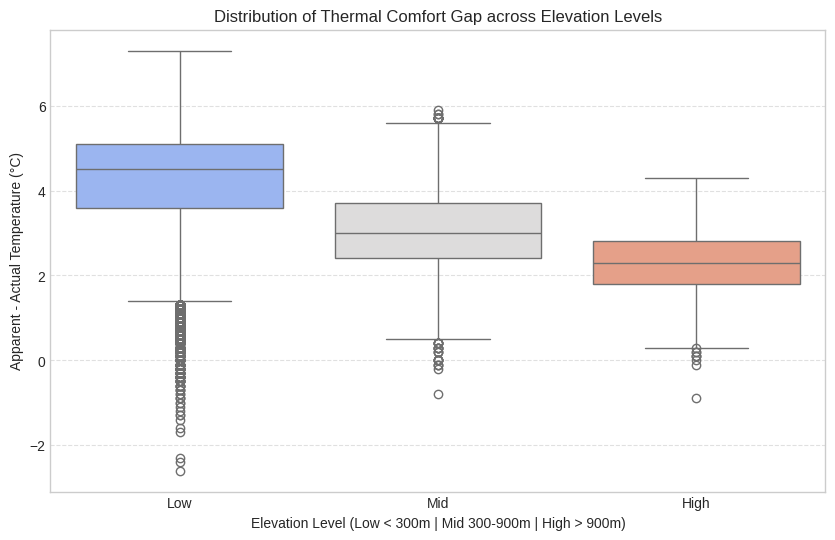

In [30]:
# temp. difference distributiin of each elevation level
plt.figure(figsize=(10, 6))

sns.boxplot(x='elevation_level', y='temp_diff', data=train_df_apt,
            order=['Low', 'Mid', 'High'], palette='coolwarm')

plt.title('Distribution of Thermal Comfort Gap across Elevation Levels')
plt.xlabel('Elevation Level (Low < 300m | Mid 300-900m | High > 900m)')
plt.ylabel('Apparent - Actual Temperature (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

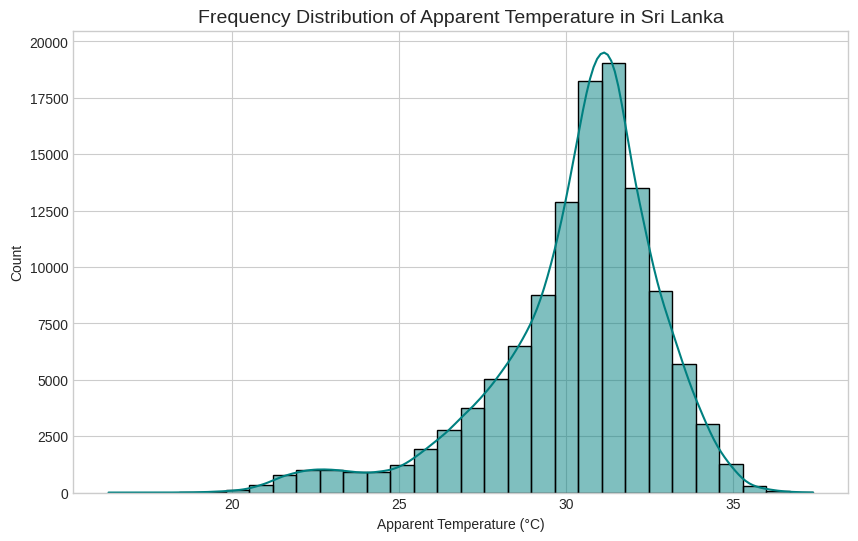

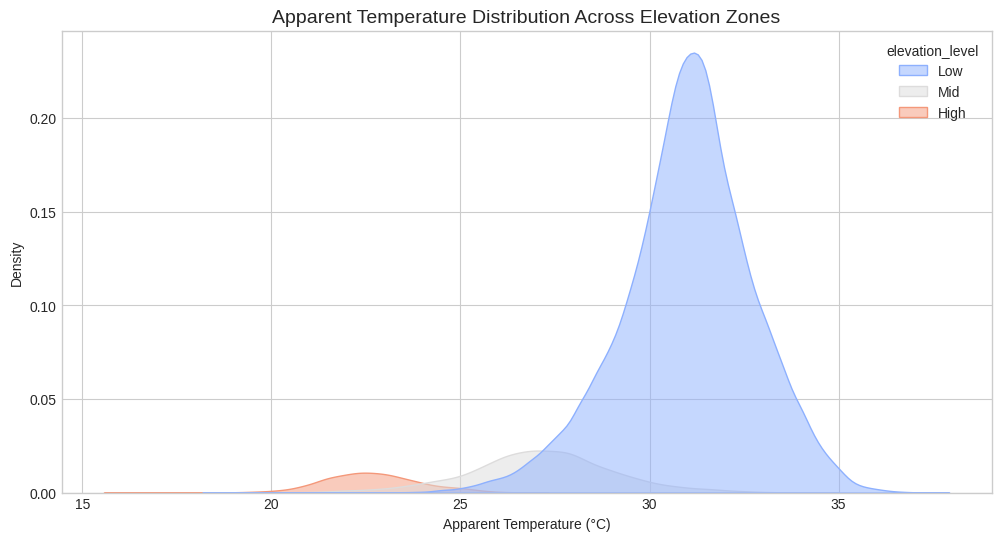

In [31]:
# distribution of aparent temp.
plt.figure(figsize=(10, 6))
sns.histplot(train_df_apt['apparent_temperature_mean'], kde=True, color='teal', bins=30)
plt.title('Frequency Distribution of Apparent Temperature in Sri Lanka', fontsize=14)
plt.xlabel('Apparent Temperature (°C)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(12, 6))
sns.kdeplot(data=train_df_apt, x='apparent_temperature_mean', hue='elevation_level',
            hue_order=['Low', 'Mid', 'High'], fill=True, palette='coolwarm', alpha=0.5)
plt.title('Apparent Temperature Distribution Across Elevation Zones', fontsize=14)
plt.xlabel('Apparent Temperature (°C)')
plt.ylabel('Density')
plt.show()

In [32]:
## performing one way anova

low_group = train_df_apt[train_df_apt['elevation_level'] == 'Low']['temp_diff']
mid_group = train_df_apt[train_df_apt['elevation_level'] == 'Mid']['temp_diff']
high_group = train_df_apt[train_df_apt['elevation_level'] == 'High']['temp_diff']

f_stat, p_val = stats.f_oneway(low_group, mid_group, high_group)

print(f"--- ANOVA Results ---")
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_val:.4e}")

alpha = 0.05
if p_val < alpha:
    print("\nResult: Reject the Null Hypothesis.")
    print("Conclusion: Elevation significantly impacts the difference between Actual and Apparent temperature.")
else:
    print("\nResult: Fail to reject the Null Hypothesis.")
    print("Conclusion: No statistically significant difference was found.")

--- ANOVA Results ---
F-Statistic: 11263.69
P-Value: 0.0000e+00

Result: Reject the Null Hypothesis.
Conclusion: Elevation significantly impacts the difference between Actual and Apparent temperature.


In [33]:
# Perform Tukey HSD test
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=train_df_apt['temp_diff'], groups=train_df_apt['elevation_level'], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower   upper  reject
--------------------------------------------------
  High    Low   1.9863   0.0 1.9431  2.0295   True
  High    Mid   0.7621   0.0 0.7131  0.8111   True
   Low    Mid  -1.2242   0.0  -1.25 -1.1983   True
--------------------------------------------------


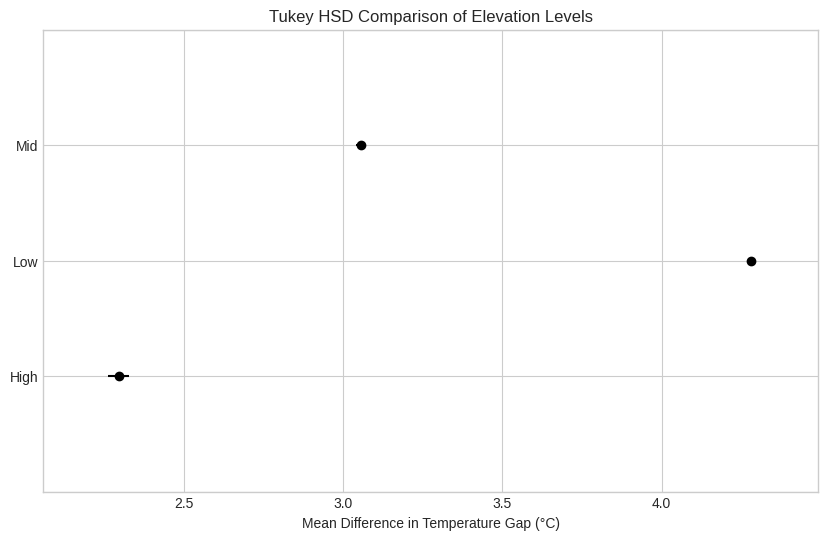

In [34]:
# Plotting tukey results
tukey.plot_simultaneous()
plt.vlines(x=0, ymin=-0.5, ymax=2.5, color='red', linestyle='--')
plt.title('Tukey HSD Comparison of Elevation Levels')
plt.xlabel('Mean Difference in Temperature Gap (°C)')
plt.show()

In [35]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

features = [
    'temperature_2m_mean',
    'windspeed_10m_max',
    'shortwave_radiation_sum',
    'et0_fao_evapotranspiration',
    'elevation'
]

X = train_df_apt[features]
X_with_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(len(X_with_const.columns))]

print(vif_data[vif_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False))

                      Feature        VIF
4  et0_fao_evapotranspiration  10.299464
3     shortwave_radiation_sum   7.802685
1         temperature_2m_mean   4.816536
5                   elevation   3.283808
2           windspeed_10m_max   1.263302


In [38]:
features_with_et0 = ['temperature_2m_mean', 'windspeed_10m_max', 'shortwave_radiation_sum', 'elevation', 'et0_fao_evapotranspiration']
features_without_et0 = ['temperature_2m_mean', 'windspeed_10m_max', 'shortwave_radiation_sum', 'elevation']

target = 'apparent_temperature_mean'

In [41]:
# Helper function to train and evaluate
def train_and_evaluate(feature_list, name):
    # Prepare data
    X_train_apt = train_df_apt[feature_list]
    y_train_apt = train_df_apt[target]
    X_test_apt = test_df_apt[feature_list]
    y_test_apt = test_df_apt[target]

    # Using Pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])
    pipe.fit(X_train_apt, y_train_apt)

    # Prediction and evaluate
    preds = pipe.predict(X_test_apt)
    return {
        "Model": name,
        "R2": metrics.r2_score(y_test_apt, preds),
        "RMSE": np.sqrt(metrics.mean_squared_error(y_test_apt, preds)),
        "Pipeline": pipe,
        "Predictions": preds
    }


# create 2 models.
results_et0 = train_and_evaluate(features_with_et0, "With ET0")
results_no_et0 = train_and_evaluate(features_without_et0, "Without ET0")

# this table compares two models
comparison_df = pd.DataFrame([results_et0, results_no_et0]).drop(columns=['Pipeline', 'Predictions'])
print(comparison_df)

         Model        R2      RMSE
0     With ET0  0.968600  0.447870
1  Without ET0  0.904654  0.780445


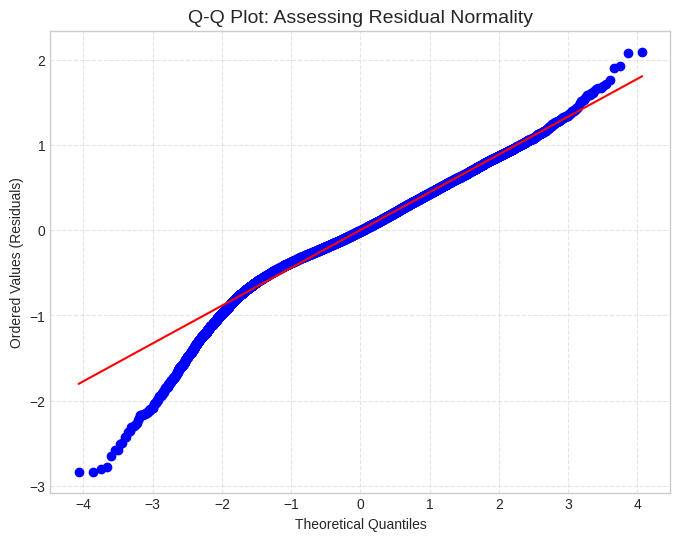

In [42]:
#Q-Q plot
X_test_apt = test_df_apt[features_with_et0]
y_test_apt = test_df_apt[target]
y_pred_apt = results_et0['Predictions']

residuals = y_test_apt - y_pred_apt
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot: Assessing Residual Normality', fontsize=14)
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values (Residuals)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

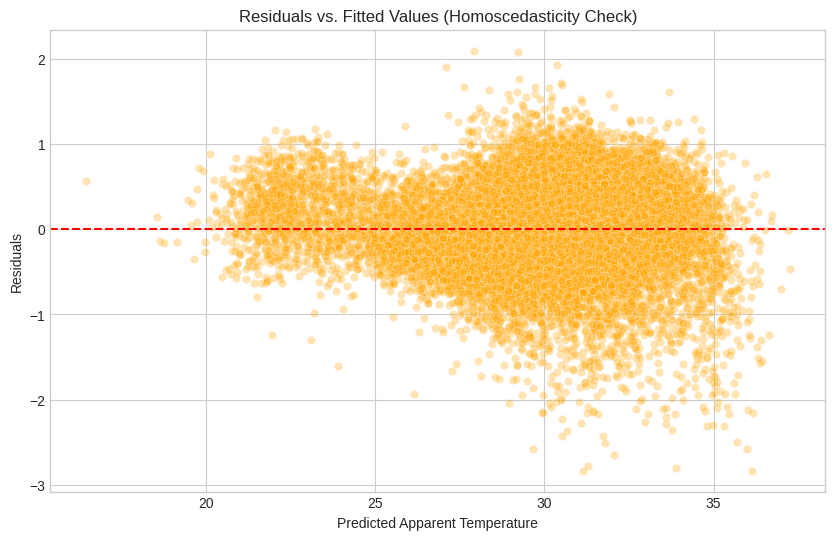

In [44]:
# Residual vs fitted values plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_apt, y=residuals, alpha=0.3, color='orange')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values (Homoscedasticity Check)')
plt.xlabel('Predicted Apparent Temperature')
plt.ylabel('Residuals')
plt.show()

## Random Forest Approach

In [45]:
rf_model_apt = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_apt.fit(train_df_apt[features_with_et0], train_df_apt[target])

rf_preds_apt = rf_model_apt.predict(test_df_apt[features_with_et0])
print(f"\nRandom Forest R2: {metrics.r2_score(y_test_apt, rf_preds_apt):.4f}")
print(f"Random Forest RMSE: {np.sqrt(metrics.mean_squared_error(y_test_apt, rf_preds_apt)):.4f} °C")


Random Forest R2: 0.9860
Random Forest RMSE: 0.2989 °C


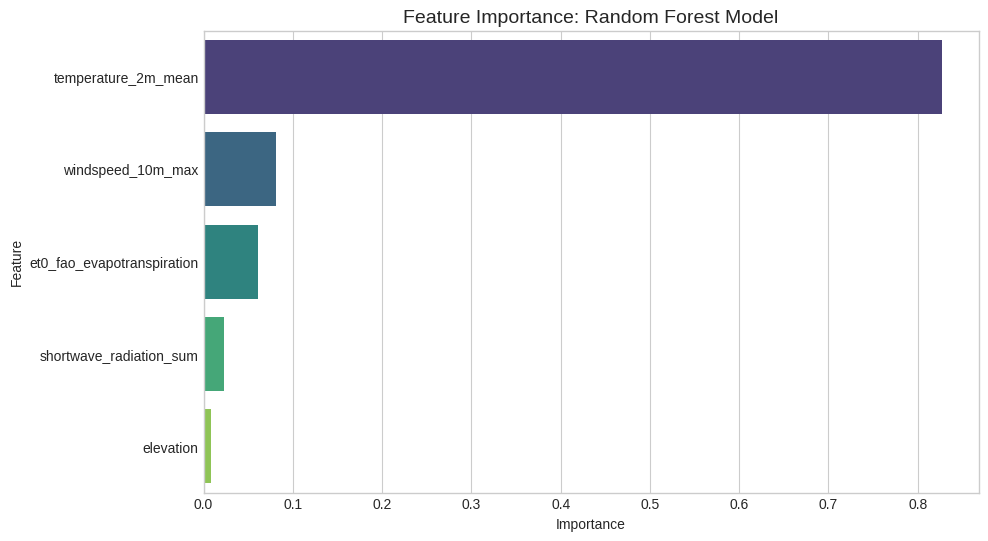

In [47]:
## plotting feature importance graph.
importances = rf_model_apt.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': features_with_et0,
    'Importance': importances
})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance: Random Forest Model', fontsize=14)
plt.show()

## Objective 3:Analyzing Wind Dynamics and Evapotranspiration

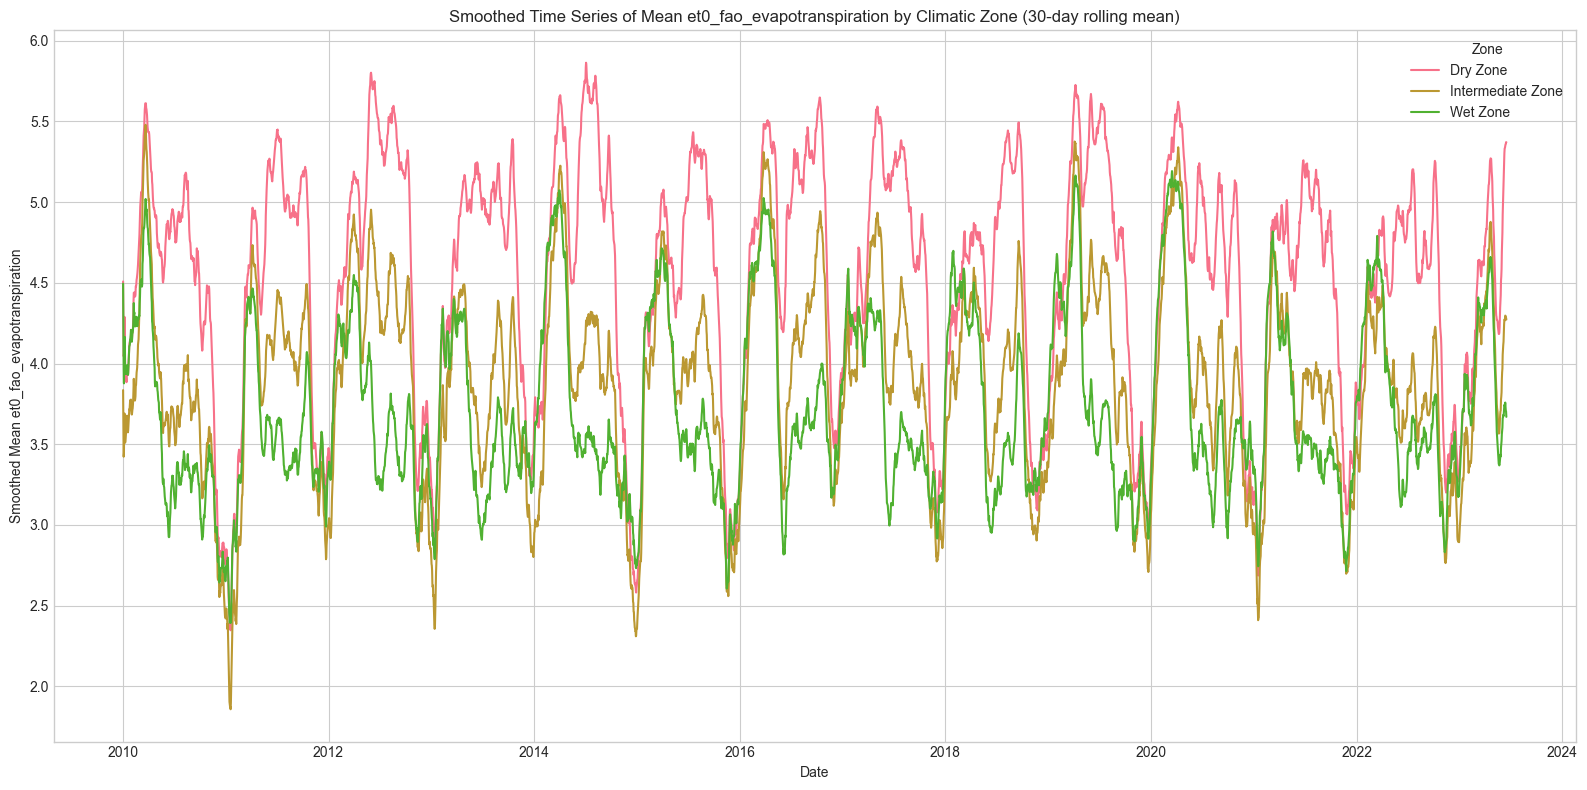

In [23]:
# Group by time and zone, then calculate the mean et0_fao_evapotranspiration
eva_by_zone = WEATHER.groupby(['time', 'zone'])['et0_fao_evapotranspiration'].mean().reset_index()

# Apply a rolling mean for smoothing within each zone
eva_by_zone_smoothed = eva_by_zone.groupby('zone')['et0_fao_evapotranspiration'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())
eva_by_zone['et0_fao_evapotranspiration_smoothed'] = eva_by_zone_smoothed

plt.figure(figsize=(16, 8))
sns.lineplot(data=eva_by_zone, x='time', y='et0_fao_evapotranspiration_smoothed', hue='zone')
plt.title('Smoothed Time Series of Mean et0_fao_evapotranspiration by Climatic Zone (30-day rolling mean)')
plt.xlabel('Date')
plt.ylabel('Smoothed Mean et0_fao_evapotranspiration')
plt.grid(True)
plt.legend(title='Zone')
plt.tight_layout()
plt.show()

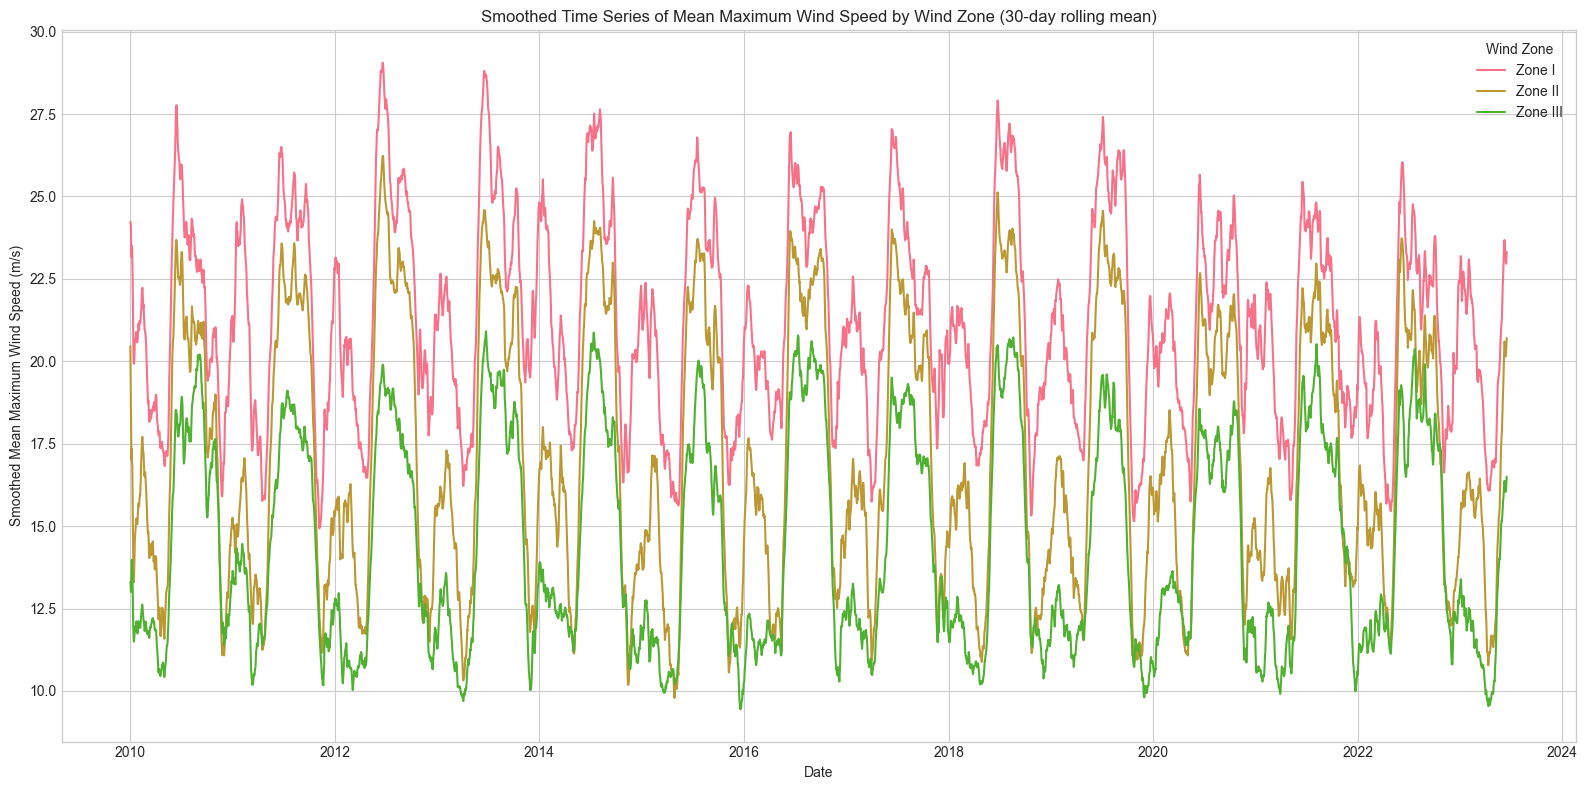

In [24]:
# Group by time and wind_zone, then calculate the mean windspeed_10m_max
wind_speed_by_zone_agg = WEATHER.groupby(['time', 'wind_zone'])['windspeed_10m_max'].mean().reset_index()

# Apply a rolling mean for smoothing within each wind zone

wind_speed_by_zone_agg['windspeed_10m_max_smoothed'] = wind_speed_by_zone_agg.groupby('wind_zone')['windspeed_10m_max'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())

plt.figure(figsize=(16, 8))
sns.lineplot(data=wind_speed_by_zone_agg, x='time', y='windspeed_10m_max_smoothed', hue='wind_zone')
plt.title('Smoothed Time Series of Mean Maximum Wind Speed by Wind Zone (30-day rolling mean)')
plt.xlabel('Date')
plt.ylabel('Smoothed Mean Maximum Wind Speed (m/s)')
plt.grid(True)
plt.legend(title='Wind Zone')
plt.tight_layout()
plt.show()

In [26]:
%pip install statsmodels

  Using cached statsmodels-0.14.6-cp312-cp312-macosx_11_0_arm64.whl.metadata (9.5 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp312-cp312-macosx_11_0_arm64.whl (10.0 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Decomposing Evaporation for Dry Zone...


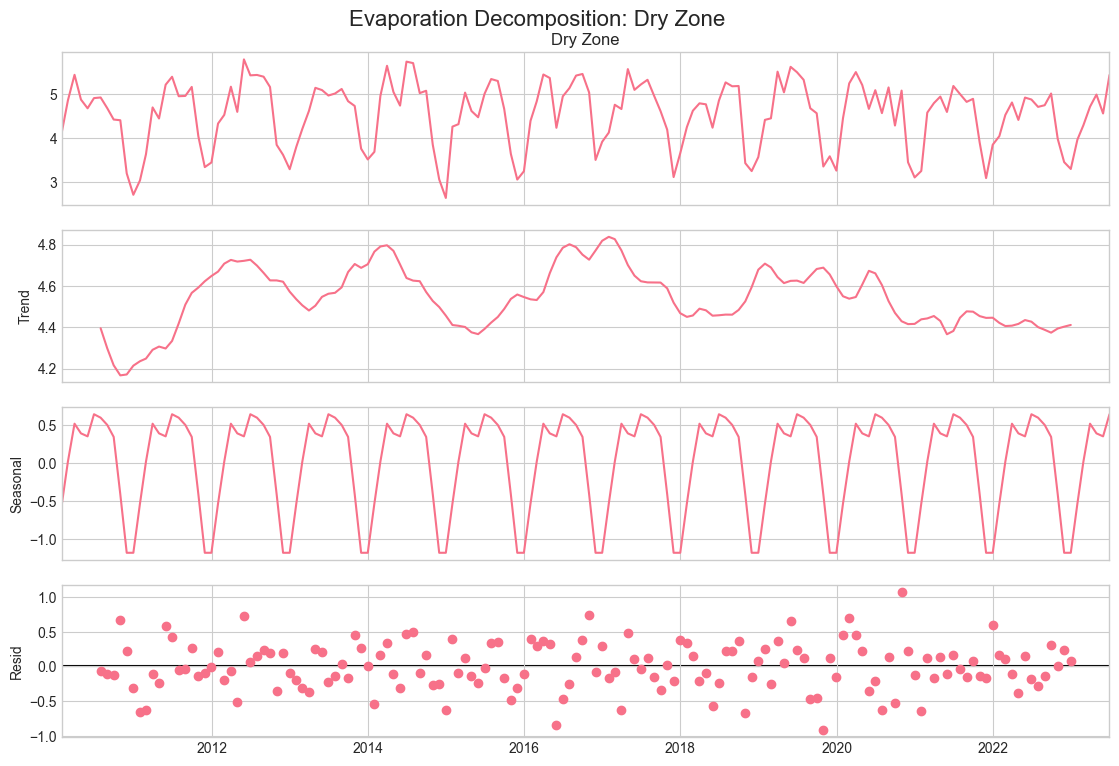

Decomposing Evaporation for Intermediate Zone...


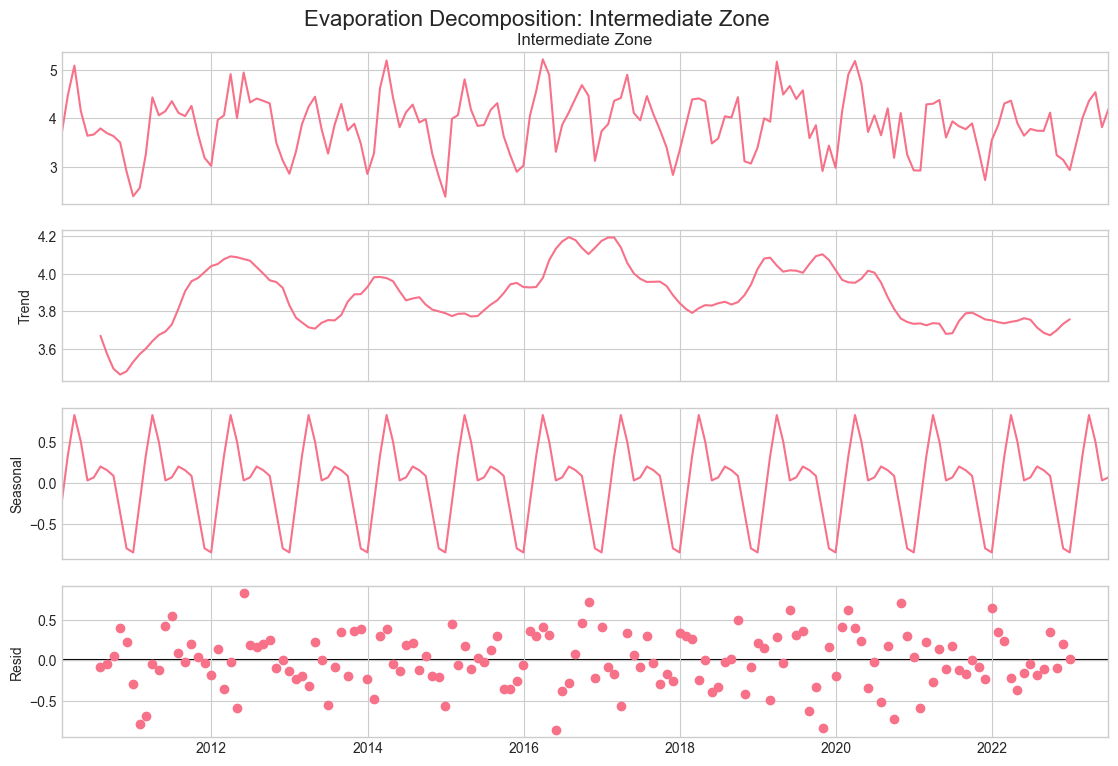

Decomposing Evaporation for Wet Zone...


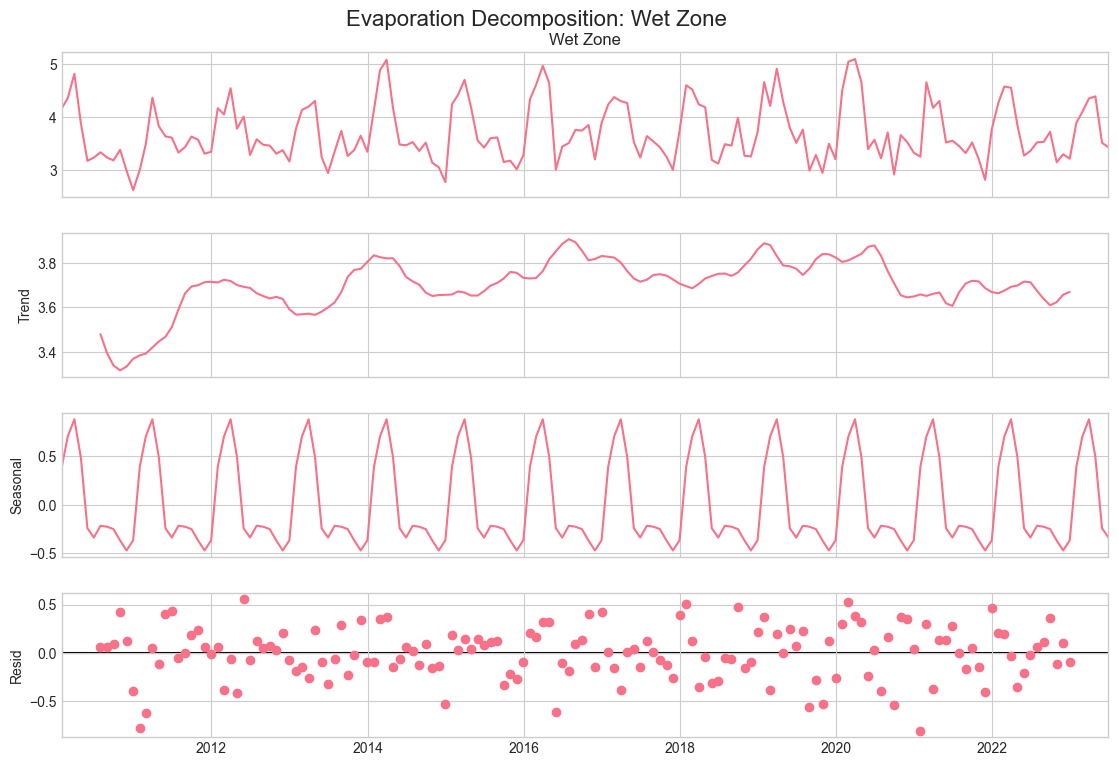

Decomposing Wind Speed for Zone I...


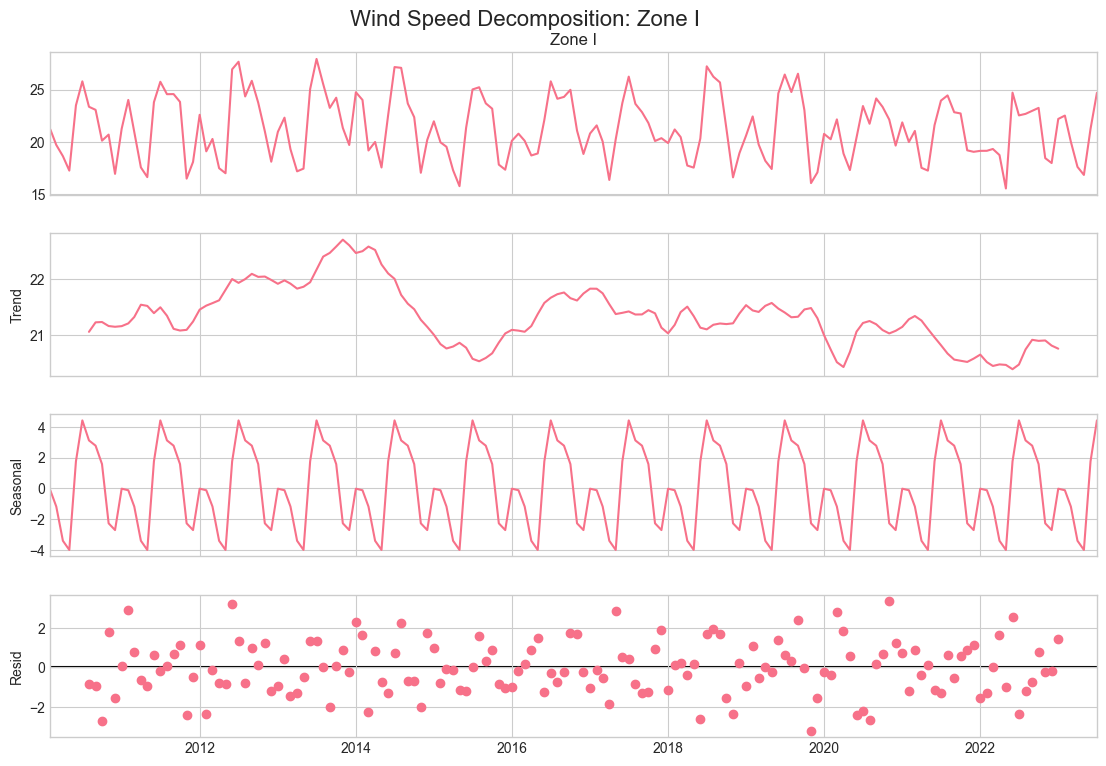

Decomposing Wind Speed for Zone II...


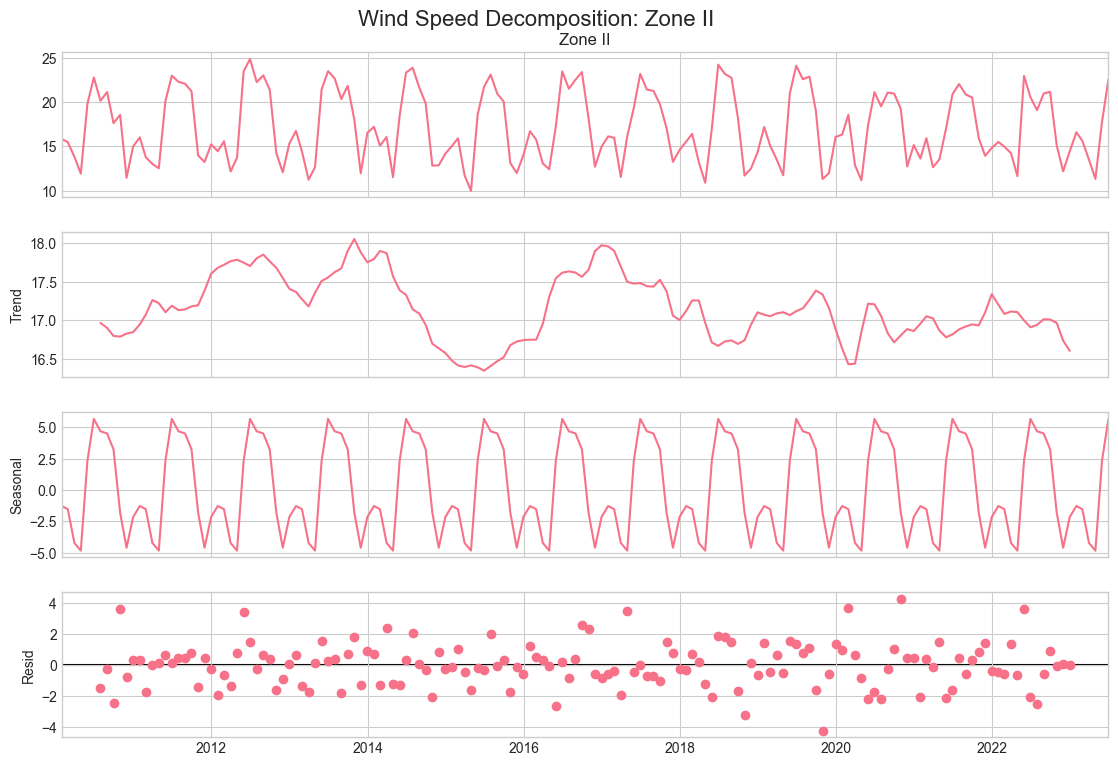

Decomposing Wind Speed for Zone III...


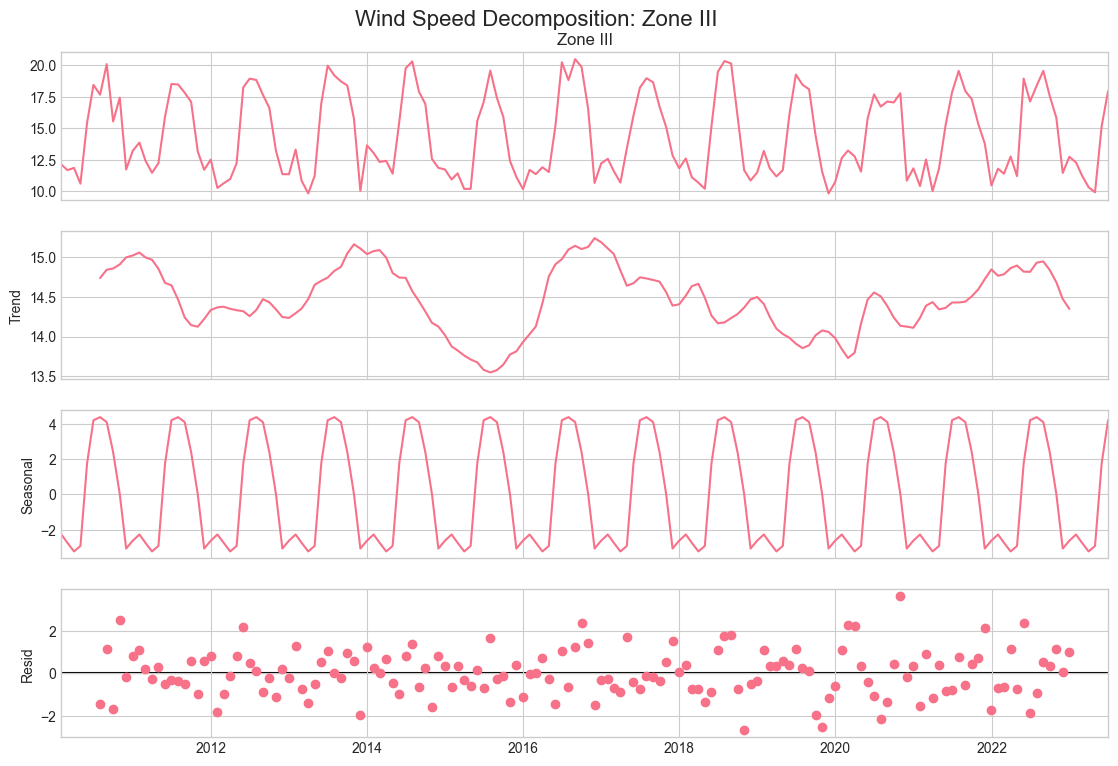

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose

evap_monthly = WEATHER.groupby([pd.Grouper(key='time', freq='ME'), 'zone'])['et0_fao_evapotranspiration'].mean().unstack()


wind_monthly = WEATHER.groupby([pd.Grouper(key='time', freq='ME'), 'wind_zone'])['windspeed_10m_max'].mean().unstack()

def plot_decomposition(data, title):

    for zone in data.columns:
        print(f"Decomposing {title} for {zone}...")

        res = seasonal_decompose(data[zone].dropna(), model='additive', period=12)
        fig = res.plot()
        fig.set_size_inches(12, 8)
        plt.suptitle(f'{title} Decomposition: {zone}', fontsize=16)
        plt.show()

plot_decomposition(evap_monthly, 'Evaporation')
plot_decomposition(wind_monthly, 'Wind Speed')

Decomposing Evaporation for Dry Zone...
Decomposing Evaporation for Intermediate Zone...
Decomposing Evaporation for Wet Zone...


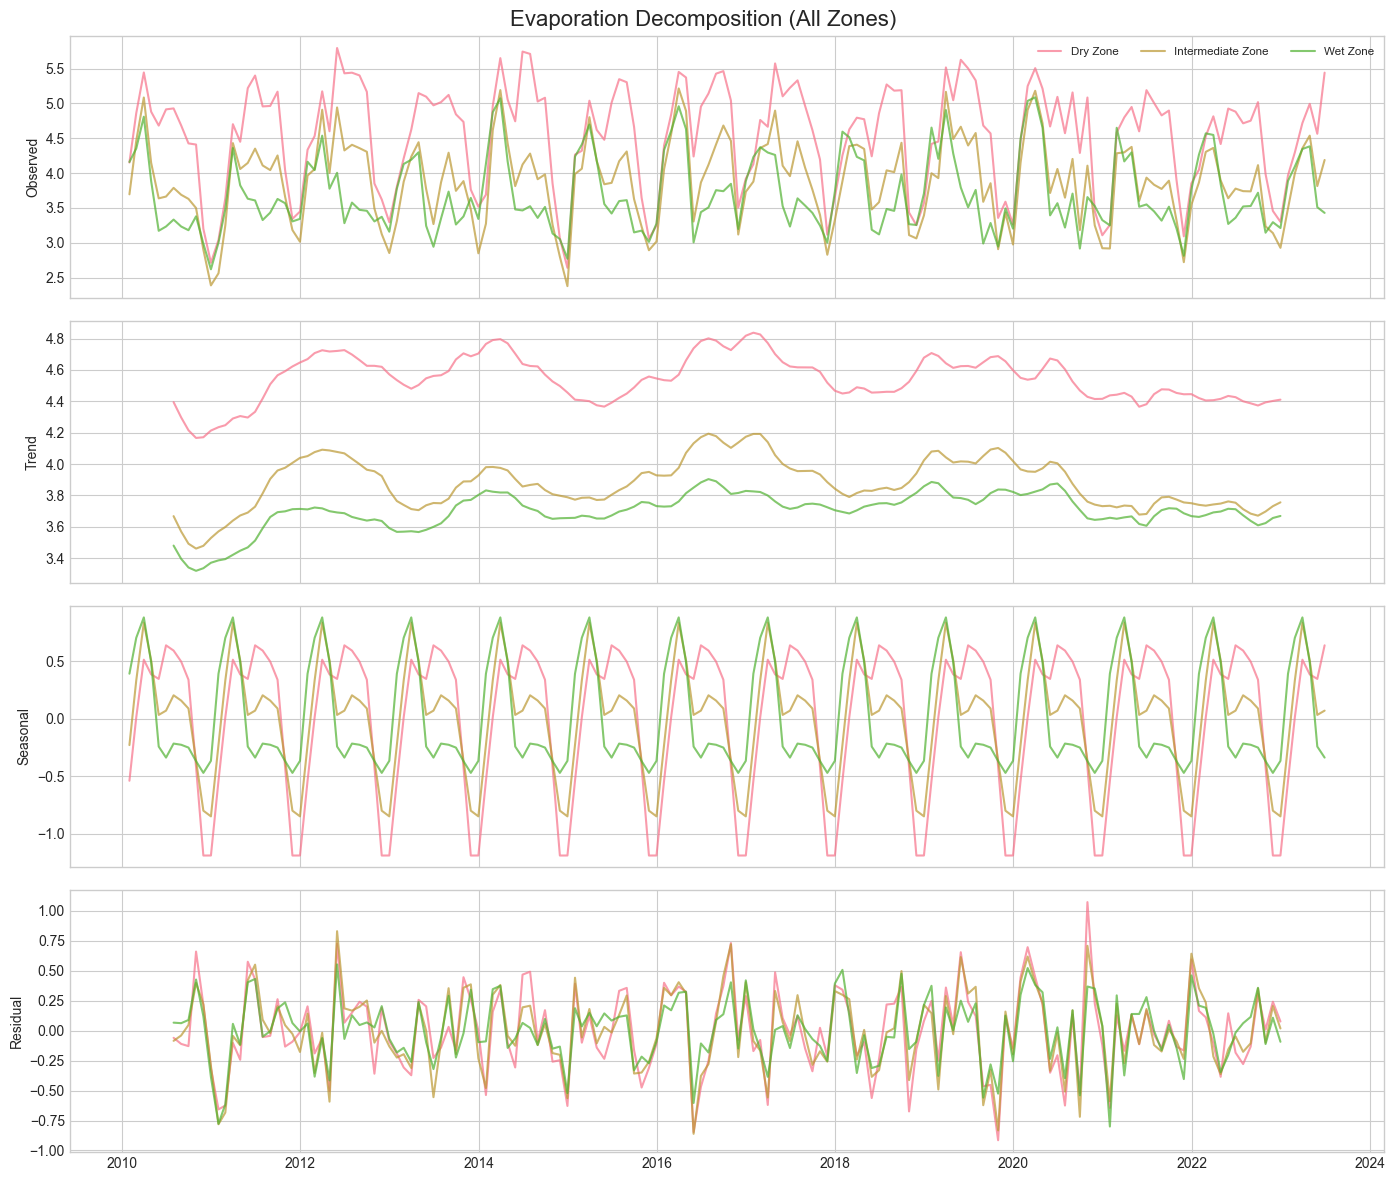

Decomposing Wind Speed for Zone I...
Decomposing Wind Speed for Zone II...
Decomposing Wind Speed for Zone III...


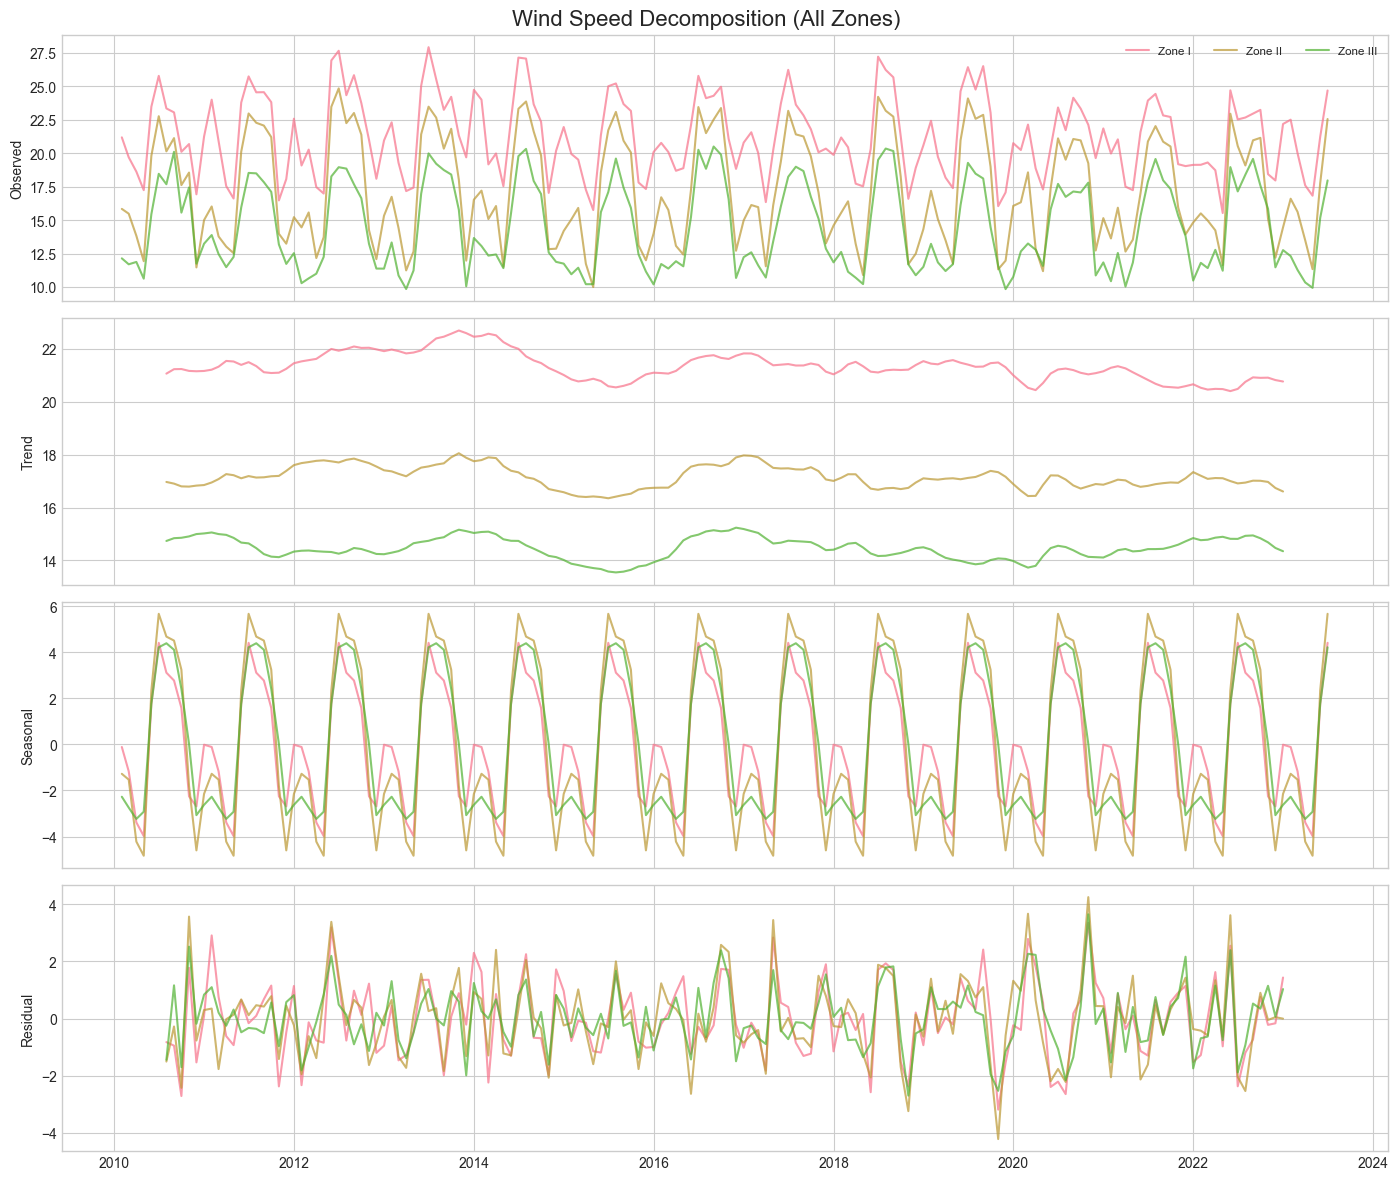

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import pandas as pd

evap_monthly = WEATHER.groupby([pd.Grouper(key='time', freq='ME'), 'zone'])['et0_fao_evapotranspiration'].mean().unstack()
wind_monthly = WEATHER.groupby([pd.Grouper(key='time', freq='ME'), 'wind_zone'])['windspeed_10m_max'].mean().unstack()

def plot_combined_decomposition(data, title):
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

    for zone in data.columns:
        print(f"Decomposing {title} for {zone}...")
        series = data[zone].dropna()
        if series.empty:
            continue

        res = seasonal_decompose(series, model='additive', period=12)

        axes[0].plot(res.observed, label=zone, alpha=0.7)
        axes[1].plot(res.trend, label=zone, alpha=0.7)
        axes[2].plot(res.seasonal, label=zone, alpha=0.7)
        axes[3].plot(res.resid, label=zone, alpha=0.7)

    axes[0].set_ylabel('Observed')
    axes[1].set_ylabel('Trend')
    axes[2].set_ylabel('Seasonal')
    axes[3].set_ylabel('Residual')

    axes[0].legend(loc='upper right', ncol=3, fontsize='small')

    plt.suptitle(f'{title} Decomposition (All Zones)', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_combined_decomposition(evap_monthly, 'Evaporation')
plot_combined_decomposition(wind_monthly, 'Wind Speed')

In [30]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings


warnings.filterwarnings("ignore")

evap_monthly = WEATHER.groupby([pd.Grouper(key='time', freq='ME'), 'zone'])['et0_fao_evapotranspiration'].mean().unstack()
wind_monthly = WEATHER.groupby([pd.Grouper(key='time', freq='ME'), 'wind_zone'])['windspeed_10m_max'].mean().unstack()


def run_tests(series, name):
    # ADF Test
    res_adf = adfuller(series.dropna())
    # KPSS Test
    res_kpss = kpss(series.dropna(), regression='c')

    return {
        'Variable': name,
        'ADF_p': round(res_adf[1], 4),
        'ADF_Stat': round(res_adf[0], 4),
        'ADF_Result': 'Stationary' if res_adf[1] < 0.05 else 'Non-Stationary',
        'KPSS_p': round(res_kpss[1], 4),
        'KPSS_Result': 'Stationary' if res_kpss[1] > 0.05 else 'Non-Stationary'
    }

results = []
for zone in evap_monthly.columns:
    results.append(run_tests(evap_monthly[zone], f"Evap - {zone}"))
for zone in wind_monthly.columns:
    results.append(run_tests(wind_monthly[zone], f"Wind - {zone}"))


results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                Variable  ADF_p  ADF_Stat     ADF_Result  KPSS_p KPSS_Result
         Evap - Dry Zone 0.0269   -3.0957     Stationary     0.1  Stationary
Evap - Intermediate Zone 0.0561   -2.8155 Non-Stationary     0.1  Stationary
         Evap - Wet Zone 0.0643   -2.7595 Non-Stationary     0.1  Stationary
           Wind - Zone I 0.2085   -2.1937 Non-Stationary     0.1  Stationary
          Wind - Zone II 0.0591   -2.7945 Non-Stationary     0.1  Stationary
         Wind - Zone III 0.0414   -2.9351     Stationary     0.1  Stationary


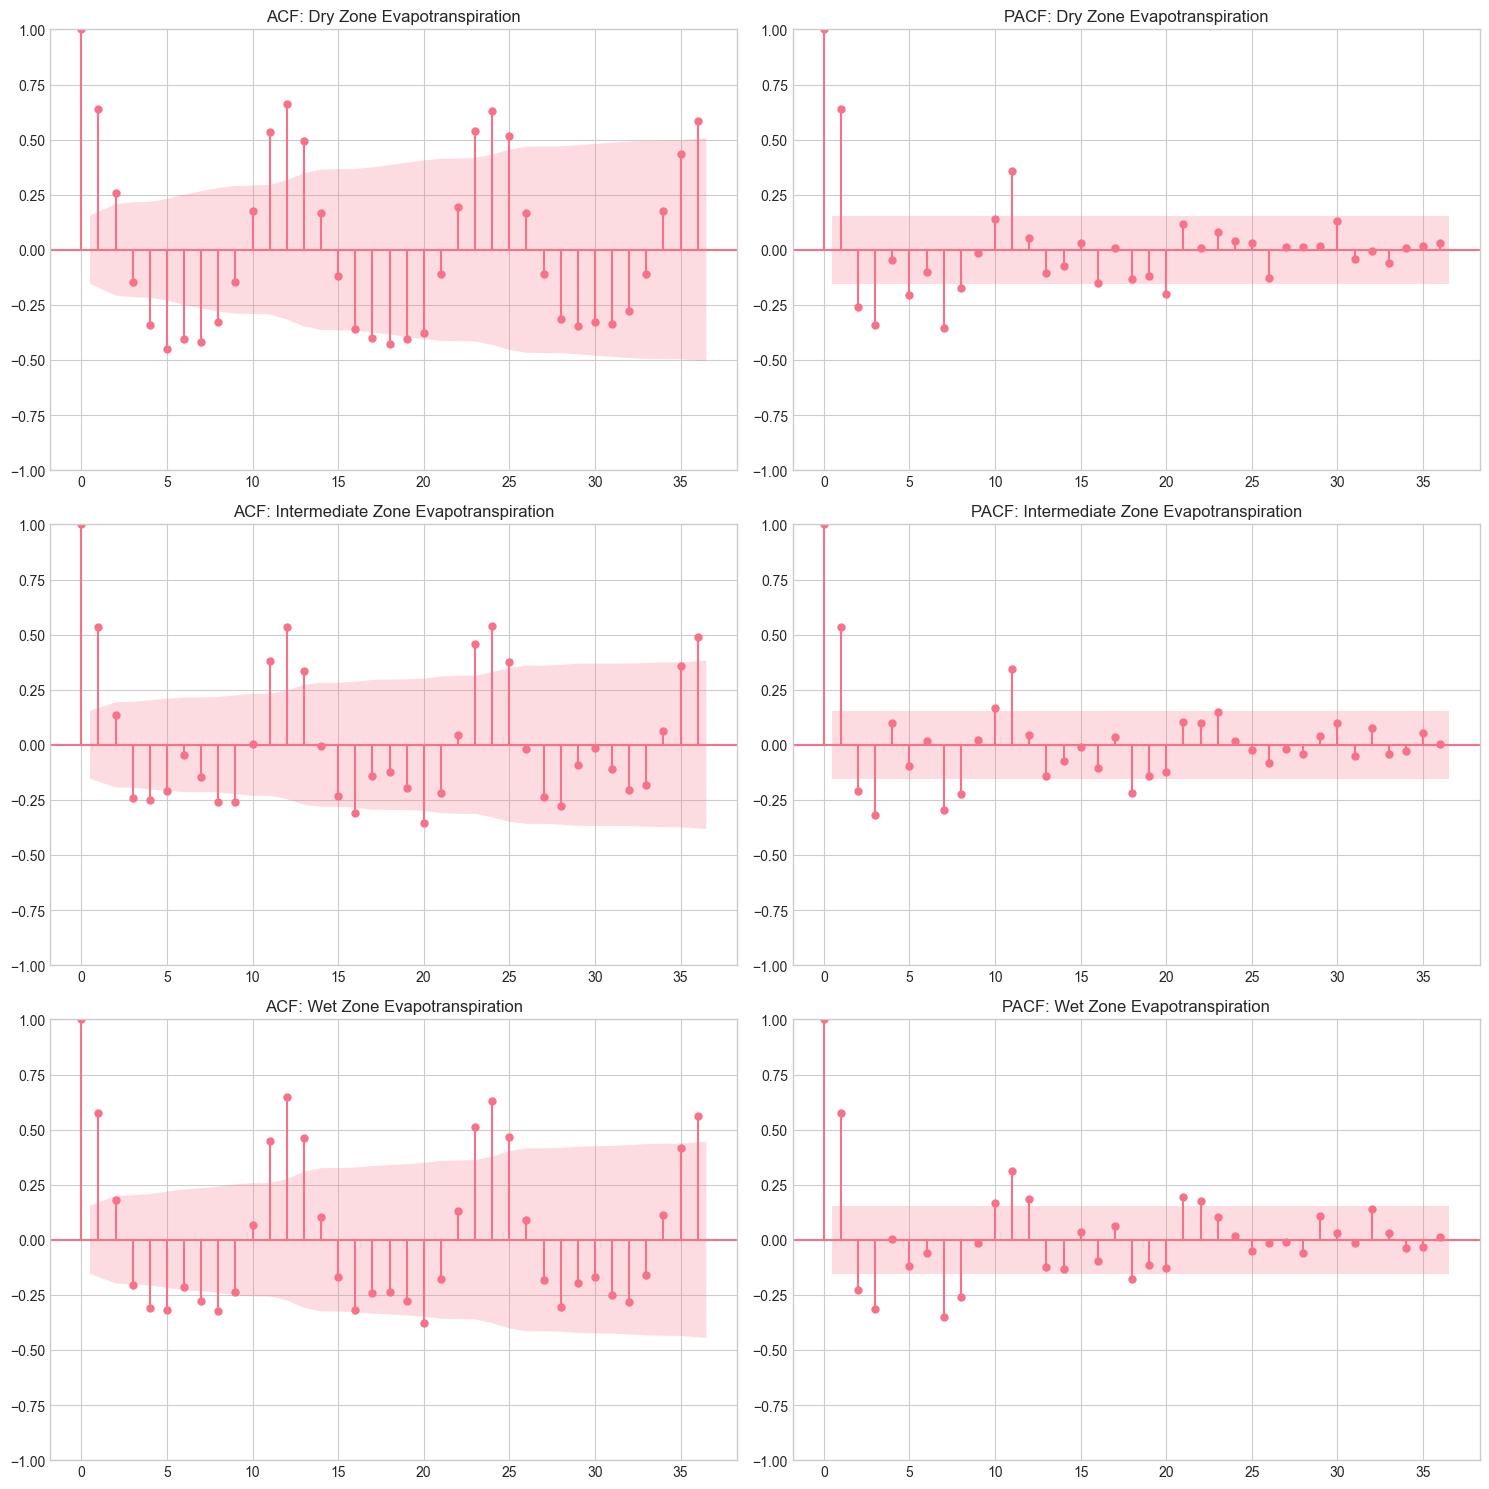

In [31]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Monthly Aggregation
evap_monthly = WEATHER.groupby([pd.Grouper(key='time', freq='ME'), 'zone'])['et0_fao_evapotranspiration'].mean().unstack()

zones = evap_monthly.columns
fig, axes = plt.subplots(len(zones), 2, figsize=(15, 5 * len(zones)))

for i, zone in enumerate(zones):
    series = evap_monthly[zone].dropna()

    # ACF Plot
    plot_acf(series, ax=axes[i, 0], lags=36)
    axes[i, 0].set_title(f'ACF: {zone} Evapotranspiration')

    # PACF Plot
    plot_pacf(series, ax=axes[i, 1], lags=36, method='ywm')
    axes[i, 1].set_title(f'PACF: {zone} Evapotranspiration')

plt.tight_layout()
plt.show()

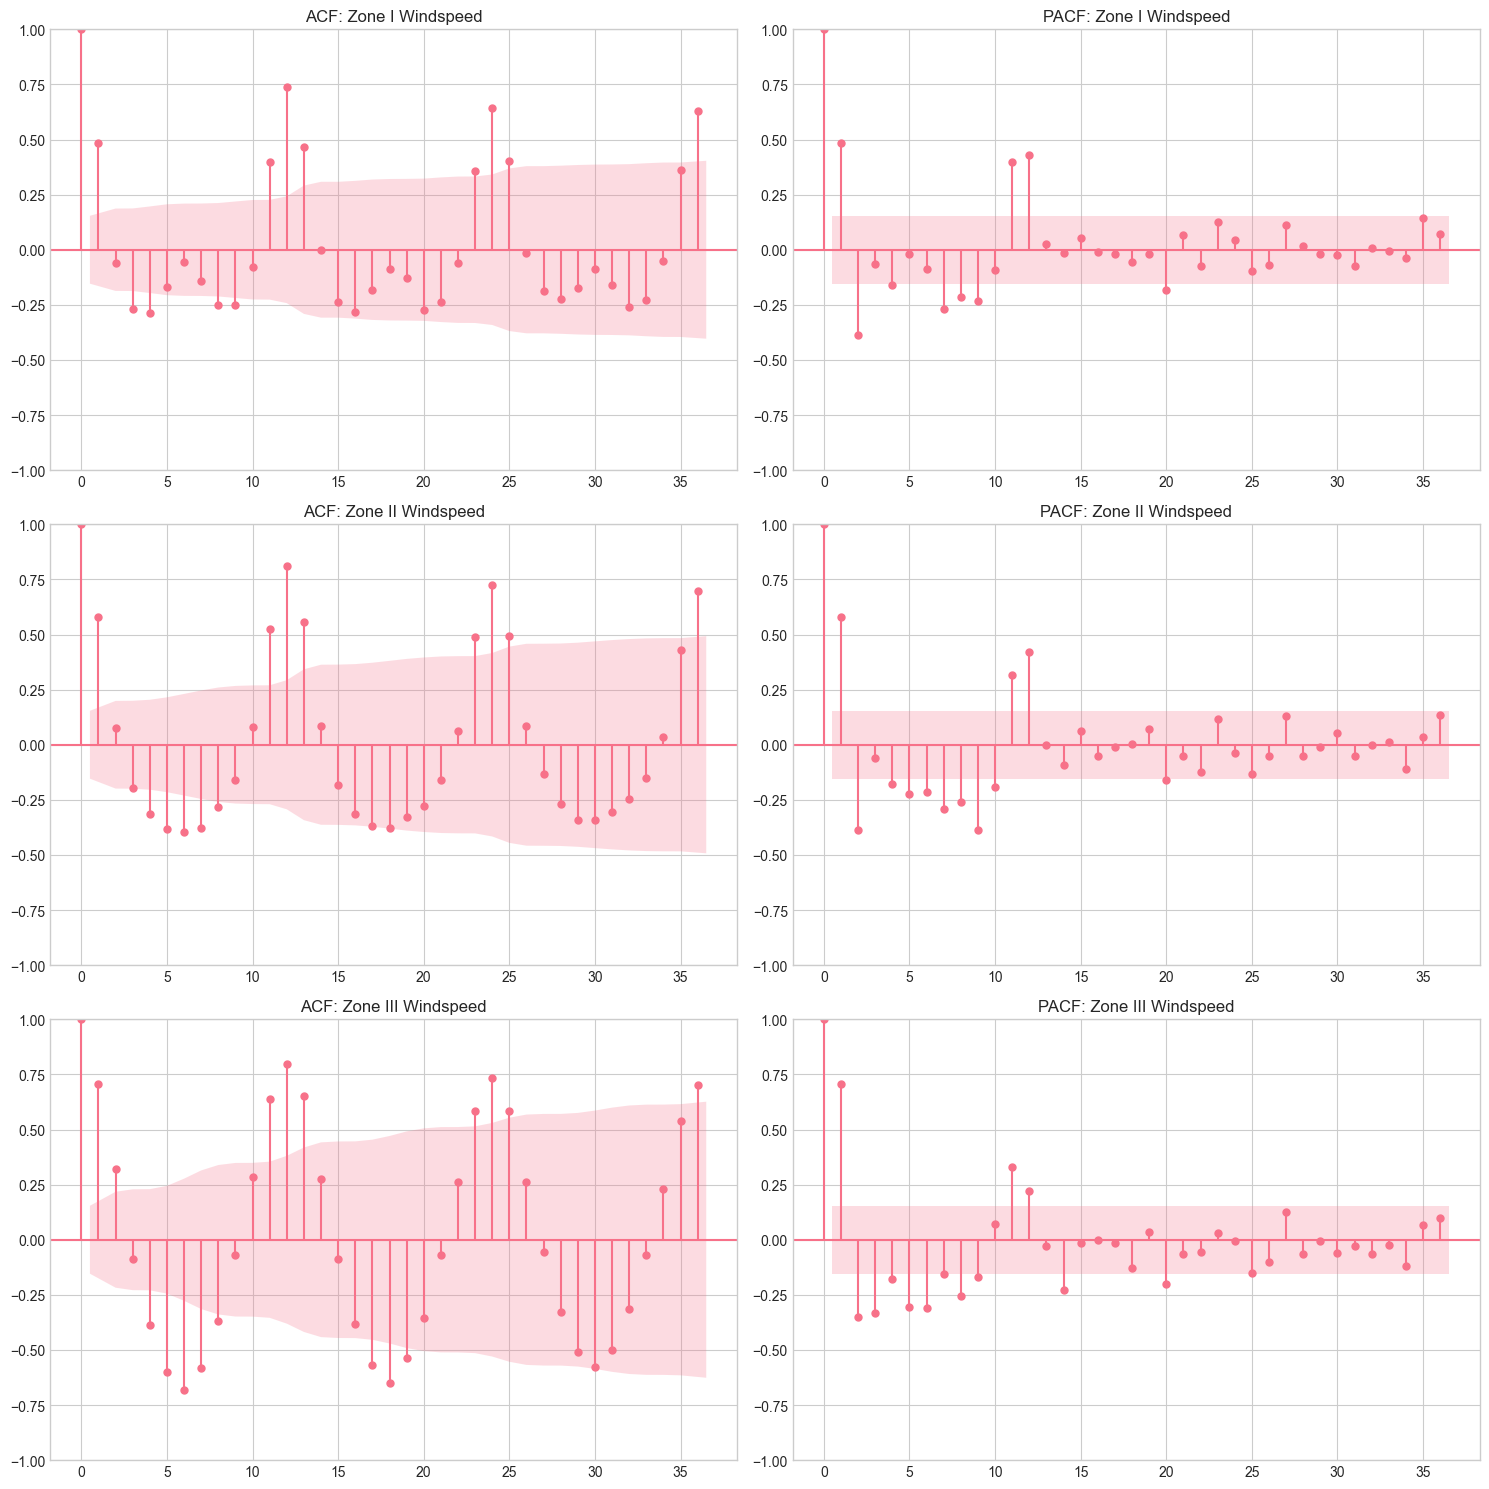

In [32]:
# Monthly Aggregation
evap_monthly = WEATHER.groupby([pd.Grouper(key='time', freq='ME'), 'wind_zone'])['windspeed_10m_max'].mean().unstack()


zones = evap_monthly.columns
fig, axes = plt.subplots(len(zones), 2, figsize=(15, 5 * len(zones)))

for i, zone in enumerate(zones):
    series = evap_monthly[zone].dropna()

    # ACF Plot
    plot_acf(series, ax=axes[i, 0], lags=36)
    axes[i, 0].set_title(f'ACF: {zone} Windspeed')

    # PACF Plot
    plot_pacf(series, ax=axes[i, 1], lags=36, method='ywm')
    axes[i, 1].set_title(f'PACF: {zone} Windspeed')

plt.tight_layout()
plt.show()

In [33]:
%pip install pmdarima

  Using cached pmdarima-2.1.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.5 kB)
  Using cached cython-3.2.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (7.5 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
Using cached pmdarima-2.1.1-cp312-cp312-macosx_11_0_arm64.whl (593 kB)
Using cached cython-3.2.4-cp312-cp312-macosx_11_0_arm64.whl (3.0 MB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pmdarima]2/3 [pmdarima]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
%pip install joblib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



ANALYZING: Wet Zone | VARIABLE: et0_fao_evapotranspiration
Optimizing SARIMA for et0_fao_evapotranspiration...
Optimal Model: (1, 1, 3)x(2, 1, 0, 12)
MAE: 0.2009 | RMSE: 0.2588


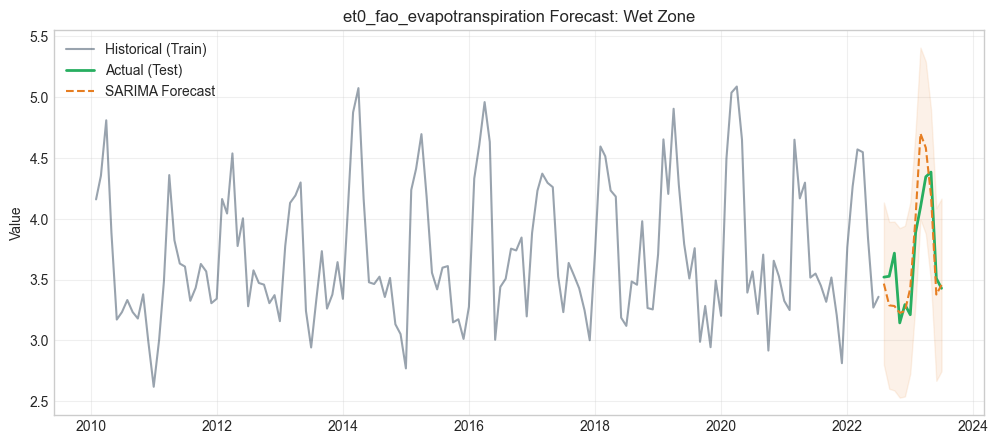

✅ Successfully exported: ../backend/models/sarima_et0_wet_zone.pkl

ANALYZING: Intermediate Zone | VARIABLE: et0_fao_evapotranspiration
Optimizing SARIMA for et0_fao_evapotranspiration...
Optimal Model: (2, 1, 1)x(2, 1, 1, 12)
MAE: 0.1916 | RMSE: 0.2404


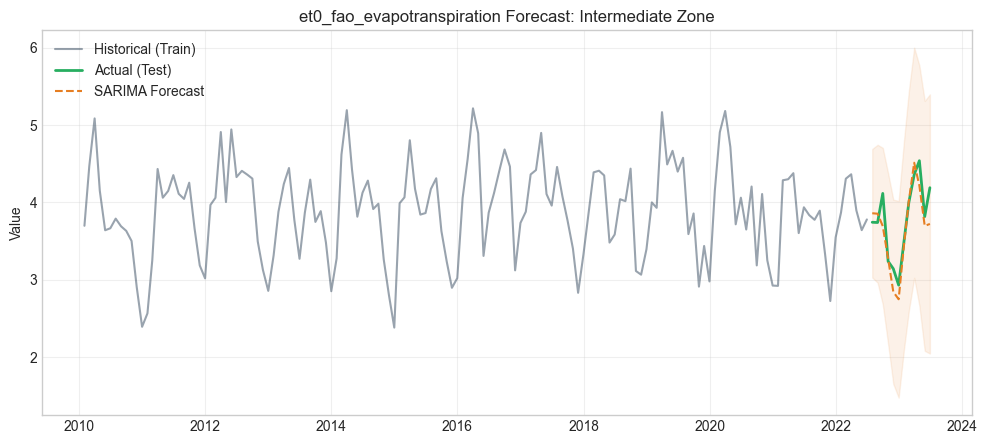

✅ Successfully exported: ../backend/models/sarima_et0_intermediate_zone.pkl

ANALYZING: Dry Zone | VARIABLE: et0_fao_evapotranspiration
Optimizing SARIMA for et0_fao_evapotranspiration...
Optimal Model: (1, 1, 1)x(2, 1, 0, 12)
MAE: 0.2157 | RMSE: 0.2771


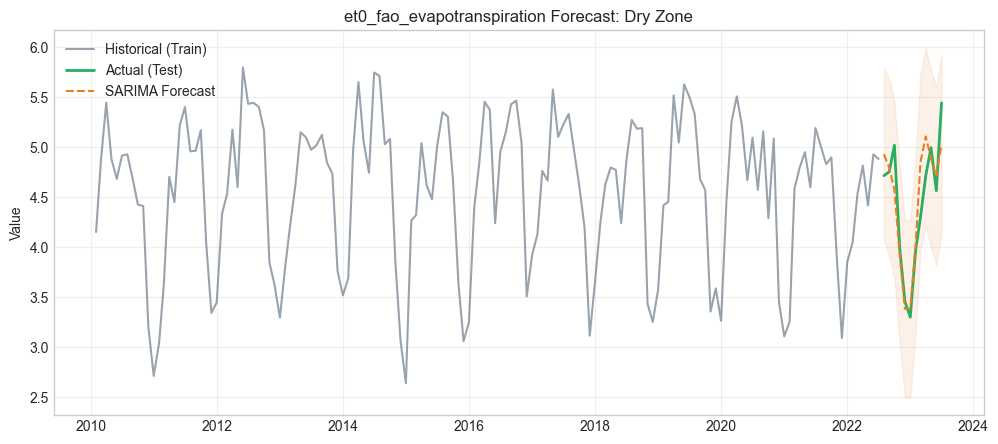

✅ Successfully exported: ../backend/models/sarima_et0_dry_zone.pkl

ANALYZING: Zone III | VARIABLE: windspeed_10m_max
Optimizing SARIMA for windspeed_10m_max...
Optimal Model: (5, 1, 0)x(2, 1, 0, 12)
MAE: 1.3425 | RMSE: 1.5795


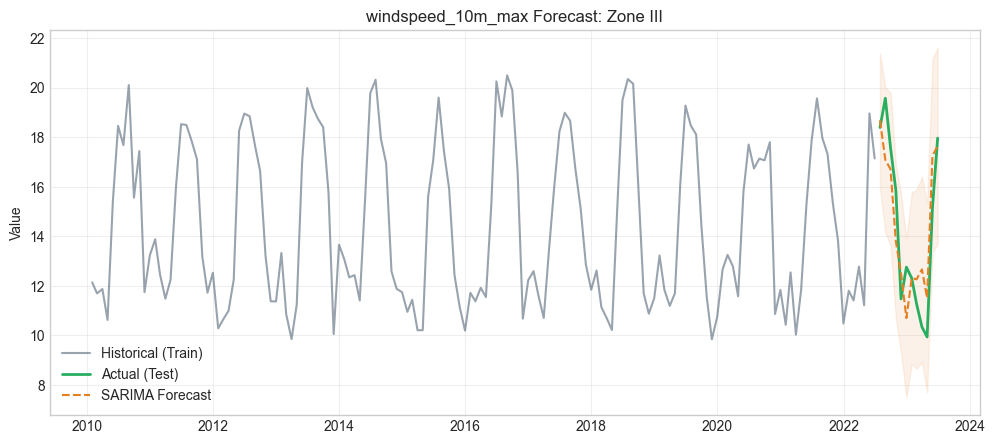

✅ Successfully exported: ../backend/models/sarima_wind_zone_iii.pkl

ANALYZING: Zone I | VARIABLE: windspeed_10m_max
Optimizing SARIMA for windspeed_10m_max...
Optimal Model: (0, 1, 1)x(2, 1, 1, 12)
MAE: 1.1074 | RMSE: 1.3511


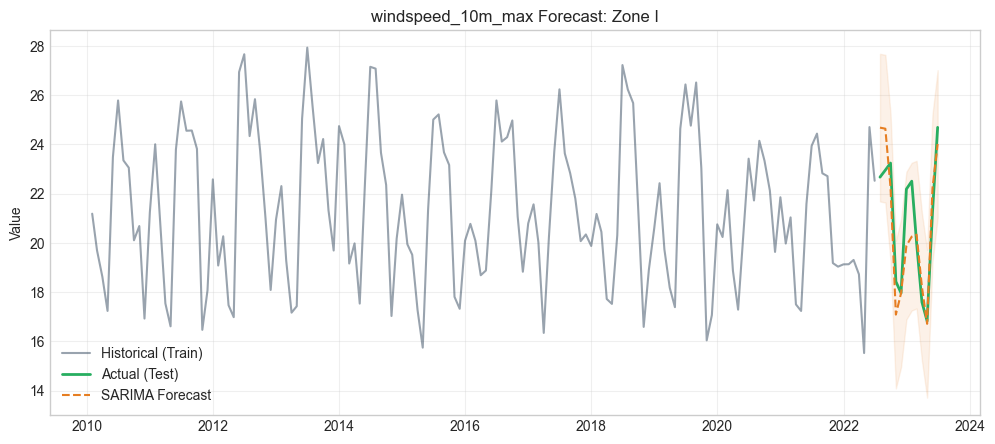

✅ Successfully exported: ../backend/models/sarima_wind_zone_i.pkl

ANALYZING: Zone II | VARIABLE: windspeed_10m_max
Optimizing SARIMA for windspeed_10m_max...
Optimal Model: (5, 1, 0)x(2, 1, 1, 12)
MAE: 0.9976 | RMSE: 1.3919


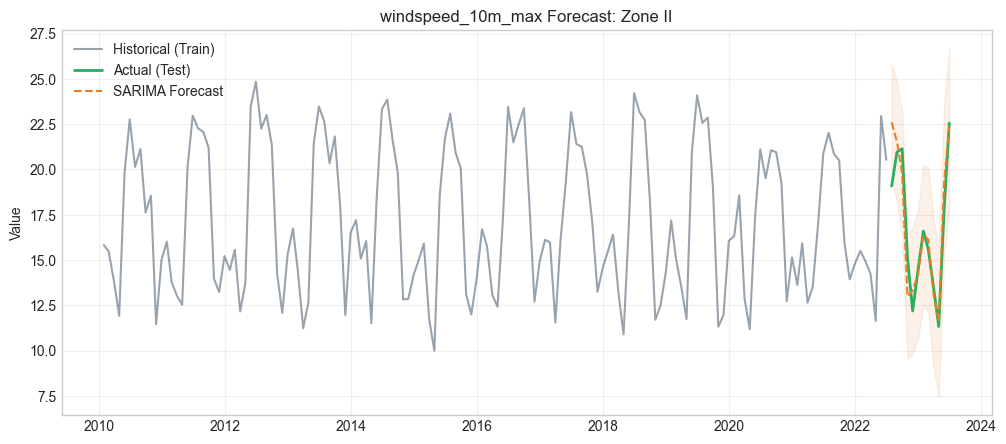

✅ Successfully exported: ../backend/models/sarima_wind_zone_ii.pkl


In [39]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm
import warnings
import joblib

warnings.filterwarnings("ignore")

def analyze_weather_variable(df, zone_name, target_col, zone_col):

    print(f"\n" + "="*60)
    print(f"ANALYZING: {zone_name} | VARIABLE: {target_col}")
    print("="*60)

    # Filter and Resample
    series = df[df[zone_col] == zone_name].groupby('time')[target_col].mean().resample('ME').mean().dropna()

    if len(series) < 24:
        print(f"Skipping {zone_name}: Not enough data points for seasonal SARIMA.")
        return None

    # Train-Test Split (Last 12 months for testing)
    train = series.iloc[:-12]
    test = series.iloc[-12:]

    #Automated Parameter Selection
    print(f"Optimizing SARIMA for {target_col}...")
    stepwise_model = pm.auto_arima(train,
                                   seasonal=True, m=12,
                                   d=1, D=1,
                                   trace=False,
                                   error_action='ignore',
                                   suppress_warnings=True,
                                   stepwise=True)

    # Fit Final Model
    model = SARIMAX(train,
                    order=stepwise_model.order,
                    seasonal_order=stepwise_model.seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    results = model.fit(disp=False)

    # Forecast & Evaluation
    forecast_obj = results.get_forecast(steps=12)
    pred_mean = forecast_obj.predicted_mean
    conf_int = forecast_obj.conf_int()

    mae = mean_absolute_error(test, pred_mean)
    rmse = np.sqrt(mean_squared_error(test, pred_mean))

    print(f"Optimal Model: {stepwise_model.order}x{stepwise_model.seasonal_order}")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")

    # Visualization
    plt.figure(figsize=(12, 5))
    plt.plot(train.index, train, label='Historical (Train)', color='#34495e', alpha=0.5)
    plt.plot(test.index, test, label='Actual (Test)', color='#27ae60', linewidth=2)
    plt.plot(pred_mean.index, pred_mean, label='SARIMA Forecast', color='#e67e22', linestyle='--')
    plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='#e67e22', alpha=0.1)

    plt.title(f"{target_col} Forecast: {zone_name}")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return results


# ---------------------------------------------------------
# 1. Analyze and Export Evapotranspiration Models
# ---------------------------------------------------------
evap_target = 'et0_fao_evapotranspiration'
for zone in WEATHER['zone'].unique():
    if pd.notna(zone):
        # Capture the model returned by your function
        model_result = analyze_weather_variable(WEATHER, zone, evap_target, 'zone')
        
        if model_result is not None:
            # Format the filename (e.g., 'Dry Zone' becomes 'dry_zone')
            safe_zone_name = zone.lower().replace(' ', '_')
            filename = f"../backend/models/sarima_et0_{safe_zone_name}.pkl"
            
            # Export the model
            joblib.dump(model_result, filename)
            print(f"✅ Successfully exported: {filename}")

# ---------------------------------------------------------
# 2. Analyze and Export Wind Speed Models
# ---------------------------------------------------------
wind_target = 'windspeed_10m_max'
for zone in WEATHER['wind_zone'].unique():
    if pd.notna(zone):
        # Capture the model returned by your function
        model_result = analyze_weather_variable(WEATHER, zone, wind_target, 'wind_zone')
        
        if model_result is not None:
            # Format the filename
            safe_zone_name = zone.lower().replace(' ', '_')
            filename = f"../backend/models/sarima_wind_{safe_zone_name}.pkl"
            
            # Export the model
            joblib.dump(model_result, filename)
            print(f"✅ Successfully exported: {filename}")

## Weather effect on major hydro power generation in Sri Lanka

In [ ]:
file_id = '1j9BcmoAJUW90LC9FwaCfosbc2r17Ea7Y'
download_url = f'https://drive.google.com/uc?export=download&id={file_id}'
try:
    GENERATION = pd.read_csv(download_url)
    print("CSV imported successfully!")
    print(GENERATION.head())
except Exception as e:
    print(f"An error occurred: {e}")

CSV imported successfully!
  Date (GMT+5:30)  Solar (Energy in GWh/day)  Wind (Energy in GWh/day)  \
0      2016-01-01                        NaN                       NaN   
1      2016-01-02                        NaN                       NaN   
2      2016-01-03                        NaN                       NaN   
3      2016-01-04                        NaN                       NaN   
4      2016-01-05                        NaN                       NaN   

   Major Hydro (Energy in GWh/day)  Oil (IPP) (Energy in GWh/day)  \
0                            17.72                           0.00   
1                            16.99                           0.00   
2                            15.75                           0.00   
3                            17.26                           0.07   
4                            16.22                           3.69   

  Oil (CEB) (Energy in GWh/day)  Coal (Energy in GWh/day)  \
0                          0.72                     

In [ ]:
# Convert to Datetime
GENERATION['Date (GMT+5:30)'] = pd.to_datetime(GENERATION['Date (GMT+5:30)'])

# Fill NaN values with 0
GENERATION = GENERATION.fillna(0)

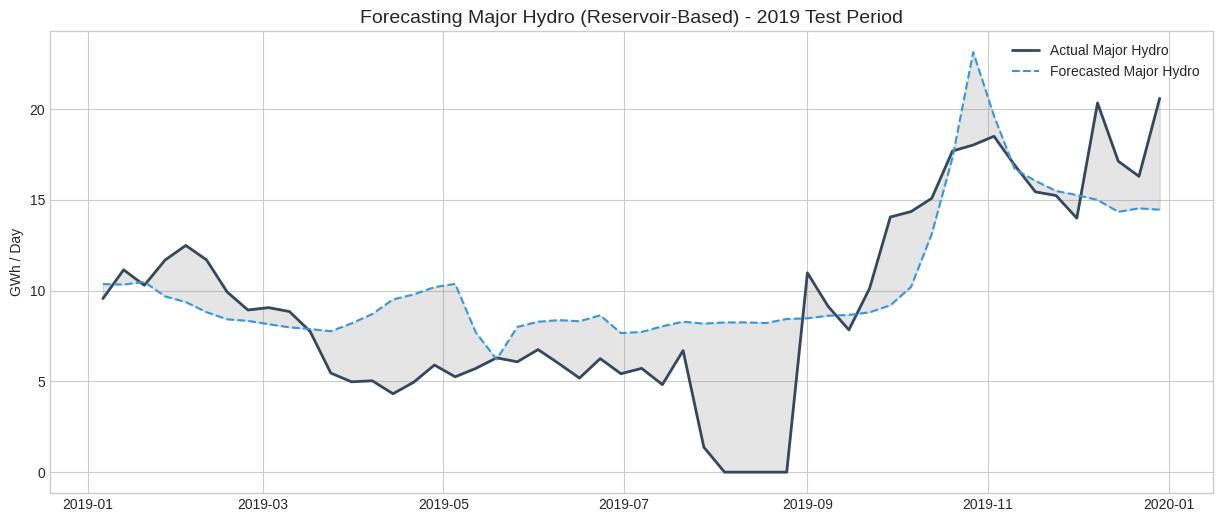

--- Major Hydro Evaluation (2019) ---
R-squared: 0.549
MAE: 2.81 GWh/day
MAPE: 38.54%


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# WEATHER DATA PREPARATION
df_weather = WEATHER.copy()
df_weather['time'] = pd.to_datetime(df_weather['time'])


if 'zone' not in df_weather.columns:
    df_weather['zone'] = df_weather['city'].map(zone_map)

# Feature Generation: Focus on Wet and Intermediate Zones
weather_cols = ['et0_fao_evapotranspiration', 'precipitation_sum']
zonal_daily = df_weather.groupby(['time', 'zone'])[weather_cols].mean(numeric_only=True).unstack()
zonal_daily.columns = [f"{col[0]}_{col[1]}" for col in zonal_daily.columns]

# Cumulative Features (Reservoir)
for zone in ['Wet Zone', 'Intermediate Zone']:
    if f'precipitation_sum_{zone}' in zonal_daily.columns:
        zonal_daily[f'Rain_180_{zone}'] = zonal_daily[f'precipitation_sum_{zone}'].rolling(window=180).sum()
    if f'et0_fao_evapotranspiration_{zone}' in zonal_daily.columns:
        zonal_daily[f'ET0_90_{zone}'] = zonal_daily[f'et0_fao_evapotranspiration_{zone}'].rolling(window=90).mean()

# Weekly Resample (Sunday Anchor)
df_w = zonal_daily.resample('W-SUN').mean(numeric_only=True)

# GENERATION DATA: ISOLATE MAJOR HYDRO
gen_w = GENERATION.copy()
gen_w = gen_w.rename(columns={'Date (GMT+5:30)': 'time'})
gen_w['time'] = pd.to_datetime(gen_w['time'])


target_col = 'Major Hydro (Energy in GWh/day)'
gen_w[target_col] = pd.to_numeric(gen_w[target_col], errors='coerce').fillna(0)

# Weekly Resample
gen_w = gen_w.set_index('time').resample('W-SUN').mean(numeric_only=True)

# MERGE & LAG
df_final = pd.merge(gen_w[[target_col]], df_w, left_index=True, right_index=True, how='inner')

# PREVENT LEAKAGE: Shift features by 1 week
feature_cols = [c for c in df_final.columns if 'Rain_180' in c or 'ET0_90' in c]
df_final[feature_cols] = df_final[feature_cols].shift(1)
df_final['day_sin'] = np.sin(2 * np.pi * df_final.index.dayofyear / 365.25)
df_final = df_final.dropna()

# TRAIN (2016-2018) & TEST (2019)
train_df_power = df_final[(df_final.index.year >= 2016) & (df_final.index.year <= 2018)]
test_df_power = df_final[df_final.index.year == 2019]

X_train_power, y_train_power = train_df_power[feature_cols + ['day_sin']], train_df_power[target_col]
X_test_power, y_test_power = test_df_power[feature_cols + ['day_sin']], test_df_power[target_col]

# Random Forest
model = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42)
model.fit(X_train_power, y_train_power)

# EVALUATION
y_pred = model.predict(X_test_power)
r2 = r2_score(y_test_power, y_pred)
mae = mean_absolute_error(y_test_power, y_pred)
mask = y_test_power > 0.1
safe_mape = np.mean(np.abs((y_test_power[mask] - y_pred[mask]) / y_test_power[mask])) * 100

# VISUALIZATION
plt.figure(figsize=(15, 6))
plt.plot(test_df_power.index, y_test_power, label='Actual Major Hydro', color='#34495e', linewidth=2)
plt.plot(test_df_power.index, y_pred, label='Forecasted Major Hydro', color='#3498db', linestyle='--')
plt.fill_between(test_df_power.index, y_test_power, y_pred, color='gray', alpha=0.2)
plt.title('Forecasting Major Hydro (Reservoir-Based) - 2019 Test Period', fontsize=14)
plt.ylabel('GWh / Day')
plt.legend()
plt.show()

print(f"--- Major Hydro Evaluation (2019) ---")
print(f"R-squared: {r2:.3f}")
print(f"MAE: {mae:.2f} GWh/day")
print(f"MAPE: {safe_mape:.2f}%")

In [ ]:
y_train_pred = model.predict(X_train_power)

train_r2 = r2_score(y_train_power, y_train_pred)
test_r2 = r2_score(y_test_power, y_pred)

train_mae = mean_absolute_error(y_train_power, y_train_pred)
test_mae = mean_absolute_error(y_test_power, y_pred)

print(f"--- Overfitting Check ---")
print(f"Train R2: {train_r2:.3f} | Test R2: {test_r2:.3f}")
print(f"Train MAE: {train_mae:.2f} | Test MAE: {test_mae:.2f}")

if train_r2 > test_r2 + 0.15:
    print("DIAGNOSIS: Likely OVERFITTING (Model memorized the noise in 2016-2018 data)")
elif train_r2 < 0.5 and test_r2 < 0.5:
    print("DIAGNOSIS: Likely UNDERFITTING (Model is too simple for this hydro data)")
else:
    print("DIAGNOSIS: Good Fit")

--- Overfitting Check ---
Train R2: 0.964 | Test R2: 0.549
Train MAE: 0.72 | Test MAE: 2.81
DIAGNOSIS: Likely OVERFITTING (Model memorized the noise in 2016-2018 data)


Best Params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 12}
Best Validation Score (Avg R2 during CV): -1.925

--- Overfitting Check (Tuned Model) ---
Train R2: 0.562 | Test R2: 0.604
Train MAE: 2.78 | Test MAE: 2.59
Test MAPE: 35.03%
DIAGNOSIS: Good Fit (Gap: -0.04)


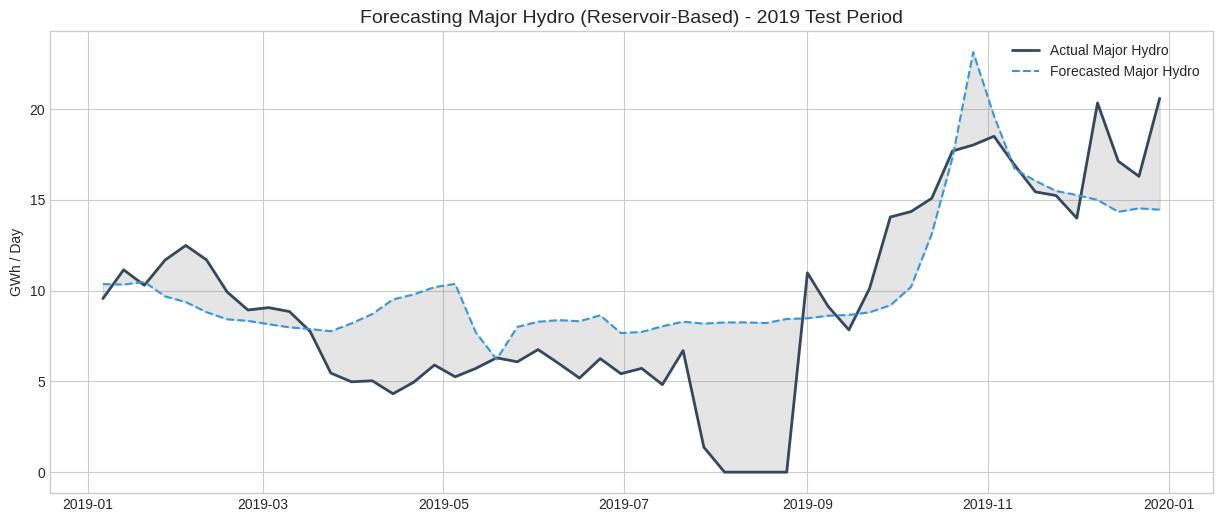

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

#SETUP GRID SEARCH
param_grid = {
    'max_depth': [3, 4, 5, 7],         # Lower depths to reduce overfitting
    'min_samples_leaf': [2, 5, 8, 12], # Higher numbers smooth out noise
    'max_features': ['sqrt', 1.0]
}

tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(n_estimators=200, random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

#FIT AND FIND BEST PARAMS
grid_search.fit(X_train_power, y_train_power)

print(f"Best Params: {grid_search.best_params_}")
print(f"Best Validation Score (Avg R2 during CV): {grid_search.best_score_:.3f}")

#RETRAIN BEST MODEL
best_model = grid_search.best_estimator_
best_model.fit(X_train_power, y_train_power)

#PREDICT BOTH TRAIN AND TEST (For Overfitting Check)
y_train_pred_new = best_model.predict(X_train_power) # <--- New Line
y_test_pred_new = best_model.predict(X_test_power)   # <--- Renamed to avoid confusion

#CALCULATE METRICS
# Train Metrics
train_r2 = r2_score(y_train_power, y_train_pred_new)
train_mae = mean_absolute_error(y_train_power, y_train_pred_new)

# Test Metrics
test_r2 = r2_score(y_test_power, y_test_pred_new)
test_mae = mean_absolute_error(y_test_power, y_test_pred_new)

# MAPE (Using the NEW predictions)
mask = y_test_power > 0.1
safe_mape = np.mean(np.abs((y_test_power[mask] - y_test_pred_new[mask]) / y_test_power[mask])) * 100

#PRINT DIAGNOSIS
print(f"\n--- Overfitting Check (Tuned Model) ---")
print(f"Train R2: {train_r2:.3f} | Test R2: {test_r2:.3f}")
print(f"Train MAE: {train_mae:.2f} | Test MAE: {test_mae:.2f}")
print(f"Test MAPE: {safe_mape:.2f}%")

gap = train_r2 - test_r2

if gap > 0.15:
    print(f"DIAGNOSIS: Still Overfitting (Gap: {gap:.2f}). Try increasing min_samples_leaf.")
elif train_r2 < 0.5:
    print(f"DIAGNOSIS: Underfitting (Gap: {gap:.2f}). The model is too restricted.")
else:
    print(f"DIAGNOSIS: Good Fit (Gap: {gap:.2f})")

# VISUALIZATION
plt.figure(figsize=(15, 6))
plt.plot(test_df_power.index, y_test_power, label='Actual Major Hydro', color='#34495e', linewidth=2)
plt.plot(test_df_power.index, y_pred, label='Forecasted Major Hydro', color='#3498db', linestyle='--')
plt.fill_between(test_df_power.index, y_test_power, y_pred, color='gray', alpha=0.2)
plt.title('Forecasting Major Hydro (Reservoir-Based) - 2019 Test Period', fontsize=14)
plt.ylabel('GWh / Day')
plt.legend()
plt.show()

## Objective 4: Geographical Influences on Extreme Events in Climate Variables

In [ ]:
from scipy import stats
from sklearn.ensemble import IsolationForest

In [ ]:
features = ['temperature_2m_mean', 'shortwave_radiation_sum',
            'precipitation_sum', 'windspeed_10m_max', 'elevation']

iso_train_df = train_df >> select(X.time, X.city, *features)
iso_test_df = test_df >> select(X.time, X.city, *features)


### Statistical Anomaly Detection (Z-Score)
Points with a Z-score > 3 or < -3 are considered anomalies.

Anomalies in temperature_2m_mean: 2864
             time      city  temperature_2m_mean
45910  2014-07-25  Kalmunai                 31.8
134851 2015-10-21    Hatton                 20.6
136928 2021-06-28    Hatton                 20.6
136348 2019-11-26    Hatton                 20.6
133899 2013-03-13    Hatton                 20.6


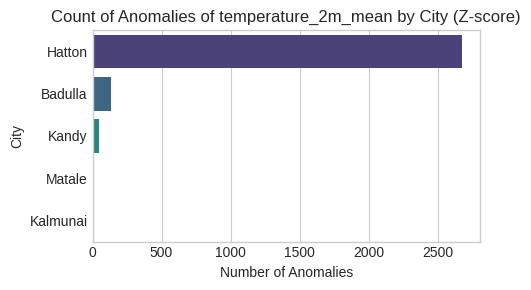

--------------------------------------------------
Anomalies in shortwave_radiation_sum: 1318
             time         city  shortwave_radiation_sum
114502 2013-12-05       Mannar                     5.86
51284  2015-10-26  Trincomalee                     5.86
133781 2012-11-15       Hatton                     5.86
85390  2014-12-24      Gampaha                     5.85
144382 2014-12-24      Oruwala                     5.85


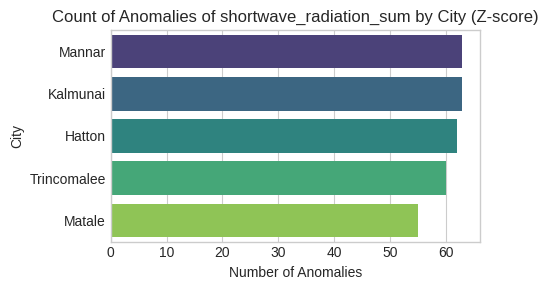

--------------------------------------------------
Anomalies in precipitation_sum: 2096
             time                       city  precipitation_sum
120310 2016-05-15                  Pothuhera              338.8
125226 2016-05-15                 Kurunegala              338.8
110478 2016-05-15                     Matale              300.4
41654  2016-05-15  Sri Jayewardenepura Kotte              261.8
85898  2016-05-15                    Gampaha              261.8


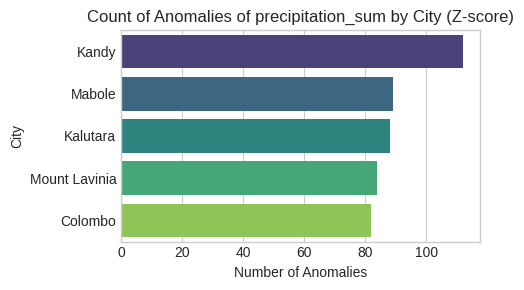

--------------------------------------------------
Anomalies in windspeed_10m_max: 1298
            time    city  windspeed_10m_max
62785 2020-05-21  Jaffna               50.2
63154 2021-05-25  Jaffna               48.5
63717 2022-12-09  Jaffna               48.3
63524 2022-05-30  Jaffna               48.0
59129 2010-05-18  Jaffna               48.0


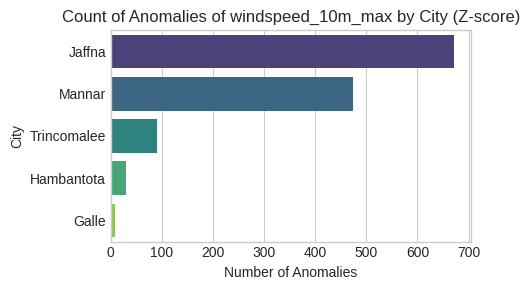

--------------------------------------------------


In [ ]:
from dfply import *
for var in ['temperature_2m_mean', 'shortwave_radiation_sum', 'precipitation_sum', 'windspeed_10m_max']:
    anomalies = (iso_train_df >>
                 mask(abs((X[var] - X[var].mean()) / X[var].std()) > 3) >>
                 arrange(X[var], ascending=False))

    print(f"Anomalies in {var}: {len(anomalies)}")
    if not anomalies.empty:
        print(anomalies[['time', 'city', var]] >> head(5))
    city_anomalies = anomalies['city'].value_counts().reset_index()
    city_anomalies.columns = ['city', 'anomaly_count']

    plt.figure(figsize=(5, 3))
    sns.barplot(x='anomaly_count', y='city', data=city_anomalies.head(), palette='viridis')
    plt.title(f'Count of Anomalies of {var} by City (Z-score)')
    plt.xlabel('Number of Anomalies')
    plt.ylabel('City')
    plt.tight_layout()
    plt.show()

    print("-" * 50)


In [ ]:
var = 'temperature_2m_mean'

# Calculate the fixed 3rd sigma boundaries
mean_val = iso_train_df[var].mean()
std_val = iso_train_df[var].std()

upper_limit = mean_val + (3 * std_val)
lower_limit = mean_val - (3 * std_val)

# Filter for points outside the 3-sigma band
anomalies = (iso_train_df >>
             mask((X[var] > upper_limit) | (X[var] < lower_limit)) >>
             arrange(X.time, ascending=True))

print(f"Lower Bound: {lower_limit:.2f}°C | Upper Bound: {upper_limit:.2f}°C")
print(f"Total Anomalies found: {len(anomalies)}")

Lower Bound: 20.70°C | Upper Bound: 31.75°C
Total Anomalies found: 2864


In [ ]:
def plot_anomalies_for_city(city_name, var, iso_train_df, anomalies, lower_limit = None, upper_limit = None):
    plot_data = (iso_train_df >>
                 mask(X.city == city_name) >>
                 arrange(X.time))

    city_anomalies_data = (anomalies >>
                           mask(X.city == city_name) >>
                           arrange(X.time))

    plt.figure(figsize=(15, 6))

    plt.plot(plot_data.time, plot_data[var], label='Data', color='blue', alpha=0.3)

    # Plot the anomalies
    plt.scatter(city_anomalies_data.time, city_anomalies_data[var],
                color='red', label='Anomaly', s=20, zorder=5)

    if lower_limit is not None or upper_limit is not None:
        # Add the Cutoff Band
        if upper_limit is not None:
            plt.axhline(upper_limit, color='green', linestyle='--', alpha=0.7, label='Upper Cutoff (3σ)')

        if lower_limit is not None:
            plt.axhline(lower_limit, color='green', linestyle='--', alpha=0.7, label='Lower Cutoff (3σ)')

        # Shade the "normal" region only if both limits exist to avoid plotting errors
        if lower_limit is not None and upper_limit is not None:
            plt.fill_between(plot_data.time, lower_limit, upper_limit, color='green', alpha=0.05, label='Normal Range')
    plt.title(f'Time Series Anomalies & Z-Score Cutoffs in {city_name}: {var}')
    plt.xlabel('Time')
    plt.ylabel(var)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()


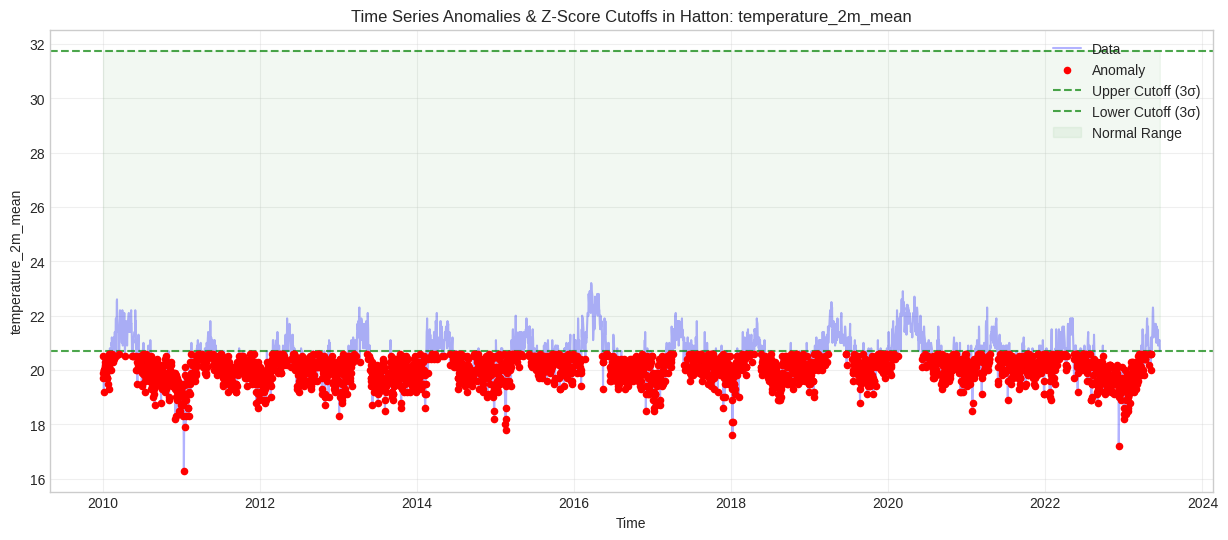

In [ ]:
plot_anomalies_for_city('Hatton', var, iso_train_df, anomalies,
                        lower_limit, upper_limit)

In [ ]:
median_val = iso_train_df['temperature_2m_mean'].median()

# Calculate the Median Absolute Deviation (MAD)
mad_val = (iso_train_df[var] - median_val).abs().median()

# Define the threshold
# We use 1.4826 as a scaling factor to make MAD comparable to
# Standard Deviation for a normal distribution.
consistency_constant = 1.4826
upper_limit = median_val + (3 * consistency_constant * mad_val)
lower_limit = median_val - (3 * consistency_constant * mad_val)

# Filter for points outside the robust band
anomalies = (iso_train_df >>
             mask((X[var] > upper_limit) | (X[var] < lower_limit)) >>
             arrange(X[var], ascending=False))

print(f"Median: {median_val:.2f}°C")
print(f"Lower Bound (Robust): {lower_limit:.2f}°C | Upper Bound (Robust): {upper_limit:.2f}°C")
print(f"Total Anomalies found using Median: {len(anomalies)}")

Median: 26.40°C
Lower Bound (Robust): 22.84°C | Upper Bound (Robust): 29.96°C
Total Anomalies found using Median: 7659


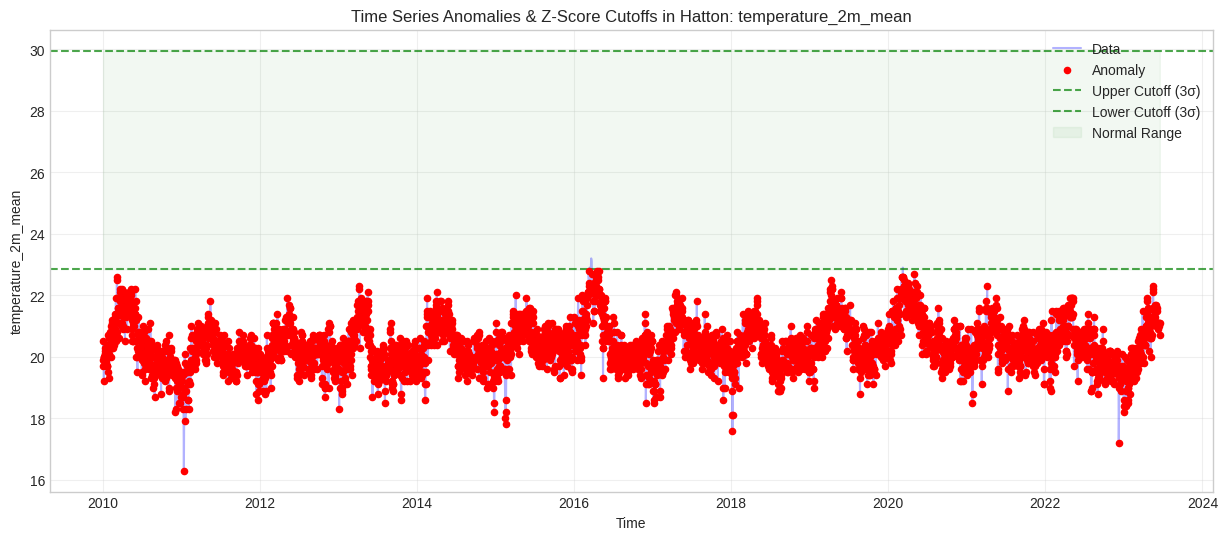

In [ ]:
plot_anomalies_for_city('Hatton', var, iso_train_df, anomalies,
                        lower_limit, upper_limit)

### Isolation Forest Approach

In [ ]:
iso_model = IsolationForest(contamination=0.01, random_state=42)
iso_train_df['anomaly'] = iso_model.fit_predict(iso_train_df[
    ['temperature_2m_mean', 'shortwave_radiation_sum',
     'precipitation_sum', 'windspeed_10m_max']
    ])
iso_test_df['anomaly'] = iso_model.predict(iso_test_df[
    ['temperature_2m_mean', 'shortwave_radiation_sum',
     'precipitation_sum', 'windspeed_10m_max']
    ])

# -1 indicates anomaly, 1 indicates normal
anomalies_iso = iso_train_df[iso_train_df['anomaly'] == -1]

print(f"Total Anomalies Detected by Isolation Forest: {len(anomalies_iso)}")
print("Sample Anomalies:")
print(anomalies_iso.sort_values(by='temperature_2m_mean', ascending=False).head())

Total Anomalies Detected by Isolation Forest: 1180
Sample Anomalies:
            time    city  temperature_2m_mean  shortwave_radiation_sum  \
62784 2020-05-20  Jaffna                 30.4                    25.00   
61682 2017-05-14  Jaffna                 30.3                    23.70   
62398 2019-04-30  Jaffna                 30.2                    11.43   
61322 2016-05-19  Jaffna                 29.4                    20.74   
59132 2010-05-21  Jaffna                 29.3                    11.35   

       precipitation_sum  windspeed_10m_max  elevation  anomaly  
62784                0.0               41.2          5       -1  
61682                0.2               40.3          5       -1  
62398                0.8               40.0          5       -1  
61322               10.0               45.5          5       -1  
59132                3.8               40.3          5       -1  


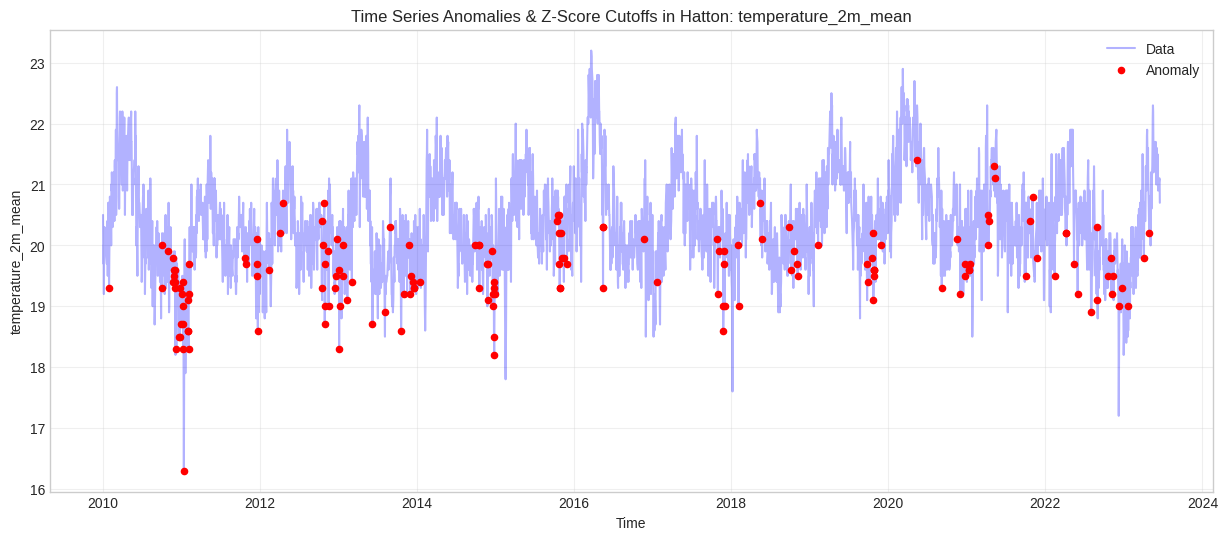

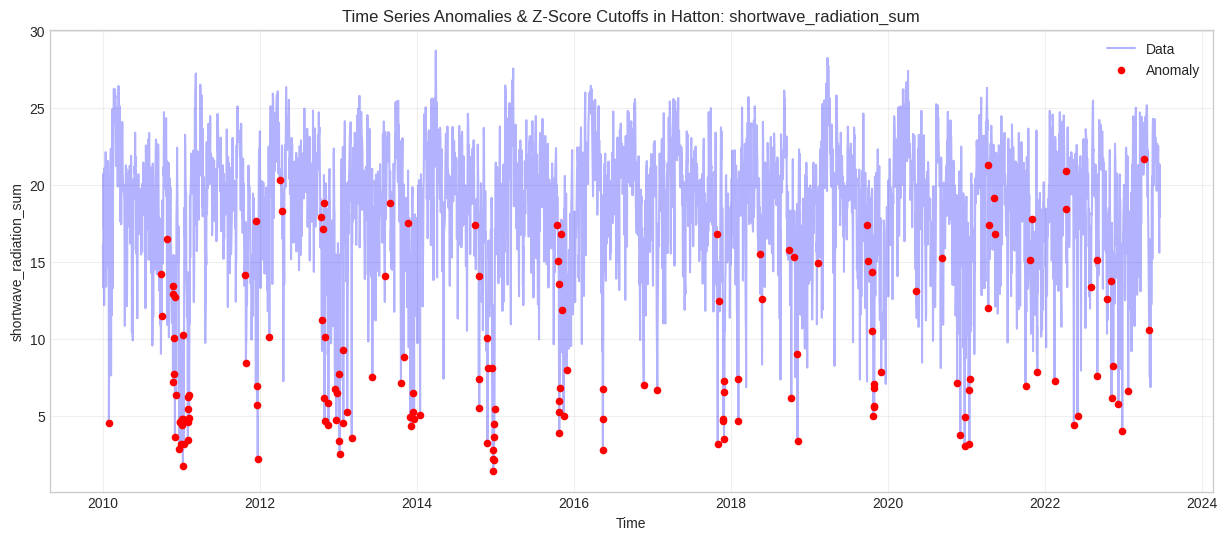

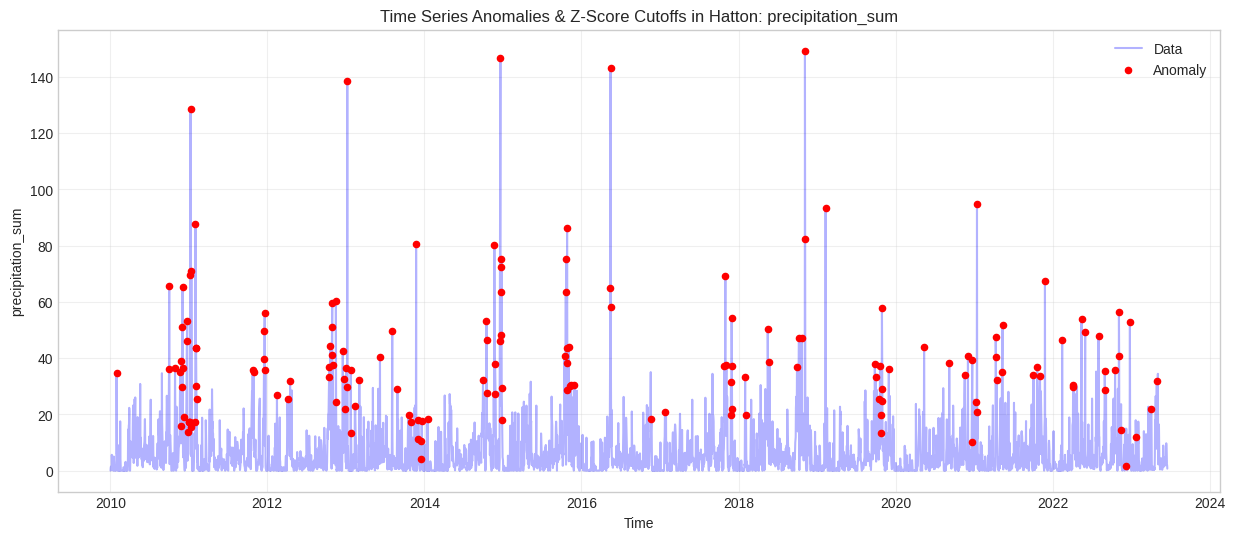

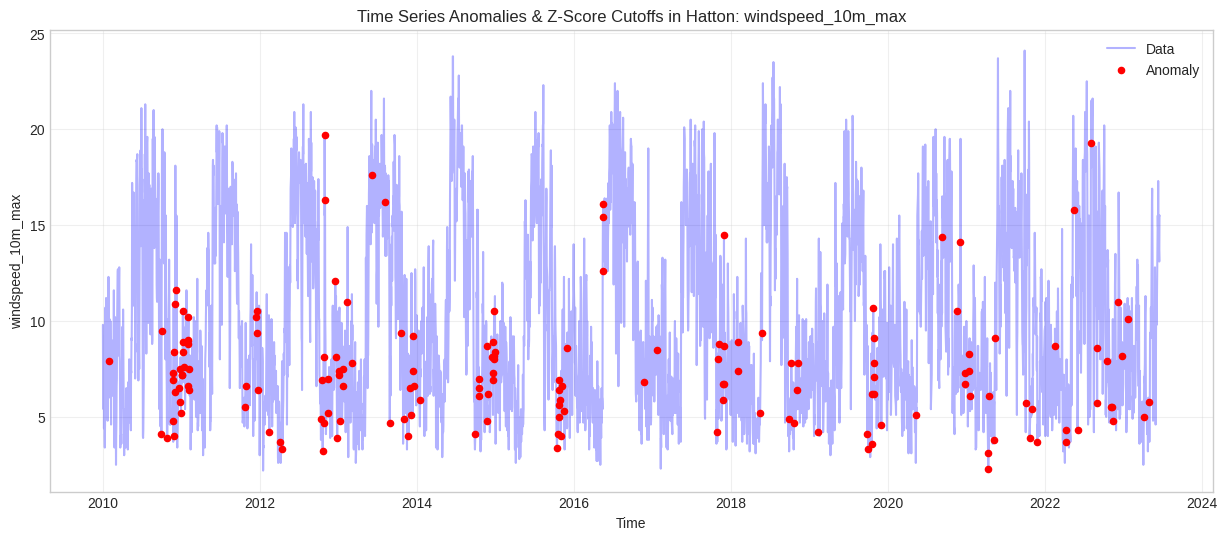

In [ ]:
for var in ['temperature_2m_mean', 'shortwave_radiation_sum', 'precipitation_sum', 'windspeed_10m_max']:
  plot_anomalies_for_city('Hatton', var, iso_train_df, anomalies_iso)

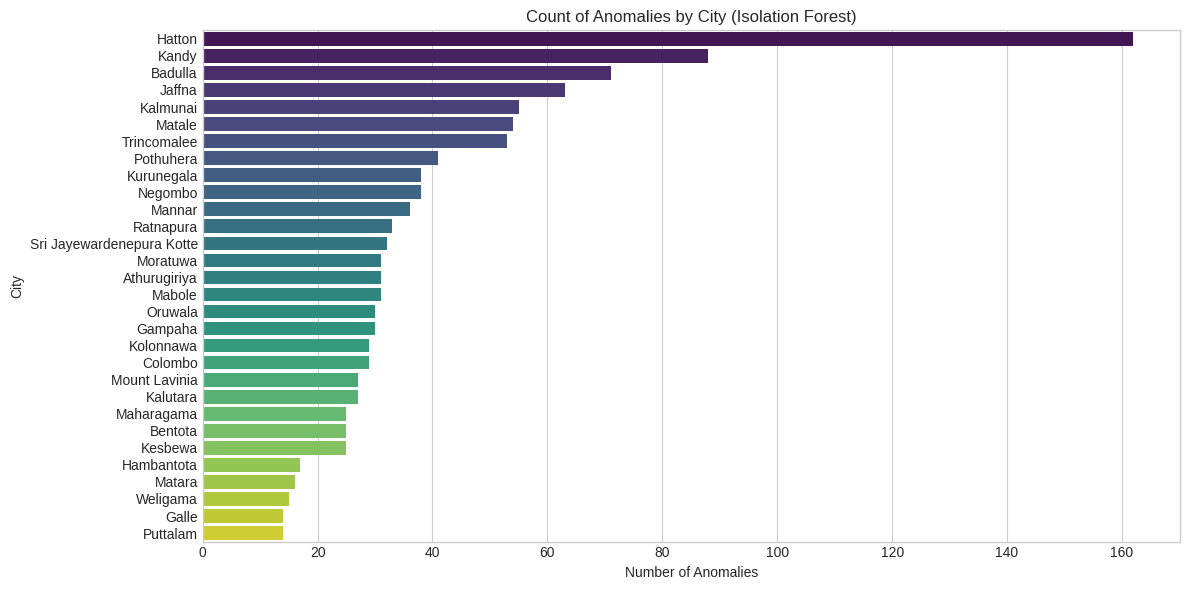

In [ ]:
# Count anomalies by city
city_anomalies = anomalies_iso['city'].value_counts().reset_index()
city_anomalies.columns = ['city', 'anomaly_count']

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='anomaly_count', y='city', data=city_anomalies, palette='viridis')
plt.title('Count of Anomalies by City (Isolation Forest)')
plt.xlabel('Number of Anomalies')
plt.ylabel('City')
plt.tight_layout()
plt.show()

In [ ]:
detect_vars = ['temperature_2m_mean','apparent_temperature_mean', 'shortwave_radiation_sum',
               'precipitation_sum', 'windspeed_10m_max', 'weathercode', 'time', 'windgusts_10m_max',
               'temperature_2m_min', 'apparent_temperature_min', 'temperature_2m_max', 'apparent_temperature_max',
               'anomaly', 'rain_sum', 'snowfall_sum', 'is_anomaly', 'precip_intensity']

train_df['anomaly'] = iso_model.fit_predict(train_df[
    ['temperature_2m_mean', 'shortwave_radiation_sum',
     'precipitation_sum', 'windspeed_10m_max']
    ])

train_df['is_anomaly'] = train_df['anomaly'].apply(lambda x: 1 if x == -1 else 0)

test_df['anomaly'] = iso_model.predict(test_df[
    ['temperature_2m_mean', 'shortwave_radiation_sum',
     'precipitation_sum', 'windspeed_10m_max']
    ])

test_df['is_anomaly'] = test_df['anomaly'].apply(lambda x: 1 if x == -1 else 0)

# Setting up train-test sets
y_train = train_df['is_anomaly']
X_train = train_df.drop([c for c in detect_vars if c in train_df.columns], axis=1)
y_test = test_df['is_anomaly']
X_test = test_df.drop([c for c in detect_vars if c in test_df.columns], axis=1)


In [ ]:
# Imports for Imbalanced Learning
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Imbalanced-learn imports
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier

numeric_features = [str(c) for c in X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()]
categorical_features = ['city']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

# Define Expanded Model Suite
models = {}

models["LogReg"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

models["RandomForest"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

models["GradientBoosting"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

models["XGBoost"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42))
])

models["LogReg (Balanced)"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

models["Elastic Net (Balanced)"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5,
                                      max_iter=1000, class_weight='balanced', random_state=42))
])

# --- Imbalance Strategies (Resampling) ---
models["SMOTE + LogReg"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('resampler', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

models["SMOTEENN + LogReg"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('resampler', SMOTEENN(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

models["RandomUnderSampler + LogReg"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('resampler', RandomUnderSampler(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# --- Ensemble Methods for Imbalance ---
models["Balanced Random Forest"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BalancedRandomForestClassifier(n_estimators=100, random_state=42))
])

models["Easy Ensemble"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', EasyEnsembleClassifier(n_estimators=10, random_state=42))
])

# Evaluation
print("--- Cross-Validation Scores (ROC-AUC) ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    try:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
        print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")
    except Exception as e:
        print(f"{name}: Failed - {str(e)}")

print("\n--- Test Set Evaluation ---")
for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        print(f"\nModel: {name}")
        print(classification_report(y_test, y_pred))
        print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
    except Exception as e:
        print(f"\nModel: {name} Failed during test eval - {str(e)}")


--- Cross-Validation Scores (ROC-AUC) ---
LogReg: 0.9941 (+/- 0.0026)
RandomForest: 0.9945 (+/- 0.0022)
GradientBoosting: 0.9976 (+/- 0.0012)
XGBoost: 0.9976 (+/- 0.0014)
LogReg (Balanced): 0.9957 (+/- 0.0009)
Elastic Net (Balanced): 0.9958 (+/- 0.0009)
SMOTE + LogReg: 0.9957 (+/- 0.0008)
SMOTEENN + LogReg: 0.9957 (+/- 0.0009)
RandomUnderSampler + LogReg: 0.9957 (+/- 0.0012)
Balanced Random Forest: 0.9973 (+/- 0.0007)
Easy Ensemble: 0.9974 (+/- 0.0006)

--- Test Set Evaluation ---

Model: LogReg Failed during test eval - columns are missing: {'precip_intensity'}

Model: RandomForest Failed during test eval - columns are missing: {'precip_intensity'}

Model: GradientBoosting Failed during test eval - columns are missing: {'precip_intensity'}

Model: XGBoost Failed during test eval - columns are missing: {'precip_intensity'}

Model: LogReg (Balanced) Failed during test eval - columns are missing: {'precip_intensity'}

Model: Elastic Net (Balanced) Failed during test eval - columns are mi

In [ ]:
from sklearn.metrics import confusion_matrix

# Test Set Evaluation & Custom Table
print("\n--- Test Set Evaluation ---")
table_data = []

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        # Calculate Confusion Matrix
        # Confusion matrix returns [[TN, FP], [FN, TP]]
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        table_data.append({
            "Model": name,
            "TP (Caught)": tp,
            "FN (Missed)": fn,
            "FP (False Alarms)": fp,
            "TN (Correct 0s)": tn
        })
    except Exception as e:
        print(f"Model {name} failed prediction: {e}")

# Create DataFrame
results_df = pd.DataFrame(table_data)
if not results_df.empty:
    results_df = results_df.set_index("Model")

    # Display formatted table style
    display(results_df.style.background_gradient(cmap='RdYlGn', subset=['TP (Caught)', 'TN (Correct 0s)'])
                            .background_gradient(cmap='RdYlGn_r', subset=['FN (Missed)', 'FP (False Alarms)'])
                            .format("{:,}"))


--- Test Set Evaluation ---
Model LogReg failed prediction: columns are missing: {'precip_intensity'}
Model RandomForest failed prediction: columns are missing: {'precip_intensity'}
Model GradientBoosting failed prediction: columns are missing: {'precip_intensity'}
Model XGBoost failed prediction: columns are missing: {'precip_intensity'}
Model LogReg (Balanced) failed prediction: columns are missing: {'precip_intensity'}
Model Elastic Net (Balanced) failed prediction: columns are missing: {'precip_intensity'}
Model SMOTE + LogReg failed prediction: columns are missing: {'precip_intensity'}
Model SMOTEENN + LogReg failed prediction: columns are missing: {'precip_intensity'}
Model RandomUnderSampler + LogReg failed prediction: columns are missing: {'precip_intensity'}
Model Balanced Random Forest failed prediction: columns are missing: {'precip_intensity'}
Model Easy Ensemble failed prediction: columns are missing: {'precip_intensity'}


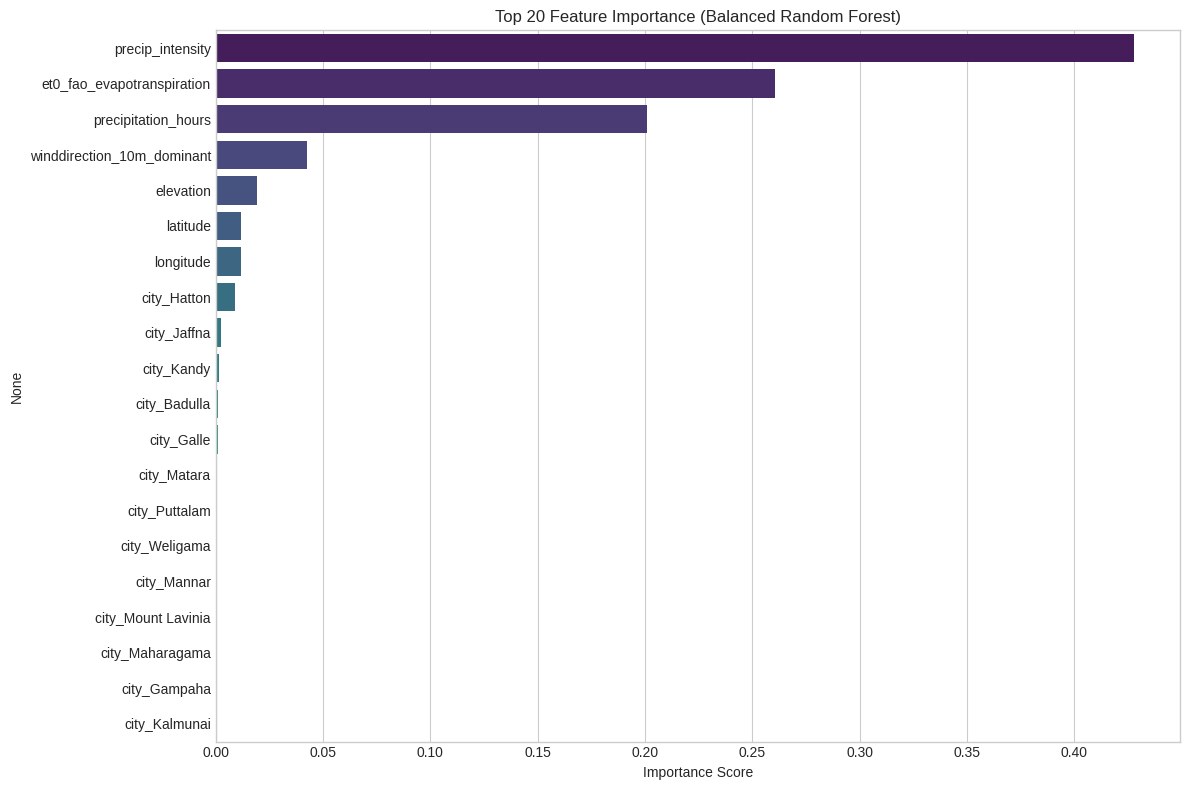

In [ ]:
brf_pipeline = models['Balanced Random Forest']
brf_model = brf_pipeline.named_steps['classifier']
preprocessor = brf_pipeline.named_steps['preprocessor']

try:
    feature_names = preprocessor.get_feature_names_out()
    importances = pd.Series(brf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x=importances.head(20).values, y=importances.head(20).index, palette='viridis')
    plt.title('Top 20 Feature Importance (Balanced Random Forest)')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not plot feature importance: {e}")

In [ ]:
X_train_if = train_df >> select(['et0_fao_evapotranspiration', 'precipitation_hours', 'winddirection_10m_dominant'])
X_test_if = test_df >> select(['et0_fao_evapotranspiration', 'precipitation_hours', 'winddirection_10m_dominant'])
numeric_features = [str(c) for c in X_train_if.select_dtypes(include=['float64', 'int64']).columns.tolist()]

numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
    ],
    verbose_feature_names_out=False
)

# Define Expanded Model Suite
models = {}

models["LogReg"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

models["RandomForest"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

models["GradientBoosting"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

models["XGBoost"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42))
])

models["LogReg (Balanced)"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

models["Elastic Net (Balanced)"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5,
                                      max_iter=1000, class_weight='balanced', random_state=42))
])

# --- Imbalance Strategies (Resampling) ---
models["SMOTE + LogReg"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('resampler', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

models["SMOTEENN + LogReg"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('resampler', SMOTEENN(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

models["RandomUnderSampler + LogReg"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('resampler', RandomUnderSampler(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# --- Ensemble Methods for Imbalance ---
models["Balanced Random Forest"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BalancedRandomForestClassifier(n_estimators=100, random_state=42))
])

models["Easy Ensemble"] = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', EasyEnsembleClassifier(n_estimators=10, random_state=42))
])

# Evaluation
print("--- Cross-Validation Scores (ROC-AUC) ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 6. Test Set Evaluation & Custom Table
print("\n--- Test Set Evaluation ---")
table_data = []

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        # Calculate Confusion Matrix
        # Confusion matrix returns [[TN, FP], [FN, TP]]
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        table_data.append({
            "Model": name,
            "TP (Caught)": tp,
            "FN (Missed)": fn,
            "FP (False Alarms)": fp,
            "TN (Correct 0s)": tn
        })
    except Exception as e:
        print(f"Model {name} failed prediction: {e}")

# Create DataFrame
results_df = pd.DataFrame(table_data)
if not results_df.empty:
    results_df = results_df.set_index("Model")

    # Display formatted table style
    display(results_df.style.background_gradient(cmap='RdYlGn', subset=['TP (Caught)', 'TN (Correct 0s)'])
                            .background_gradient(cmap='RdYlGn_r', subset=['FN (Missed)', 'FP (False Alarms)'])
                            .format("{:,}"))

--- Cross-Validation Scores (ROC-AUC) ---

--- Test Set Evaluation ---


,TP (Caught),FN (Missed),FP (False Alarms),TN (Correct 0s)
Model,,,,
LogReg,102,197,14,"29,183"
RandomForest,185,114,36,"29,161"
GradientBoosting,147,152,37,"29,160"
XGBoost,181,118,49,"29,148"
LogReg (Balanced),261,38,"3,759","25,438"
Elastic Net (Balanced),259,40,"4,457","24,740"
SMOTE + LogReg,261,38,"3,775","25,422"
SMOTEENN + LogReg,261,38,"3,845","25,352"
RandomUnderSampler + LogReg,261,38,"3,862","25,335"


### Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

print("--- Hyperparameter Tuning: Balanced Random Forest ---")

# 1. Define Parameter Grid
param_dist_brf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# 2. Initialize RandomizedSearch
brf_tune = RandomizedSearchCV(
    models['Balanced Random Forest'],
    param_distributions=param_dist_brf,
    n_iter=10,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

# 3. Fit
brf_tune.fit(X_train, y_train)

print(f"Best BRF Score: {brf_tune.best_score_:.4f}")
print(f"Best BRF Params: {brf_tune.best_params_}")

print("\n--- Hyperparameter Tuning: LogReg (Balanced) ---")

param_dist_lr = {
    'classifier__C': np.logspace(-4, 4, 20),
    'classifier__solver': ['liblinear', 'saga']
}

lr_tune = RandomizedSearchCV(
    models['LogReg (Balanced)'],
    param_distributions=param_dist_lr,
    n_iter=10,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

lr_tune.fit(X_train, y_train)

print(f"Best LogReg Score: {lr_tune.best_score_:.4f}")
print(f"Best LogReg Params: {lr_tune.best_params_}")

# Update models dictionary with best estimators
models['Balanced RF (Tuned)'] = brf_tune.best_estimator_
models['LogReg Balanced (Tuned)'] = lr_tune.best_estimator_

In [ ]:
table_data_tuned = []

tuned_model_names = ['Balanced RF (Tuned)', 'LogReg Balanced (Tuned)']

for name in tuned_model_names:
    model = models[name]
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    table_data_tuned.append({
        "Model": name,
        "TP (Caught)": tp,
        "FN (Missed)": fn,
        "FP (False Alarms)": fp,
        "TN (Correct 0s)": tn
    })

results_tuned_df = pd.DataFrame(table_data_tuned).set_index("Model")
display(results_tuned_df.style.background_gradient(cmap='RdYlGn', subset=['TP (Caught)', 'TN (Correct 0s)'])
                            .background_gradient(cmap='RdYlGn_r', subset=['FN (Missed)', 'FP (False Alarms)'])
                            .format("{:,}"))